In [1]:
import ast
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import matplotlib.font_manager as fm
import re
import os

<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


#### Colours

In [3]:
retrofit_colours = ['#3e7ad3', '#518dca', '#5ba0c0', '#5fb4b5', '#f1a800']
baseline_colours = ['#3e7ad3']
control_colours =  ['#005c83', '#1d82ab', '#33a9d4']
fabric_colours = ['#674b00', '#906f00', '#bc9400', '#eabc17'] #['#3DDBD9', '#3DDBD9', '#3DDBD9', '#3DDBD9']
energy_colours = ['#7b0044', '#ff7eb6'] #['#82CFFF', '#82CFFF']
combo_colours =  ['#6746a6', '#a67ee6', '#ecc0ff'] #['#110158', '#6947a8', '#be95ff'] #['#BE95FF', '#BE95FF', '#BE95FF']

INTERMEDIATE_COLOURS = baseline_colours + control_colours + fabric_colours + energy_colours + combo_colours

full_custom_labels = ['Baseline',
                      'Control - One Zone',
                 'Control - Four zones',
                 'Control - All zones',
                 'Fabric - Low cost',
                 'Fabric - Shallow',
                 'Fabric - Deep',
                 'Fabric - Passivhaus',
                 'System\nASHP',
                 'System\nASHP + PV/Batt',
                 'Combo\nPassivhaus + All Control',
                 'Combo\nEnergy System + All Control',
                 'Combo\nBest Fabric & System + All Control']

custom_labels = ['+ One zone controlled',
                '+ Four zones controlled',
                 '+ All zones controlled',
                 'Baseline + Low cost',
                 '+ Shallow',
                 '+ Deep',
                 '+ Passivhaus',
                 'Baseline + ASHP',
                 '+ PV/Batt',
                 'Passivhaus + All Control',
                 'Energy System + All Control',
                 'Best Fabric & System + All Control']

#### Metadata on cases

In [4]:
# Define building_cost_df
building_cost = {
    'case': [
        0,
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8,
        9,
        10,
        11,
        12,
        13,
        14],

    'building_cost': [
        0,
        400,
        6350,
        18450,
        29500,
        7500,
        7500 + 150,
        7500 + 6350,
        7500 + 18450,
        7500 + 29500,
        12500 + 7500,
        12500 + 7500 + 150,
        12500 + 7500 + 6350,
        12500 + 7500 + 18450,
        12500 + 7500 + 29500,
    ]

}
building_cost_df = pd.DataFrame(building_cost)


# Define sensing_cost_df
sensing_cost = {
    'zone': [0, 1, 4, 9],
    'sensing_cost': [0,60, 100, 180],
    'control_names': ["Manual Control","One Zone Controlled", "Partial Control", "Full Control"]
}
sensing_cost_df = pd.DataFrame(sensing_cost)

# Define sensing_cost_df
case_names = {
    'case': [0,
                1,
                2,
                3,
                4,
                5,
                6,
                7,
                8,
                9,
                10,
                11,
                12,
                13,
                14],
    'retrofit_name': ["Baseline",
                        "Fabric - Low cost",
                        "Fabric - Shallow",
                        "Fabric - Deep",
                        "Fabric - Passivhaus",
                        "System - ASHP",
                        "Low cost + ASHP",
                        "Shallow + ASHP",
                        "Deep + ASHP",
                        "Passivhaus + ASHP",
                        "System - ASHP + PV + Batt",
                        "Low cost + ASHP + PV + Batt",
                        "Shallow + ASHP + PV + Batt",
                        "Deep + ASHP + PV + Batt",
                        "Passivhaus + ASHP + PV + Batt",
    ]
}

case_names_df = pd.DataFrame(case_names)

#### Helper functions

In [5]:
def interpolate_zones(df, case, zones_0=0, zones_9=9, zones_new=[1, 4], columns=None):
    if columns is None:
        columns = df.columns.difference(['case', 'zone'])  # Default to all columns except 'case' and 'zone'

    df_zone0 = df[(df["case"] == case) & (df["zone"] == zones_0)].iloc[0]
    df_zone9 = df[(df["case"] == case) & (df["zone"] == zones_9)].iloc[0]

    def interpolate_value(col):
        return np.interp(zones_new, [zones_0, zones_9], [df_zone0[col], df_zone9[col]])

    new_rows = pd.DataFrame({
        "case": [case] * len(zones_new),
        "zone": zones_new
    })

    for col in columns:
        new_rows[col] = interpolate_value(col)

    return new_rows


def annot_func(val):
    if val == 60:
        return ""
    elif val == -1:
        return "X"  # Mark unallowed transitions with an "X"
    elif val == np.inf:
        return r"$\infty$"  # Mark infinite payback with the infinity symbol
    elif pd.isna(val):
        return ""
    elif val < 1:
        return f"{val:.1f}"  # 1 decimal place for values less than 1
    elif 1 <= val <= 100:
        return f"{val:.2g}"  # 2 significant figures for values between 1 and 100
    else:
        return f"{val:.3g}"  # 3 significant figures for values above 100


#### Collect all results.json

In [6]:

def collect_result_jsons(base_dir):
    data = []

    for dirpath, _, files in os.walk(base_dir):
        if 'metrics.json' in files and 'v5' in dirpath:  # Include only directories with "v5"
            matches = re.search(
                r"case_(\d+)_year_\d+_rep_\w+_zone_(\d+)_inactive.*pattern_(\w+)_t.*comfort_(\d+\.?\d*)",
                os.path.basename(dirpath)
            )
            if matches:
                case, zone, pattern, comfort = matches.groups()
                pattern = pattern.rstrip('_t')

                with open(os.path.join(dirpath, 'metrics.json')) as f:
                    metrics = json.load(f)

                data.append({
                    'case': case,
                    'zone': zone,
                    'pattern': pattern,
                    'comforttemp': float(comfort),
                    **metrics
                })

    df = pd.DataFrame(data)
    df = df.sort_values(by=["case", "zone", "pattern", "comforttemp"])
    df["case"] = pd.to_numeric(df["case"])
    df["zone"] = pd.to_numeric(df["zone"])

    df.columns = df.columns.str.replace(r'^eval/', '', regex=True)
    return df

base_dir = "/workspaces/CUBES/results"
results_df = collect_result_jsons(base_dir)

temp_data = pd.read_csv("temperature_averages.csv",index_col=0)

# Merge temp_data and results_df on the specified columns
combined_df = pd.merge(temp_data, results_df, on=['case', 'zone', 'pattern', 'comforttemp'], how='inner')



In [7]:
# Filter the data for zone == 0
zone_0_df = combined_df[combined_df['zone'] == 0]

# Extract the reference temperatures for case 0
case_0_df = zone_0_df[zone_0_df['case'] == 0][['pattern', 'comforttemp', 'air_awake_mean_temp', 'mean_episode_emissions', 'mean_episode_cost']]

# Create a dictionary to store the closest comfort temperatures
closest_comfort_temps = []

# Iterate through all unique cases other than case 0
for case in zone_0_df['case'].unique():
    # if case == 0:
    #     continue  # Skip case 0 as it is the reference

    # Filter data for the current case
    case_df = zone_0_df[zone_0_df['case'] == case]

    # Iterate through each heating pattern
    for pattern in case_0_df['pattern'].unique():
        # Filter reference data for the current pattern
        pattern_ref_df = case_0_df[case_0_df['pattern'] == pattern]

        # Iterate through all comfort temperatures for the reference
        for ref_comforttemp in pattern_ref_df['comforttemp'].unique():
            # Get the reference air_awake_mean_temp and emissions for this comfort temperature
            ref_temp = pattern_ref_df[pattern_ref_df['comforttemp'] == ref_comforttemp]['air_awake_mean_temp'].values[0]
            ref_emissions = pattern_ref_df[pattern_ref_df['comforttemp'] == ref_comforttemp]['mean_episode_emissions'].values[0]
            ref_cost = pattern_ref_df[pattern_ref_df['comforttemp'] == ref_comforttemp]['mean_episode_cost'].values[0]

            # Filter for the current case and pattern, and create a copy to avoid warnings
            case_pattern_df = case_df[case_df['pattern'] == pattern].copy()

            # Calculate the absolute difference between air_awake_mean_temp and the reference temperature
            case_pattern_df['temp_diff'] = abs(case_pattern_df['air_awake_mean_temp'] - ref_temp)

            # Find the row with the minimum difference
            closest_row = case_pattern_df.loc[case_pattern_df['temp_diff'].idxmin()]

            # Calculate emissions reduction
            target_emissions = closest_row['mean_episode_emissions']
            target_cost = closest_row['mean_episode_cost']
            emissions_reduction = -((ref_emissions - target_emissions) / ref_emissions) * 100
            cost_reduction = -((ref_cost - target_cost) / ref_cost) * 100

            # Store the result with explicit reference pattern and emissions reduction
            closest_comfort_temps.append({
                'case': case,
                'pattern': pattern,
                'ref_pattern': pattern,  # Explicitly include the reference pattern
                'closest_comforttemp': closest_row['comforttemp'],
                'ref_air_awake_mean_temp': ref_temp,
                'air_awake_mean_temp': closest_row['air_awake_mean_temp'],
                'ref_comforttemp': ref_comforttemp,
                'ref_emissions': ref_emissions,
                'target_emissions': target_emissions,
                'target_cost': target_cost,
                'emissions_reduction_%': emissions_reduction,
                'cost_reduction_%': cost_reduction
            })

# Convert the results into a DataFrame
closest_comfort_temps_df = pd.DataFrame(closest_comfort_temps)

# Group by 'case' and calculate mean and standard deviation for relevant columns
summary_stats_0 = closest_comfort_temps_df.groupby('case').agg(
    mean_emissions=('target_emissions', 'mean'),
    std_emissions=('target_emissions', 'std'),
    mean_cost=('target_cost', 'mean'),
    std_cost=('target_cost', 'std'),
    relative_emissions=('emissions_reduction_%', 'mean'),
    relative_emissions_std=('emissions_reduction_%', 'std'),
    relative_cost=('cost_reduction_%', 'mean'),
    relative_cost_std=('cost_reduction_%', 'std')
).reset_index()

summary_stats_0['zone'] = 0



In [8]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # Filter the data for the "twice" pattern
# pattern_twice_df = closest_comfort_temps_df[closest_comfort_temps_df['pattern'] == 'twice']

# # Define the order of cases for the rows
# case_order = [
#     4, 9, 14,
#     3, 8, 13,
#     2, 7, 12,
#     1, 6, 11,
#     0, 5, 10
# ]

# # Prepare the subplot grid
# fig, axes = plt.subplots(5, 3, figsize=(15, 20), sharex=True, sharey=True)
# axes = axes.flatten()

# # Iterate through cases in the specified order
# for idx, case in enumerate(case_order):
#     ax = axes[idx]

#     # Subset the data for the current case
#     subset = pattern_twice_df[pattern_twice_df['case'] == case]

#     # Prepare a grid for the heatmap
#     heatmap_grid = np.full((5, 5), np.nan)  # 5x5 grid for temperatures 18-22
#     for _, row in subset.iterrows():
#         x = int(row['ref_comforttemp'] - 18)  # Map ref_comforttemp to 0-4
#         y = int(row['closest_comforttemp'] - 18)  # Map closest_comforttemp to 0-4
#         heatmap_grid[y, x] = row['closest_comforttemp']

#     # Reverse the y-axis to make it ascend
#     sns.heatmap(
#         heatmap_grid[::-1],  # Flip the heatmap data vertically
#         annot=True, fmt=".1f", cbar=False, cmap="coolwarm",  # Uniform colour
#         xticklabels=np.arange(18, 23),
#         yticklabels=np.arange(18, 23),  # Keep ascending order for yticklabels
#         ax=ax
#     )

#     # Add labels
#     if idx % 3 == 0:  # First column
#         ax.set_ylabel(f"Case {case}\nClosest Comfort Temp", fontsize=10)
#     else:
#         ax.set_ylabel("Closest Comfort Temp", fontsize=10)

#     ax.set_xlabel("Ref Comfort Temp", fontsize=10)

# # Hide unused subplots (if any)
# for ax in axes[len(case_order):]:
#     ax.axis('off')

# # Adjust layout
# plt.tight_layout()
# plt.show()


In [9]:
# Filter the data for zone 9 where pattern is restricted to "once"
zone_9_once_df = combined_df[(combined_df['zone'] == 9) & (combined_df['pattern'] == 'once')]

# Extract all patterns and comforttemps from case 0 for reference
case_0_df = combined_df[(combined_df['case'] == 0) & (combined_df['zone'] == 0)][
    ['pattern', 'comforttemp', 'air_awake_mean_temp', 'mean_episode_emissions', 'mean_episode_cost']
]

# Create a list to store results
results = []

# Iterate over each reference configuration in case 0
for _, ref_row in case_0_df.iterrows():
    ref_pattern = ref_row['pattern']
    ref_comforttemp = ref_row['comforttemp']
    ref_air_awake_mean_temp = ref_row['air_awake_mean_temp']
    ref_emissions = ref_row['mean_episode_emissions']
    ref_cost = ref_row['mean_episode_cost']

    # Iterate over all cases other than case 0
    for case in zone_9_once_df['case'].unique():
        # if case == 0:
        #     continue  # Skip case 0

        # Filter data for the current case
        case_df = zone_9_once_df[zone_9_once_df['case'] == case].copy()

        # Calculate the absolute difference in air_awake_mean_temp
        case_df['temp_diff'] = abs(case_df['air_awake_mean_temp'] - ref_air_awake_mean_temp)

        # Find the configuration with the minimum difference
        closest_row = case_df.loc[case_df['temp_diff'].idxmin()]

        # Extract emissions and cost for the closest match
        target_comforttemp = closest_row['comforttemp']
        target_emissions = closest_row['mean_episode_emissions']
        target_cost = closest_row['mean_episode_cost']

        # Calculate emissions and cost reductions
        emissions_reduction = -((ref_emissions - target_emissions) / ref_emissions) * 100
        cost_reduction = -((ref_cost - target_cost) / ref_cost) * 100

        # Append results
        results.append({
            'case': case,
            'ref_pattern': ref_pattern,
            'ref_comforttemp': ref_comforttemp,
            'target_pattern': 'once',  # Pattern in zone 9 is always 'once'
            'closest_comforttemp': target_comforttemp,
            'ref_air_awake_mean_temp': ref_air_awake_mean_temp,
            'air_awake_mean_temp': closest_row['air_awake_mean_temp'],
            'ref_emissions': ref_emissions,
            'target_emissions': target_emissions,
            'emissions_reduction_%': emissions_reduction,
            'ref_cost': ref_cost,
            'target_cost': target_cost,
            'cost_reduction_%': cost_reduction
        })

# Convert the results into a DataFrame
closest_comfort_temps_df_zone_9 = pd.DataFrame(results)

# Group by 'case' and calculate mean and standard deviation for relevant columns
summary_stats_9 = closest_comfort_temps_df_zone_9.groupby('case').agg(
    mean_emissions=('target_emissions', 'mean'),
    std_emissions=('target_emissions', 'std'),
    mean_cost=('target_cost', 'mean'),
    std_cost=('target_cost', 'std'),
    relative_emissions=('emissions_reduction_%', 'mean'),
    relative_emissions_std=('emissions_reduction_%', 'std'),
    relative_cost=('cost_reduction_%', 'mean'),
    relative_cost_std=('cost_reduction_%', 'std')
).reset_index()

summary_stats_9['zone'] = 9





In [10]:
closest_comfort_temps_df_zone_9

,case,ref_pattern,ref_comforttemp,target_pattern,closest_comforttemp,ref_air_awake_mean_temp,air_awake_mean_temp,ref_emissions,target_emissions,emissions_reduction_%,ref_cost,target_cost,cost_reduction_%
0,0,once,18.0,once,18.0,18.044129,17.905783,1712.866226,1603.101635,-6.408241,52228.213388,48966.191313,-6.245709
1,10,once,18.0,once,18.0,18.044129,17.924666,1712.866226,471.032380,-72.500341,52228.213388,53123.238035,1.713680
2,11,once,18.0,once,18.0,18.044129,17.923216,1712.866226,435.819862,-74.556106,52228.213388,47001.855236,-10.006772
3,12,once,18.0,once,18.0,18.044129,17.933157,1712.866226,398.853471,-76.714266,52228.213388,40845.884466,-21.793449
4,13,once,18.0,once,18.0,18.044129,17.929432,1712.866226,51.256458,-97.007562,52228.213388,-18001.644799,-134.467280
...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,5,twice,22.0,once,21.0,20.495783,20.612107,2189.122092,770.581431,-64.799522,65925.750128,124049.495857,88.165467
221,6,twice,22.0,once,21.0,20.495783,20.600028,2189.122092,727.658570,-66.760256,65925.750128,116647.188713,76.937219
222,7,twice,22.0,once,21.0,20.495783,20.615998,2189.122092,684.670758,-68.723957,65925.750128,109684.327095,66.375547
223,8,twice,22.0,once,21.0,20.495783,20.654563,2189.122092,196.085091,-91.042752,65925.750128,31144.665147,-52.757966


In [11]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # Filter the data for the "twice" pattern
# pattern_twice_df = closest_comfort_temps_df[closest_comfort_temps_df['ref_pattern'] == 'twice']

# # Define the order of cases for the rows
# case_order = [
#     4, 9, 14,
#     3, 8, 13,
#     2, 7, 12,
#     1, 6, 11,
#     0, 5, 10
# ]

# # Define a custom colormap
# custom_cmap = sns.color_palette(['lightblue', 'lightblue', 'lightblue', 'lightblue', 'lightblue'])

# # Prepare the subplot grid
# fig, axes = plt.subplots(5, 3, figsize=(15, 20), sharex=True, sharey=True)
# axes = axes.flatten()

# # Iterate through cases in the specified order
# for idx, case in enumerate(case_order):
#     ax = axes[idx]

#     # Subset the data for the current case
#     subset = pattern_twice_df[pattern_twice_df['case'] == case]

#     # Prepare a grid for the heatmap
#     heatmap_grid = np.full((5, 5), np.nan)  # 5x5 grid for temperatures 18-22
#     for _, row in subset.iterrows():
#         x = int(row['ref_comforttemp'] - 18)  # Map ref_comforttemp to 0-4
#         y = int(row['closest_comforttemp'] - 18)  # Map closest_comforttemp to 0-4
#         heatmap_grid[y, x] = row['closest_comforttemp']

#     # Plot the heatmap
#     sns.heatmap(
#         heatmap_grid[::-1],  # Flip the heatmap data vertically
#         annot=True, fmt=".1f", cbar=False, cmap="coolwarm",  # Uniform colour
#         xticklabels=np.arange(18, 23),
#         yticklabels=np.arange(22, 17, step=-1),  # Keep ascending order for yticklabels
#         mask=None,  # Show all cells
#         ax=ax
#     )

#     # Add gridlines
#     for i in range(6):  # There are 5 cells, so we need 6 lines to define borders
#         ax.hlines(i, 0, 5, colors='black', linewidth=0.5)  # Horizontal lines
#         ax.vlines(i, 0, 5, colors='black', linewidth=0.5)  # Vertical lines

#     # Add labels
#     if idx % 3 == 0:  # First column
#         ax.set_ylabel(f"Case {case}\nClosest Comfort Temp", fontsize=10)

#     # Add a label for the first row
#     if idx < 3:  # Top row
#         col_label = ["Left", "Middle", "Right"][idx % 3]  # Example column labels
#         ax.set_title(f"{col_label} Column\n", fontsize=12, weight='bold')

#     if idx > 11:  # Top row
#         ax.set_xlabel("Original Thermostat Temperature", fontsize=10)

# # Hide unused subplots (if any)
# for ax in axes[len(case_order):]:
#     ax.axis('off')

# # Adjust layout
# plt.tight_layout()
# plt.show()


In [12]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # Filter the data for the "twice" pattern
# pattern_twice_df = closest_comfort_temps_df_zone_9[closest_comfort_temps_df_zone_9['ref_pattern'] == 'twice']

# # Define the order of cases for the rows
# case_order = [
#     4, 9, 14,
#     3, 8, 13,
#     2, 7, 12,
#     1, 6, 11,
#     0, 5, 10
# ]

# # Define a custom colormap
# custom_cmap = sns.color_palette(['lightblue', 'lightblue', 'lightblue', 'lightblue', 'lightblue'])

# # Prepare the subplot grid
# fig, axes = plt.subplots(5, 3, figsize=(15, 20), sharex=True, sharey=True)
# axes = axes.flatten()

# # Iterate through cases in the specified order
# for idx, case in enumerate(case_order):
#     ax = axes[idx]

#     # Subset the data for the current case
#     subset = pattern_twice_df[pattern_twice_df['case'] == case]

#     # Prepare a grid for the heatmap
#     heatmap_grid = np.full((5, 5), np.nan)  # 5x5 grid for temperatures 18-22
#     for _, row in subset.iterrows():
#         x = int(row['ref_comforttemp'] - 18)  # Map ref_comforttemp to 0-4
#         y = int(row['closest_comforttemp'] - 18)  # Map closest_comforttemp to 0-4
#         heatmap_grid[y, x] = row['closest_comforttemp']

#     # Plot the heatmap
#     sns.heatmap(
#         heatmap_grid[::-1],  # Flip the heatmap data vertically
#         annot=True, fmt=".1f", cbar=False, cmap="coolwarm",  # Uniform colour
#         xticklabels=np.arange(18, 23),
#         yticklabels=np.arange(22, 17, step=-1),  # Keep ascending order for yticklabels
#         mask=None,  # Show all cells
#         ax=ax
#     )

#     # Add gridlines
#     for i in range(6):  # There are 5 cells, so we need 6 lines to define borders
#         ax.hlines(i, 0, 5, colors='black', linewidth=0.5)  # Horizontal lines
#         ax.vlines(i, 0, 5, colors='black', linewidth=0.5)  # Vertical lines

#     # Add labels
#     if idx % 3 == 0:  # First column
#         ax.set_ylabel(f"Case {case}\nClosest Comfort Temp", fontsize=10)

#     # Add a label for the first row
#     if idx < 3:  # Top row
#         col_label = ["Left", "Middle", "Right"][idx % 3]  # Example column labels
#         ax.set_title(f"{col_label} Column\n", fontsize=12, weight='bold')

#     if idx > 11:  # Top row
#         ax.set_xlabel("Original Thermostat Temperature", fontsize=10)

# # Hide unused subplots (if any)
# for ax in axes[len(case_order):]:
#     ax.axis('off')

# # Adjust layout
# plt.tight_layout()
# plt.show()


In [13]:
summary_stats = pd.concat([summary_stats_0, summary_stats_9])

In [14]:
summary_stats = summary_stats.sort_values(by=['case', 'zone'])

In [15]:
summary_stats

,case,mean_emissions,std_emissions,mean_cost,std_cost,relative_emissions,relative_emissions_std,relative_cost,relative_cost_std,zone
0,0,1946.900501,254.060872,58973.956647,7416.526258,0.000000,0.000000,0.000000,0.000000,0
0,0,1785.062223,174.700317,54224.383517,5044.705752,-7.915658,3.916107,-7.672966,3.841621,9
1,1,1792.229232,237.520364,54373.836226,6939.825510,-7.968535,0.293930,-7.821585,0.273058,0
1,1,1649.806976,180.709636,50185.245030,5218.939637,-14.989518,3.407318,-14.638635,3.320222,9
2,2,1673.199496,224.708056,50797.651379,6570.402268,-14.100116,0.558117,-13.902244,0.532340,0
2,2,1530.045419,158.600429,46592.172458,4586.907123,-21.124523,3.036931,-20.716612,2.995480,9
3,3,423.120652,71.570566,12948.254289,2147.435761,-78.357803,1.206102,-78.135988,1.227115,0
3,3,388.872289,66.823682,11906.068272,1991.403003,-80.113476,1.009289,-79.897190,1.014221,9
4,4,230.902420,46.783316,7136.425330,1413.377926,-88.235128,0.943771,-87.992856,0.957679,0
4,4,215.262046,45.057538,6659.239345,1348.638164,-89.040087,0.924757,-88.800977,0.921532,9


In [16]:


merged_df = pd.merge(combined_df, building_cost_df, on='case', how='left')
merged_df = pd.merge(merged_df, sensing_cost_df, on='zone', how='left')
merged_df = pd.merge(merged_df, case_names_df, on='case', how='left')

merged_df["installation_cost"] = merged_df["building_cost"] + merged_df["sensing_cost"]


merged_df["mean_episode_emissions"] = merged_df["mean_episode_emissions"] / 1000
merged_df["mean_episode_cost"] = merged_df["mean_episode_cost"] / 100


merged_df["bill_saving"] = -1 * (merged_df["mean_episode_cost"] - merged_df["mean_episode_cost"].iloc[0])

merged_df["payback"] = merged_df["installation_cost"] / merged_df["bill_saving"]

In [17]:
def produce_emission_cost_contour(dataframe, temp_type):
    if temp_type =="opr":
        temp_label = "Operative"
    else:
        temp_label = "Air"
    dataframe = dataframe[
        [
            "case",
            "zone",
            "pattern",
            "comforttemp",
            "mean_episode_cost",
            "mean_episode_emissions",
            "building_cost",
            "sensing_cost",
            "air_awake_median_temp",
            "opr_awake_median_temp"
        ]
    ]

    fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(28, 44), sharex=False, sharey=True)

    heating_patterns = sorted(dataframe["pattern"].unique(), reverse=True)
    cases = [0, 1, 2, 3, 4]
    setback_temp = 16

    global_min_comfort, global_max_comfort = -50, 20
    levels_emissions = np.arange(-100, 110, 10)

    custom_levels_comfort = [-30, -20, -15, -10, -5, -1, 1, 5, 10, 15, 20, 30]
    custom_levels_comfort = [-4, -3.5, -3,-2.5, -2, -1.5, -1, -0.5, -0.1, 0.1, 0.5, 1, 1.5, 2, 2.5, 3]
    custom_colours = ['#A50026', '#DD3D2D', '#F67E4B', '#FDB366', '#FEDA8B', '#FFFFFF', '#C2E4EF', '#98CAE1', '#6EA6CD', '#4A7BB7', '#364B9A']
    custom_colours = ['#4A7BB7', '#6EA6CD','#98CAE1', '#C2E4EF',  '#FFFFFF',  '#FEDA8B', '#FDB366','#F67E4B', '#DD3D2D']
    custom_colours = [
        '#4a7bb7', '#588abf', '#6799c7', '#77a8cf', '#87b8d7', '#99c7df', '#add5e7', '#c2e4ef',
        '#FFFFFF',
        '#feda8b', '#fec578', '#fcb068', '#f99a5a', '#f4844e', '#ee6e42', '#e65737', '#dd3d2d', '#A50026',
        ]
    case_names = {0: "<1919", 1: "1950s", 2: "1990s", 3: "2010s", 4: "Passivhaus"}

    contourf_plots = []

    for row, case in enumerate(cases):
        for col, heating_pattern in enumerate(heating_patterns):
            ax = axes[row, col]

            df_0 = dataframe[
                (dataframe["case"] == case) &
                (dataframe["zone"] == 0) &
                (dataframe["pattern"] == heating_pattern)
            ]

            df_9 = dataframe[
                (dataframe["case"] == case) &
                (dataframe["zone"] == 9) &
                (dataframe["pattern"] == heating_pattern)
            ]

            emissions_data = {}
            cost_data = {}
            comfort_data = {}

            for i, entry_0 in df_0.iterrows():
                for j, entry_9 in df_9.iterrows():
                    emissions_reduction = ((entry_0['mean_episode_emissions'] - entry_9['mean_episode_emissions']) / entry_0['mean_episode_emissions']) * -100
                    emissions_data[(entry_0['comforttemp'], entry_9['comforttemp'])] = emissions_reduction

                    cost_reduction = ((entry_0['mean_episode_cost'] - entry_9['mean_episode_cost']) / entry_0['mean_episode_cost']) * -100
                    cost_data[(entry_0['comforttemp'], entry_9['comforttemp'])] = cost_reduction

                    # Use median awake temperature instead of bin summation
                    comfort_level_0 = entry_0[f'{temp_type}_awake_median_temp']
                    comfort_level_9 = entry_9[f'{temp_type}_awake_median_temp']
                    comfort_change = comfort_level_9 - comfort_level_0
                    comfort_data[(entry_0['comforttemp'], entry_9['comforttemp'])] = comfort_change

            # Create DataFrames for contour plotting
            emissions_contour_df = pd.DataFrame.from_dict(emissions_data, orient='index', columns=['emissions_reduction']).reset_index()
            emissions_contour_df[['comforttemp_zone0', 'comforttemp_zone9']] = pd.DataFrame(emissions_contour_df['index'].tolist(), index=emissions_contour_df.index)
            emissions_contour_df = emissions_contour_df.drop(columns=['index'])

            cost_contour_df = pd.DataFrame.from_dict(cost_data, orient='index', columns=['cost_reduction']).reset_index()
            cost_contour_df[['comforttemp_zone0', 'comforttemp_zone9']] = pd.DataFrame(cost_contour_df['index'].tolist(), index=cost_contour_df.index)
            cost_contour_df = cost_contour_df.drop(columns=['index'])

            comfort_contour_df = pd.DataFrame.from_dict(comfort_data, orient='index', columns=['comfort_change']).reset_index()
            comfort_contour_df[['comforttemp_zone0', 'comforttemp_zone9']] = pd.DataFrame(comfort_contour_df['index'].tolist(), index=comfort_contour_df.index)
            comfort_contour_df = comfort_contour_df.drop(columns=['index'])

            # # Find the interpolated comforttemp for comfort_change = 0
            # interp_comforttemp = find_control_temp_for_manual_20_and_comfort_band(comfort_contour_df)

            # Pivot the data for contour plots
            emissions_plot_data = emissions_contour_df.pivot_table(index="comforttemp_zone9", columns="comforttemp_zone0", values="emissions_reduction")
            cost_plot_data = cost_contour_df.pivot_table(index="comforttemp_zone9", columns="comforttemp_zone0", values="cost_reduction")
            comfort_plot_data = comfort_contour_df.pivot_table(index="comforttemp_zone9", columns="comforttemp_zone0", values="comfort_change")

            X, Y = np.meshgrid(emissions_plot_data.columns, emissions_plot_data.index)
            Z = emissions_plot_data.values
            Z_comfort = comfort_plot_data.values

            X_cost, Y_cost = np.meshgrid(cost_plot_data.columns, cost_plot_data.index)
            Z_cost = cost_plot_data.values

            contourf_plot = ax.contourf(X, Y, Z_comfort, extend='both', levels=custom_levels_comfort, colors=custom_colours)
            contourf_plots.append(contourf_plot)
            contours_cost = ax.contour(X_cost, Y_cost, Z_cost, colors='white', linewidths=0.5, levels=levels_emissions)

            # Existing emissions contour plot
            contours = ax.contour(X, Y, Z, colors='black', linewidths=0.5, levels=levels_emissions)

            cost_labels = ax.clabel(contours_cost, inline=True, fontsize=16, fmt="%.0f%%", zorder=10)

            # Add bold contour for 0% emissions level after clabels
            contours_bold = ax.contour(X, Y, Z, colors='black', linewidths=4.5, levels=[0], linestyles=':')
            emission_labels = ax.clabel(contours, inline=True, fontsize=16, fmt="%.0f%%", zorder=10)
            emission_labels = ax.clabel(contours_bold, inline=True, fontsize=16, fmt="%.0f%%", zorder=1)

            for label in cost_labels:
                label.set_fontweight('bold')

            # if interp_comforttemp is not None:
            #     ax.plot(20, interp_comforttemp, 'o', markersize=8, markerfacecolor='none', markeredgecolor='black', markeredgewidth=2)

            #     # Interpolate the cost reduction at this comforttemp
            #     df_filtered_cost = cost_contour_df[cost_contour_df['comforttemp_zone0'] == 20].sort_values(by='comforttemp_zone9')

            #     if not df_filtered_cost.empty:
            #         below = df_filtered_cost[df_filtered_cost['comforttemp_zone9'] <= interp_comforttemp].iloc[-1]
            #         above = df_filtered_cost[df_filtered_cost['comforttemp_zone9'] >= interp_comforttemp].iloc[0]

            #         # Linear interpolation
            #         cost_reduction_at_point = below['cost_reduction'] + (interp_comforttemp - below['comforttemp_zone9']) * (above['cost_reduction'] - below['cost_reduction']) / (above['comforttemp_zone9'] - below['comforttemp_zone9'])

            #         ax.annotate(f'{cost_reduction_at_point:.0f}%', xy=(20, interp_comforttemp), xytext=(10, 10),
            #                     textcoords='offset points', color='black', fontsize=16, weight='bold')
            # else:
            #     print("No valid interpolation found for comfort_change = 0.")

            for tick in np.arange(X.min(), X.max() + 1, 1):
                ax.axvline(tick, color='grey', linestyle='--', linewidth=0.5)
            for tick in np.arange(Y.min(), Y.max() + 1, 1):
                ax.axhline(tick, color='grey', linestyle='--', linewidth=0.5)

            if row == 0:
                if col == 0:
                    ax.set_title("Heating Hours\n  6-8 + 12-14 + 18-23", fontsize=24)
                elif col == 1:
                    ax.set_title("Heating Hours\n  6-9 + 16-23", fontsize=24)
                elif col == 2:
                    ax.set_title("Heating Hours\n 6-23", fontsize=24)

            if col == 0:
                ax.set_ylabel(f"Case: {case_names[case]}", fontsize=24)

            ax.tick_params(axis='both', which='major', labelsize=20)
            ax.set_xticks(np.arange(X.min(), X.max() + 1, 1))
            ax.set_yticks(np.arange(Y.min(), Y.max() + 1, 1))


    cbar = fig.colorbar(contourf_plot, ax=axes, orientation='vertical',
                     ticks=custom_levels_comfort, fraction=0.04, pad=0.04)

    # Invert the colour bar
    # cbar.ax.invert_yaxis()
    # Change the fontsize of the colour bar ticks
    cbar.ax.tick_params(labelsize=16)

    cbar.set_label(f"Change in Median Temperature ({temp_label}) Experienced During Awake Hours", fontsize=20)

    fig.text(0.05, 0.5, 'Occupancy-Control Thermostat Temperature', va='center', rotation='vertical', fontsize=24)
    fig.text(0.5, 0.09, 'Manually Set Thermostat Temperature', ha='center', rotation='horizontal', fontsize=24)

    plt.show()


In [18]:
def produce_emission_cost_contour(dataframe, temp_type, average):
    if temp_type == "opr":
        temp_label = "Operative"
    else:
        temp_label = "Air"

    dataframe = dataframe[
        [
            "case",
            "zone",
            "pattern",
            "comforttemp",
            "mean_episode_cost",
            "mean_episode_emissions",
            "building_cost",
            "sensing_cost",
            f"air_awake_{average}_temp",
            f"opr_awake_{average}_temp"
        ]
    ]

    fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(28, 44), sharex=False, sharey=True)

    heating_patterns = sorted(dataframe["pattern"].unique(), reverse=True)
    cases = [0, 1, 2, 3, 4]

    levels_emissions = np.arange(-100, 110, 10)


    custom_levels_comfort = [-4, -3.5, -3, -2.5, -2, -1.5, -1, -0.5, -0.1, 0.1, 0.5, 1, 1.5, 2, 2.5, 3]
    custom_colours = [
        '#4a7bb7', '#588abf', '#6799c7', '#77a8cf', '#87b8d7', '#99c7df', '#add5e7', '#c2e4ef',
        '#ffffff',
        '#feda8b', '#fec578', '#fcb068', '#f99a5a', '#f4844e', '#ee6e42', '#e65737', '#dd3d2d', '#A50026',
    ]

    # custom_levels_comfort = [-4, -3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0.5, 1, 1.5, 2, 2.5, 3]
    # custom_colours = [
    #     '#4a7bb7', '#588abf', '#6799c7', '#77a8cf', '#87b8d7', '#99c7df', '#add5e7',
    #     '#F7F7F7',
    #     '#fec578', '#fcb068', '#f99a5a', '#f4844e', '#ee6e42', '#e65737', '#dd3d2d', '#A50026',
    # ]

    # custom_levels_comfort = [-4, -3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0.0, 0.5, 1, 1.5, 2, 2.5, 3]

    # custom_colours = [
    #     '#4a7bb7', '#588abf', '#6799c7', '#77a8cf', '#87b8d7', '#99c7df', '#add5e7', '#c2e4ef',
    #      '#fec578', '#fcb068', '#f99a5a', '#f4844e', '#ee6e42', '#e65737', '#dd3d2d'
    # ]


    # custom_levels_comfort = [-4, -3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0.1, 0.5, 1, 1.5, 2, 2.5, 3]
    # custom_colours = [
    #     '#588abf', '#6799c7', '#77a8cf', '#87b8d7', '#99c7df', '#add5e7', '#c2e4ef',
    #     '#ffffff',
    #     '#feda8b', '#fec578', '#fcb068', '#f99a5a', '#f4844e', '#ee6e42', '#e65737', '#dd3d2d', '#A50026',
    # ]

    case_names = {0: "Baseline", 1: "Shallow", 2: "Low-Cost", 3: "Deep", 4: "Passivhaus"}

    contourf_plots = []

    for row, case in enumerate(cases):
        for col, heating_pattern in enumerate(heating_patterns):
            ax = axes[row, col]
            ax.grid(False)


            df_0 = dataframe[
                (dataframe["case"] == case) &
                (dataframe["zone"] == 0) &
                (dataframe["pattern"] == heating_pattern)
            ]

            df_9 = dataframe[
                (dataframe["case"] == case) &
                (dataframe["zone"] == 9) &
                (dataframe["pattern"] == 'once')
            ]

            # Calculate median temperature for each comfort temperature in zone0
            comfort_temps = sorted(df_0["comforttemp"].unique())

            if average == 'mean':
                median_temps_zone0 = [df_0[df_0["comforttemp"] == temp][f"{temp_type}_awake_{average}_temp"].mean() for temp in comfort_temps]
            else:
                median_temps_zone0 = [df_0[df_0["comforttemp"] == temp][f"{temp_type}_awake_{average}_temp"].median() for temp in comfort_temps]

            # Set the main x-axis ticks for comfort temperatures
            ax.set_xticks(comfort_temps)
            ax.set_xticklabels(comfort_temps, fontsize=16)

            emissions_data = {}
            cost_data = {}
            comfort_data = {}

            for i, entry_0 in df_0.iterrows():
                for j, entry_9 in df_9.iterrows():
                    emissions_reduction = ((entry_0['mean_episode_emissions'] - entry_9['mean_episode_emissions']) / entry_0['mean_episode_emissions']) * -100
                    emissions_data[(entry_0['comforttemp'], entry_9['comforttemp'])] = emissions_reduction

                    cost_reduction = ((entry_0['mean_episode_cost'] - entry_9['mean_episode_cost']) / entry_0['mean_episode_cost']) * -100
                    cost_data[(entry_0['comforttemp'], entry_9['comforttemp'])] = cost_reduction

                    comfort_level_0 = entry_0[f'{temp_type}_awake_{average}_temp']
                    comfort_level_9 = entry_9[f'{temp_type}_awake_{average}_temp']
                    comfort_change = comfort_level_9 - comfort_level_0
                    comfort_data[(entry_0['comforttemp'], entry_9['comforttemp'])] = comfort_change

            # Create DataFrames for contour plotting
            emissions_contour_df = pd.DataFrame.from_dict(emissions_data, orient='index', columns=['emissions_reduction']).reset_index()
            emissions_contour_df[['comforttemp_zone0', 'comforttemp_zone9']] = pd.DataFrame(emissions_contour_df['index'].tolist(), index=emissions_contour_df.index)
            emissions_contour_df = emissions_contour_df.drop(columns=['index'])

            cost_contour_df = pd.DataFrame.from_dict(cost_data, orient='index', columns=['cost_reduction']).reset_index()
            cost_contour_df[['comforttemp_zone0', 'comforttemp_zone9']] = pd.DataFrame(cost_contour_df['index'].tolist(), index=cost_contour_df.index)
            cost_contour_df = cost_contour_df.drop(columns=['index'])

            comfort_contour_df = pd.DataFrame.from_dict(comfort_data, orient='index', columns=['comfort_change']).reset_index()
            comfort_contour_df[['comforttemp_zone0', 'comforttemp_zone9']] = pd.DataFrame(comfort_contour_df['index'].tolist(), index=comfort_contour_df.index)
            comfort_contour_df = comfort_contour_df.drop(columns=['index'])

            # Pivot the data for contour plots
            emissions_plot_data = emissions_contour_df.pivot_table(index="comforttemp_zone9", columns="comforttemp_zone0", values="emissions_reduction")
            cost_plot_data = cost_contour_df.pivot_table(index="comforttemp_zone9", columns="comforttemp_zone0", values="cost_reduction")
            comfort_plot_data = comfort_contour_df.pivot_table(index="comforttemp_zone9", columns="comforttemp_zone0", values="comfort_change")

            X, Y = np.meshgrid(emissions_plot_data.columns, emissions_plot_data.index)
            Z = emissions_plot_data.values
            Z_comfort = comfort_plot_data.values

            X_cost, Y_cost = np.meshgrid(cost_plot_data.columns, cost_plot_data.index)
            Z_cost = cost_plot_data.values

            contourf_plot = ax.contourf(X, Y, Z_comfort, extend='both', levels=custom_levels_comfort, colors=custom_colours)
            contourf_plots.append(contourf_plot)
            # contours_cost = ax.contour(X_cost, Y_cost, Z_cost, colors='#474747', linewidths=0.5, levels=levels_emissions)

            # # Add translucent grey overlay
            # ax.contourf(X, Y, Z_comfort, levels=[-0.53, 0.13], colors='#ffffff', alpha=0.4, zorder=2)

            # # Add contour lines to highlight edges
            # ax.contour(X, Y, Z_comfort, levels=[-0.53, 0.13], colors='#ffffff', linewidths=2, linestyles='-', zorder=3)


            # Emissions contour plot
            contours = ax.contour(X, Y, Z, colors='black', linewidths=0.5, levels=levels_emissions)

            # cost_labels = ax.clabel(contours_cost, inline=True, fontsize=16, fmt="%.0f%%", zorder=10)

            # Bold contour for 0% emissions level
            contours_bold = ax.contour(X, Y, Z, colors='black', linewidths=4.5, levels=[0], linestyles=':')
            emission_labels = ax.clabel(contours, inline=True, fontsize=16, fmt="%.0f%%", zorder=10)

            emission_labels = ax.clabel(contours_bold, inline=True, fontsize=16, fmt="%.0f%%", zorder=1)



            # # Add a single contour for zero comfort change
            # zero_comfort_contour = ax.contour(X, Y, Z_comfort, levels=[-0.15], colors='blue', linewidths=3, linestyles=':', zorder=5)

            # # Label the zero-comfort-change contour with emissions percentage
            # def fmt_emissions_for_zero_comfort(x):
            #     nearest_idx = np.unravel_index(np.argmin(np.abs(Z_comfort - 0)), Z.shape)
            #     emissions_value = Z[nearest_idx]
            #     return f"{emissions_value:.0f}%"

            # ax.clabel(zero_comfort_contour, fmt=fmt_emissions_for_zero_comfort, inline=True, fontsize=16, colors='blue')


            # for label in cost_labels:
            #     label.set_fontweight('bold')

            for tick in np.arange(X.min(), X.max() + 1, 1):
                ax.axvline(tick, color='#bdbdbd', linestyle='--', linewidth=0.5)
            for tick in np.arange(Y.min(), Y.max() + 1, 1):
                ax.axhline(tick, color='#bdbdbd', linestyle='--', linewidth=0.5)


            if row == 0:
                if col == 0:
                    ax.set_title("Heating Hours\n  6-8 + 12-14 + 18-23\n", fontsize=24)
                elif col == 1:
                    ax.set_title("Heating Hours\n  6-9 + 16-23\n", fontsize=24)
                elif col == 2:
                    ax.set_title("Heating Hours\n 6-23\n", fontsize=24)

            if col == 0:
                ax.set_ylabel(f"{case_names[case]}", fontsize=24)

            ax.tick_params(axis='both', which='major', labelsize=20)
            ax.set_xticks(np.arange(X.min(), X.max() + 1, 1))
            ax.set_yticks(np.arange(Y.min(), Y.max() + 1, 1))
            # Format the y-tick labels to one decimal place
            ax.set_xticklabels([f"{tick:.0f}" for tick in np.arange(X.min(), X.max() + 1, 1)])
            ax.set_yticklabels([f"{tick:.0f}" for tick in np.arange(Y.min(), Y.max() + 1, 1)])

            # Configure the top x-axis (ax_top) after plotting to ensure proper alignment
            ax_top = ax.twiny()
            ax_top.set_xlim(ax.get_xlim())  # Sync x-axis limits
            ax_top.set_xticks(comfort_temps)  # Set top x-axis ticks to match comfort temperatures
            ax_top.set_xticklabels([f"{temp:.1f}" for temp in median_temps_zone0], fontsize=16, ha='center', color="#777777")
            ax_top.xaxis.set_label_coords(0.5, 1.3)  # Adjust label position slightly higher if needed

    cbar = fig.colorbar(contourf_plot, ax=axes, orientation='vertical',
                     ticks=custom_levels_comfort, fraction=0.04, pad=0.04)
    cbar.ax.tick_params(labelsize=16)
    cbar.set_label(f"Change in {average.capitalize()} {temp_label} Temperature Experienced During Awake Hours", fontsize=20)

    fig.text(0.05, 0.5, 'Occupancy-Control Thermostat Temperature / °C', va='center', rotation='vertical', fontsize=24)
    fig.text(0.5, 0.09, 'Timed Control Thermostat Temperature / °C', ha='center', rotation='horizontal', fontsize=24)

    plt.savefig("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/cost_comfort_contour.pdf")
    plt.show()


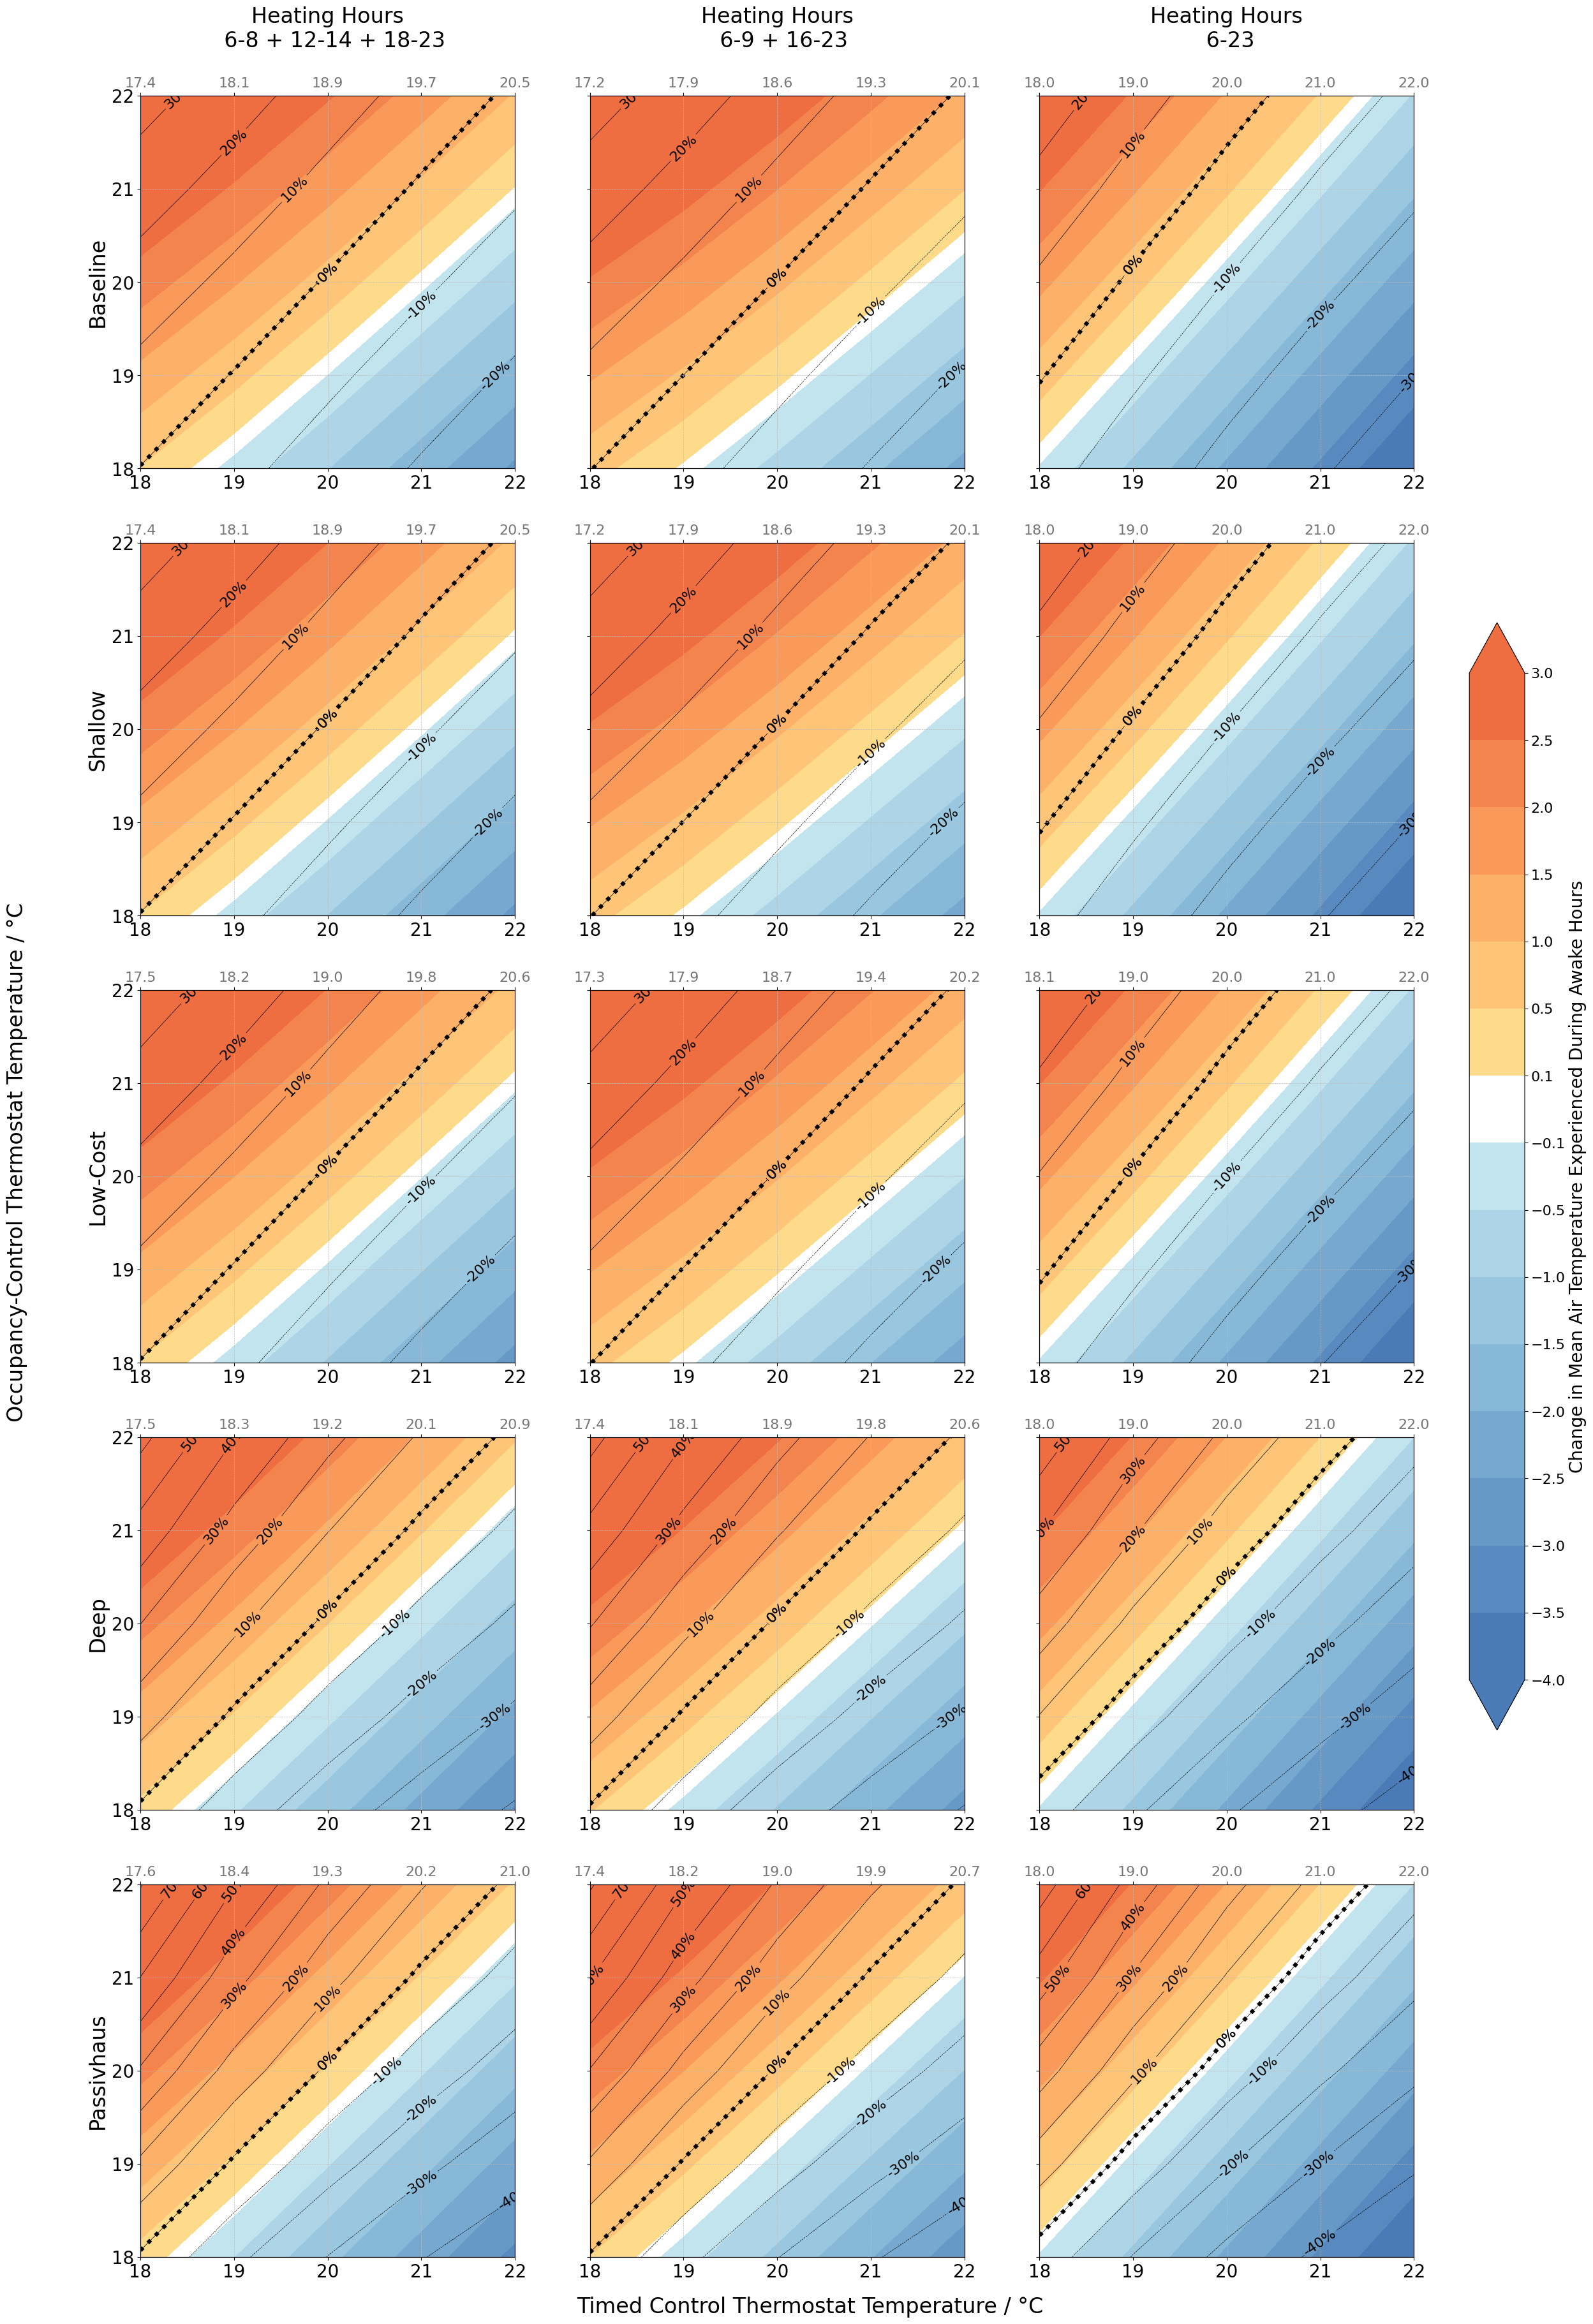

In [19]:
produce_emission_cost_contour(merged_df, "air", 'mean')

In [20]:
# baseline_0 = combined_df[combined_df["zone"] == 0].set_index(["pattern", "comforttemp"])
# filtered_baseline_0 = baseline_0[["mean_episode_emissions", "air_awake_mean_temp", 'mean_episode_cost']]


# baseline_9 = combined_df[combined_df["zone"] == 9].set_index(["pattern", "comforttemp"])
# filtered_baseline_9 = baseline_9[["mean_episode_emissions", "air_awake_mean_temp", 'mean_episode_cost']]

# cases = combined_df['case'].unique()

# patterns = ["once", "twice", "thrice"]
# merged_results = {}

# for pattern in patterns:

#     if pattern == 'once':
#         # Filter for the current pattern
#         filtered_9 = filtered_baseline_9.loc[pattern].reset_index()
#         filtered_0 = filtered_baseline_0.loc[pattern].reset_index()

#     else:
#         filtered_9 = filtered_baseline_9.loc['once'].reset_index()
#         filtered_0 = filtered_baseline_0.loc[pattern].reset_index()

#         filtered_9['comforttemp'] = 1+ filtered_9['comforttemp']


#     # Merge on 'comforttemp'
#     merged = pd.merge(
#         filtered_0,
#         filtered_9,
#         on="comforttemp",
#         suffixes=("_zone0", "_zone9")
#     )

#     # Set 'comforttemp' back as the index
#     merged = merged.set_index("comforttemp")

#     # Store the merged DataFrame in the dictionary
#     merged_results[pattern] = merged

# # Access merged DataFrames by pattern name
# merged_once = merged_results["once"]
# merged_twice = merged_results["twice"]
# merged_thrice = merged_results["thrice"]

# # Concatenate all merged DataFrames into a single DataFrame
# merged_all = pd.concat(merged_results.values(), keys=merged_results.keys(), names=["pattern", "comforttemp"])

# # Reset index if needed
# merged_all_reset = merged_all.reset_index()



In [21]:
# baseline_0 = combined_df[(combined_df["case"] == 0) & (combined_df["zone"] == 0)].set_index(["pattern", "comforttemp"])
# filtered_baseline_0 = baseline_0[["mean_episode_emissions", "air_awake_mean_temp", 'mean_episode_cost']]


# baseline_9 = combined_df[(combined_df["case"] == 0) & (combined_df["zone"] == 9)].set_index(["pattern", "comforttemp"])
# filtered_baseline_9 = baseline_9[["mean_episode_emissions", "air_awake_mean_temp", 'mean_episode_cost']]
# filtered_baseline_9_once = filtered_baseline_9.loc["once"]
# filtered_baseline_9_once = filtered_baseline_9_once.reset_index()
# filtered_baseline_9_once["comforttemp"] += 1
# filtered_baseline_9_once = filtered_baseline_9_once.set_index("comforttemp")

# # Ensure filtered_baseline_0 has 'comforttemp' as an index for alignment
# filtered_baseline_0 = filtered_baseline_0.reset_index().set_index("comforttemp")

# # Merge on 'comforttemp'
# merged_baselines = filtered_baseline_0.merge(
#     filtered_baseline_9_once,
#     left_index=True,
#     right_index=True,
#     suffixes=("_zone0", "_zone9")
# )

# merged_baselines["relative_emissions"] = (
#     (merged_baselines["mean_episode_emissions_zone0"] - merged_baselines["mean_episode_emissions_zone9"])
#     / merged_baselines["mean_episode_emissions_zone0"]
# ) * -100

# merged_baselines["relative_cost"] = (
#     (merged_baselines["mean_episode_cost_zone0"] - merged_baselines["mean_episode_cost_zone9"])
#     / merged_baselines["mean_episode_cost_zone0"]
# ) * -100


# summary_stats = pd.DataFrame({
#     "Metric": ["Mean", "Standard Deviation"],
#     "mean_emissions": [
#         merged_baselines["mean_episode_emissions_zone9"].mean(),
#         merged_baselines["mean_episode_emissions_zone9"].std()
#     ],
#     "mean_cost": [
#         merged_baselines["mean_episode_cost_zone9"].mean(),
#         merged_baselines["mean_episode_cost_zone9"].std()
#     ],
#     "relative_emissions": [
#         merged_baselines["relative_emissions"].mean(),
#         merged_baselines["relative_emissions"].std()
#     ],
#     "relative_cost": [
#         merged_baselines["relative_cost"].mean(),
#         merged_baselines["relative_cost"].std()
#     ],

# })


In [22]:
# def find_matching_comforttemp(row, df, tolerance=0.5):
#     if row['zone'] == 0:
#         candidates = df[(df['pattern'] == row['pattern']) & (df['zone'] != 0) & (df['case'] == row['case'])]
#         matches = candidates[
#             (candidates['air_awake_mean_temp'] >= row['air_awake_mean_temp'] - tolerance) &
#             (candidates['air_awake_mean_temp'] <= row['air_awake_mean_temp'] + tolerance)
#         ]
#         if not matches.empty:
#             return matches.iloc[0]['comforttemp']
#     return None

# combined_df['matched_comforttemp'] = combined_df.apply(lambda row: find_matching_comforttemp(row, combined_df), axis=1)


In [23]:
def calculate_all_cases_reduction():
    # Filter baseline data (case 0, zone 0)
    baseline = results_df[(results_df["case"] == 0) & (results_df["zone"] == 0)].set_index(["pattern", "comforttemp"])

    # Merge each case-zone combination with the baseline to calculate percentage reductions
    comparison_df = results_df.merge(
        baseline[["mean_episode_emissions", "mean_episode_cost"]],
        on=["pattern", "comforttemp"],
        suffixes=("", "_baseline")
    )

    comparison_df["relative_emissions"] = (
        (comparison_df["mean_episode_emissions_baseline"] - comparison_df["mean_episode_emissions"])
        / comparison_df["mean_episode_emissions_baseline"]
    ) * -100

    comparison_df["relative_cost"] = (
        (comparison_df["mean_episode_cost_baseline"] - comparison_df["mean_episode_cost"])
        / comparison_df["mean_episode_cost_baseline"]
    ) * -100

    # Group by 'case' and 'zone' to calculate the mean and std of emissions reduction
    summary_df = comparison_df.groupby(["case", "zone"]).agg(
        mean_emissions=('mean_episode_emissions', 'mean'),
        std_emissions=('mean_episode_emissions', 'std'),
        mean_cost=('mean_episode_cost', 'mean'),
        std_cost=('mean_episode_cost', 'std'),
        relative_emissions=("relative_emissions", "mean"),
        relative_emissions_std=("relative_emissions", "std"),
        relative_cost=("relative_cost", "mean"),
        relative_cost_std=("relative_cost", "std")
    ).reset_index()


    return summary_df

In [24]:
summary_df = calculate_all_cases_reduction()

In [25]:
summary_df = summary_stats

In [26]:


merged_df = pd.merge(summary_df, building_cost_df, on='case', how='left')
merged_df = pd.merge(merged_df, sensing_cost_df, on='zone', how='left')
merged_df = pd.merge(merged_df, case_names_df, on='case', how='left')

merged_df["installation_cost"] = merged_df["building_cost"] + merged_df["sensing_cost"]


merged_df["mean_emissions"] = merged_df["mean_emissions"] / 1000
merged_df["mean_cost"] = merged_df["mean_cost"] / 100


merged_df["bill_saving"] = -1 * (merged_df["mean_cost"] - merged_df["mean_cost"].iloc[0])

merged_df["payback"] = merged_df["installation_cost"] / merged_df["bill_saving"]

In [27]:
merged_df

,case,mean_emissions,std_emissions,mean_cost,std_cost,relative_emissions,relative_emissions_std,relative_cost,relative_cost_std,zone,building_cost,sensing_cost,control_names,retrofit_name,installation_cost,bill_saving,payback
0,0,1.946901,254.060872,589.739566,7416.526258,0.000000,0.000000,0.000000,0.000000,0,0,0,Manual Control,Baseline,0,-0.000000,NaN
1,0,1.785062,174.700317,542.243835,5044.705752,-7.915658,3.916107,-7.672966,3.841621,9,0,180,Full Control,Baseline,180,47.495731,3.789814
2,1,1.792229,237.520364,543.738362,6939.825510,-7.968535,0.293930,-7.821585,0.273058,0,400,0,Manual Control,Fabric - Low cost,400,46.001204,8.695425
3,1,1.649807,180.709636,501.852450,5218.939637,-14.989518,3.407318,-14.638635,3.320222,9,400,180,Full Control,Fabric - Low cost,580,87.887116,6.599375
4,2,1.673199,224.708056,507.976514,6570.402268,-14.100116,0.558117,-13.902244,0.532340,0,6350,0,Manual Control,Fabric - Shallow,6350,81.763053,77.663441
5,2,1.530045,158.600429,465.921725,4586.907123,-21.124523,3.036931,-20.716612,2.995480,9,6350,180,Full Control,Fabric - Shallow,6530,123.817842,52.738764
6,3,0.423121,71.570566,129.482543,2147.435761,-78.357803,1.206102,-78.135988,1.227115,0,18450,0,Manual Control,Fabric - Deep,18450,460.257024,40.086298
7,3,0.388872,66.823682,119.060683,1991.403003,-80.113476,1.009289,-79.897190,1.014221,9,18450,180,Full Control,Fabric - Deep,18630,470.678884,39.581126
8,4,0.230902,46.783316,71.364253,1413.377926,-88.235128,0.943771,-87.992856,0.957679,0,29500,0,Manual Control,Fabric - Passivhaus,29500,518.375313,56.908574
9,4,0.215262,45.057538,66.592393,1348.638164,-89.040087,0.924757,-88.800977,0.921532,9,29500,180,Full Control,Fabric - Passivhaus,29680,523.147173,56.733557


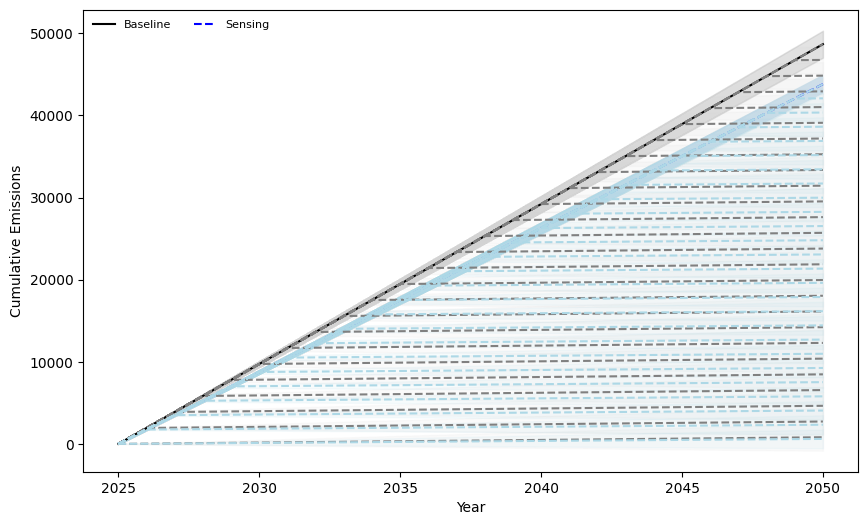

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem

years = np.arange(2025, 2051)

def get_emissions_with_ci(df, case_filter, zone_filter):
    emissions = []
    for pattern in df['pattern'].unique():
        for comfort_temp in df['comforttemp'].unique():
            filtered = df[(df['case'] == case_filter) &
                          (df['pattern'] == pattern) &
                          (df['comforttemp'] == comfort_temp) &
                          (df['zone'] == zone_filter)]
            if not filtered.empty:
                emissions.append(filtered['mean_episode_emissions'].values[0])
    emissions = np.array(emissions)
    mean_emissions = emissions.mean() * np.arange(0, len(years))
    ci = sem(emissions) * np.arange(0, len(years))
    return mean_emissions, ci

baseline_mean, baseline_ci = get_emissions_with_ci(combined_df, case_filter=0, zone_filter=0)
sensing_mean, sensing_ci = get_emissions_with_ci(combined_df, case_filter=0, zone_filter=9)
retrofit_growth, retrofit_ci_growth = get_emissions_with_ci(combined_df, case_filter=14, zone_filter=0)
retrofit_sensing_growth, retrofit_sensing_ci_growth = get_emissions_with_ci(combined_df, case_filter=14, zone_filter=9)

# Preallocate arrays for retrofit scenarios
retrofit_means = []
retrofit_cis = []
retrofit_sensing_means = []
retrofit_sensing_cis = []

# Calculate emissions for retrofit starting in each year
for retrofit_start in range(len(years)):
    retrofit_mean = np.zeros(len(years))
    retrofit_ci = np.zeros(len(years))
    retrofit_sensing_mean = np.zeros(len(years))
    retrofit_sensing_ci = np.zeros(len(years))

    # Assign baseline values up to the retrofit start year
    retrofit_mean[:retrofit_start] = baseline_mean[:retrofit_start]
    retrofit_ci[:retrofit_start] = baseline_ci[:retrofit_start]
    retrofit_sensing_mean[:retrofit_start] = sensing_mean[:retrofit_start]
    retrofit_sensing_ci[:retrofit_start] = sensing_ci[:retrofit_start]

    # Add retrofit growth after the retrofit start year
    retrofit_mean[retrofit_start:] = baseline_mean[retrofit_start] + retrofit_growth[:len(years) - retrofit_start]
    retrofit_ci[retrofit_start:] = np.sqrt(baseline_ci[retrofit_start:]**2 + retrofit_ci_growth[:len(years) - retrofit_start]**2)

    retrofit_sensing_mean[retrofit_start:] = sensing_mean[retrofit_start] + retrofit_sensing_growth[:len(years) - retrofit_start]
    retrofit_sensing_ci[retrofit_start:] = np.sqrt(sensing_ci[retrofit_start:]**2 + retrofit_sensing_ci_growth[:len(years) - retrofit_start]**2)

    # Store results
    retrofit_means.append(retrofit_mean)
    retrofit_cis.append(retrofit_ci)
    retrofit_sensing_means.append(retrofit_sensing_mean)
    retrofit_sensing_cis.append(retrofit_sensing_ci)

# Plotting
plt.figure(figsize=(10, 6))

# Plot baseline
plt.fill_between(years, baseline_mean - baseline_ci, baseline_mean + baseline_ci, alpha=0.2, color='grey')
plt.plot(years, baseline_mean, label='Baseline', color='black')

# Plot sensing
plt.fill_between(years, sensing_mean - sensing_ci, sensing_mean + sensing_ci, alpha=0.2)
plt.plot(years, sensing_mean, label='Sensing', color='blue', linestyle='--')

# Plot retrofit scenarios dynamically
for i, retrofit_start in enumerate(years):
    label_suffix = f"Retrofit ({retrofit_start})"
    plt.fill_between(years, retrofit_means[i] - retrofit_cis[i], retrofit_means[i] + retrofit_cis[i], alpha=0.1, color='lightgrey')
    plt.plot(years, retrofit_means[i],  color='grey', linestyle='--')

# Plot retrofit + sensing scenarios dynamically
for i, retrofit_start in enumerate(years):
    label_suffix = f"Retrofit + Sensing ({retrofit_start})"
    plt.fill_between(years, retrofit_sensing_means[i] - retrofit_sensing_cis[i], retrofit_sensing_means[i] + retrofit_sensing_cis[i], alpha=0.1, color='lightblue')
    plt.plot(years, retrofit_sensing_means[i],  color='lightblue', linestyle='--')

plt.xlabel('Year')
plt.ylabel('Cumulative Emissions')
plt.legend(frameon=False, fontsize=8, loc='upper left', ncol=2)
plt.show()


In [29]:
def plot_emissions_cost_bar(df):

    condense_df = df[
        [
            "case",
            "zone",
            "mean_emissions",
            "std_emissions",
            "payback",
            "relative_emissions",
            'relative_emissions_std',
            'relative_cost',
            'relative_cost_std',
            "installation_cost"
        ]
    ]

    new_rows = interpolate_zones(condense_df, 0, zones_new=[1, 4], columns=[
        "mean_emissions",
        "std_emissions",
        "payback",
        "installation_cost",
        "relative_emissions",
        'relative_emissions_std',
        'relative_cost',
        'relative_cost_std'
    ])

    insert_index = condense_df[(condense_df["case"] == 0) & (condense_df["zone"] == 9)].index[0]

    df = pd.concat([condense_df.iloc[:insert_index], new_rows, condense_df.iloc[insert_index:]], ignore_index=True)

    df = df.fillna(1)

    combined = df[
        (df["case"] == 0) |
        (df["case"] == 1) |
        (df["case"] == 2) |
        (df["case"] == 3) |
        (df["case"] == 4) |
        (df["case"] == 5) |
        (df["case"] == 10) |
        (df["case"] == 14)
    ]

    # Plotting
    fig, ax1 = plt.subplots(figsize=(12, 6))

    control_df = combined[(combined["case"] == 0) & (combined["zone"] > 0)]
    fabric_df = combined[(combined["case"] < 5) &  (combined["case"] > 0)& (combined["zone"] == 0)]
    system_df =  combined[(combined["case"] > 4 ) &  (combined["case"] < 14 ) & (combined["zone"] == 0)]
    best_df = combined[((combined["case"] == 4 ) | (combined["case"] == 10 ) |(combined["case"] == 14 )) & (combined["zone"] == 9)]

    #bars = ax.bar(x_pos, mean_emissions, yerr=std_emissions, align='center', alpha=0.7, ecolor='black', capsize=10)

    control = control_df["relative_emissions"]
    fabric = fabric_df["relative_emissions"]
    system = system_df["relative_emissions"]
    best = best_df["relative_emissions"]

    control_std = control_df["relative_emissions_std"]
    fabric_std = fabric_df["relative_emissions_std"]
    system_std = system_df["relative_emissions_std"]
    best_std = best_df["relative_emissions_std"]

    savings_control =control_df["relative_cost"]
    savings_fabric =fabric_df["relative_cost"]
    savings_system =system_df["relative_cost"]
    savings_best =best_df["relative_cost"]

    savings_control_std = control_df["relative_cost_std"]
    savings_fabric_std = fabric_df["relative_cost_std"]
    savings_system_std = system_df["relative_cost_std"]
    savings_best_std = best_df["relative_cost_std"]

    range1 = np.arange(0,3)+0.5
    range2 = np.arange(3,7)+1
    range3 = np.arange(7,9)+1.5
    range4 = np.arange(9,12)+2

    ranges_concatenated = np.concatenate([range1,range2,range3,range4])

    colour_length = len(ranges_concatenated)

    intermediate_colors = INTERMEDIATE_COLOURS[1:colour_length+1]

    # Plot bars
    #base = ax1.bar(np.arange(1), savings_baselines, color=intermediate_colors[0], width=0.5, alpha=0.6, label='Baseline')
    cont = ax1.bar(range1, control, yerr=control_std, color=control_colours, width=0.5, alpha=0.6, label='Emissions')
    fab = ax1.bar(range2, fabric, yerr=fabric_std, color=fabric_colours, width=0.5, alpha=0.6)
    sys = ax1.bar(range3, system, yerr=system_std, color=energy_colours, width=0.5, alpha=0.6)
    bes = ax1.bar(range4, best, yerr=best_std, color=combo_colours, width=0.5, alpha=0.6)

    # Add data labels
    for bar in cont:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2, height - 15, f'{height:.2g}', color='black', ha='center', va='bottom')
    for bar in fab:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2, height - 15, f'{height:.2g}', color='black', ha='center', va='bottom')

    for bar in sys:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2, height - 15, f'{height:.2g}', color='black', ha='center', va='bottom')

    for bar in bes:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2, height - 15, f'{height:.2g}', color='black', ha='center', va='bottom')

        # Secondary y-axis
    ax2 = ax1.twinx()

    # Adding scatter points with error bars (relative_cost_std as error)
    ax2.errorbar(range1, savings_control, yerr=savings_control_std, fmt='o', color='#005800', label='Bills', linestyle='none', capsize=5)
    ax2.errorbar(range2, savings_fabric, yerr=savings_fabric_std, fmt='o', color='#005800', linestyle='none', capsize=5)
    ax2.errorbar(range3, savings_system, yerr=savings_system_std, fmt='o', color='#005800', linestyle='none', capsize=5)
    ax2.errorbar(range4, savings_best, yerr=savings_best_std, fmt='o', color='#005800', linestyle='none', capsize=5)

    # Function to format scatter labels without scientific notation
    def format_no_scientific(value, sig_figs=2):
        if value == 0:
            return "0"
        elif abs(value) >= 100:
            return f'{value:.0f}'
        else:
            return f'{value:.{sig_figs}g}'

    # Add scatter labels for points
    def add_scatter_labels(ax, x_data, y_data):
        for (x, y) in zip(x_data, y_data):
            formatted_y = format_no_scientific(y, sig_figs=2)
            offset = 5 if y > 0 else -25
            if y+offset < -120:
                offset=-25
            offset=5
            ax.text(x, y + offset, formatted_y, color="#005800", ha='center', va='bottom')

    # Add labels to the scatter points
    add_scatter_labels(ax2, range1, savings_control)
    add_scatter_labels(ax2, range2, savings_fabric)
    add_scatter_labels(ax2, range3, savings_system)
    add_scatter_labels(ax2, range4, savings_best)

    # Add labels
    plt.text(1.5, 130, 'Control Improvement', ha='center', va='center', color=control_colours[0])
    plt.text(5.5, 130, 'Fabric Improvement', ha='center', va='center', color=fabric_colours[0])
    plt.text(9, 130, 'Energy System\nImprovement', ha='center', va='center', color=energy_colours[0])
    plt.text(12, 130, 'Combo', ha='center', va='center', color=combo_colours[0])
    plt.xticks(ranges_concatenated, custom_labels, rotation=60, ha='right')


    # Add labels
    ax1.set_xticks(ranges_concatenated)
    ax1.set_xticklabels(custom_labels, rotation=60, ha='right')
    ax1.set_ylim([-150,150])
    ax2.set_ylim([-150,150])

    ax1.axhline(xmin=0, xmax=14, y=0, color="black", linestyle='-', linewidth=1, zorder=0)

    # Add titles
    ax1.set_ylabel('Percentage Change Relative to Baseline')
    ax2.axis('off')

    #ax1.vlines(x=0.75, ymin=0, ymax=100, color='gray', linestyle='--')
    ax1.vlines(x=3.25, ymin=-100, ymax=100, color='gray', linestyle='--')
    ax1.vlines(x=7.75, ymin=-100, ymax=100, color='gray', linestyle='--')
    ax1.vlines(x=10.25, ymin=-100, ymax=100, color='gray', linestyle='--')

    ax1.legend(loc='upper left', bbox_to_anchor=(0.05, 0.25), frameon=False)
    ax2.legend(loc='upper right', bbox_to_anchor=(0.15, 0.3), frameon=False)
    plt.savefig("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/emissions_cost_bar_scatter.pdf")
    plt.show()

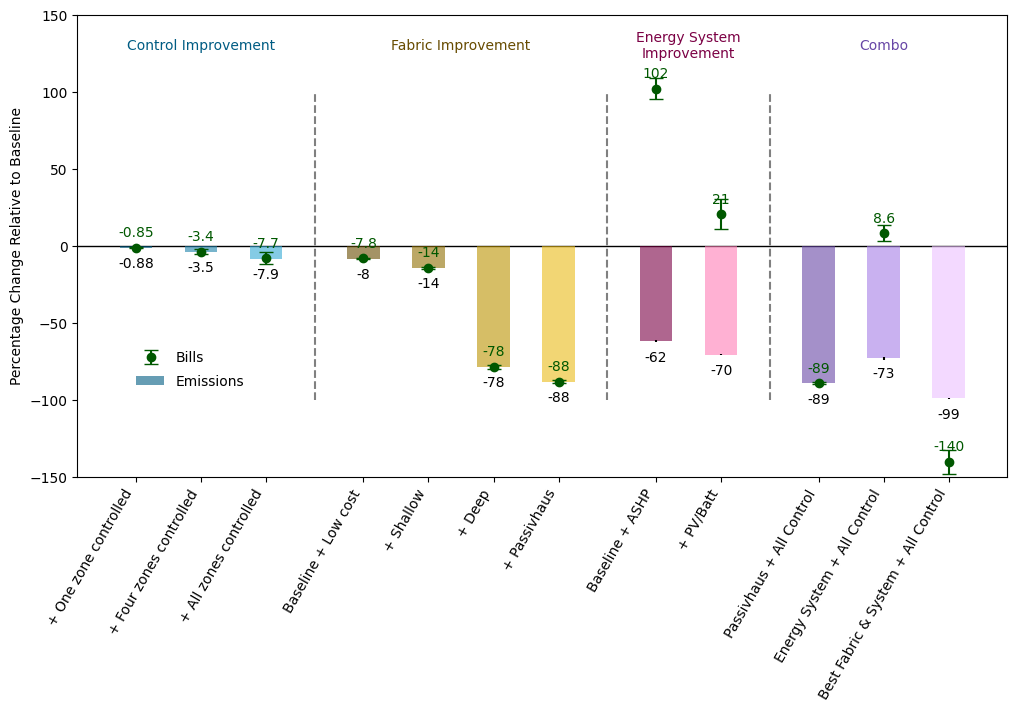

In [30]:
plot_emissions_cost_bar(merged_df)

In [31]:
def plot_emissions_cost_scatter(df):
    condense_df = df[
        [
            "case",
            "zone",
            "mean_emissions",
            "std_emissions",
            "payback",
            "installation_cost"
        ]
    ]

    # Interpolate new rows for zones 1 and 4 for case 0
    new_rows = interpolate_zones(condense_df, case=0, zones_new=[1, 4])

    # Insert new rows before the row where `case == 0` and `zone == 9`
    insert_index = condense_df[(condense_df["case"] == 0) & (condense_df["zone"] == 9)].index[0]
    df = pd.concat([condense_df.iloc[:insert_index], new_rows, condense_df.iloc[insert_index:]], ignore_index=True)

    # Fill NaN values if any
    df = df.fillna(1)

    combined = df[
        (df["case"] == 0) |
        (df["case"] == 1) |
        (df["case"] == 2) |
        (df["case"] == 3) |
        (df["case"] == 4) |
        (df["case"] == 5) |
        (df["case"] == 10) |
        (df["case"] == 14)
    ]

    control_df = combined[(combined["case"] == 0) & (combined["zone"] > 0)]
    fabric_df = combined[(combined["case"] < 5) &  (combined["case"] > 0) & (combined["zone"] == 0)]
    system_df = combined[(combined["case"] > 4) &  (combined["case"] < 14) & (combined["zone"] == 0)]
    best_df = combined[((combined["case"] == 4) | (combined["case"] == 10) | (combined["case"] == 14)) & (combined["zone"] == 9)]

    plot_df = pd.concat([control_df, fabric_df, system_df, best_df])

    colour_length = len(plot_df)

    intermediate_colors = INTERMEDIATE_COLOURS[1:colour_length+1]

    x = plot_df['installation_cost']
    y = plot_df['mean_emissions']
    z = plot_df['payback']

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(x, y, color=intermediate_colors)
    ax = plt.gca()  # Get the current axis

    # Set custom x-ticks
    plt.xticks(ticks=np.arange(0, 130000, 10000), labels=[f'{int(x/1000)}' for x in np.arange(0, 130000, 10000)])

    # Annotate points
    count = 0
    for i, row in plot_df.iterrows():

        if row["payback"] > 0:
            if row["payback"] > 100:
                annotation_text = f"{int(round(row['payback'], -1))}"  # Round to nearest 10, no scientific notation
            else:
                annotation_text = f"{row['payback']:.0f}"
            plt.annotate(annotation_text, (row['installation_cost'], row['mean_emissions']), textcoords="offset points", xytext=(5, 5), ha='center', color='black')
        else:
            plt.annotate(r"$\infty$", (row['installation_cost'], row['mean_emissions']), fontsize=16, textcoords="offset points", xytext=(-12, 0), ha='center', color=intermediate_colors[count])

        count += 1

    # Set limits and labels
    plt.ylim([0, 2.25])
    plt.xlim([-1000, 75000])
    plt.axhline(y=combined["mean_emissions"].iloc[0], color="gray", linestyle='--', linewidth=1, zorder=0)
    plt.text(x=70000, y=combined["mean_emissions"].iloc[0] + 0.05, s=f"Mean Baseline Emissions: {combined['mean_emissions'].iloc[0]:.1f} tCO2e", color="gray", ha='right')
    plt.xlabel('Installation Cost / k£')
    plt.ylabel('Annual Emissions / tCO2e')

    # Set legend
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=intermediate_colors[i], markersize=10) for i in range(min(colour_length, 12))]
    labels = ['One Zone', 'Four Zones', 'Nine Zones', 'Low Cost', 'Shallow', 'Deep', 'Passivhaus', 'ASHP', 'ASHP + PV/Batt', 'Passivhaus + Nine Zone Control', 'ASHP+PV/Batt + Nine Zone Control', "Best Fabric + System + Control"]
    legend_obj = plt.legend(
                handles,
                labels[:len(handles)],
                title="",
                loc='center right',
                frameon=False,
                alignment='center',
                # bbox_to_anchor=(1, 0.95)  # Move legend down slightly
            )


    # Customize legend colors
    max_shift = max([t.get_window_extent().width for t in legend_obj.get_texts()])
    for i, t in enumerate(legend_obj.get_texts()):
        t.set_color(intermediate_colors[i])

    # Remove specific spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Additional text annotations
    plt.text(x=50000, y=1.40, s="Control", color=intermediate_colors[0], ha='right')
    plt.text(x=50000, y=1.15, s="Fabric", color=intermediate_colors[3], ha='right')
    plt.text(x=50000, y=0.95, s="System", color=intermediate_colors[7], ha='right')
    plt.text(x=50000, y=0.75, s="Combo", color=intermediate_colors[9], ha='right')


    plt.savefig("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/payback_scatter.pdf")
    plt.show()

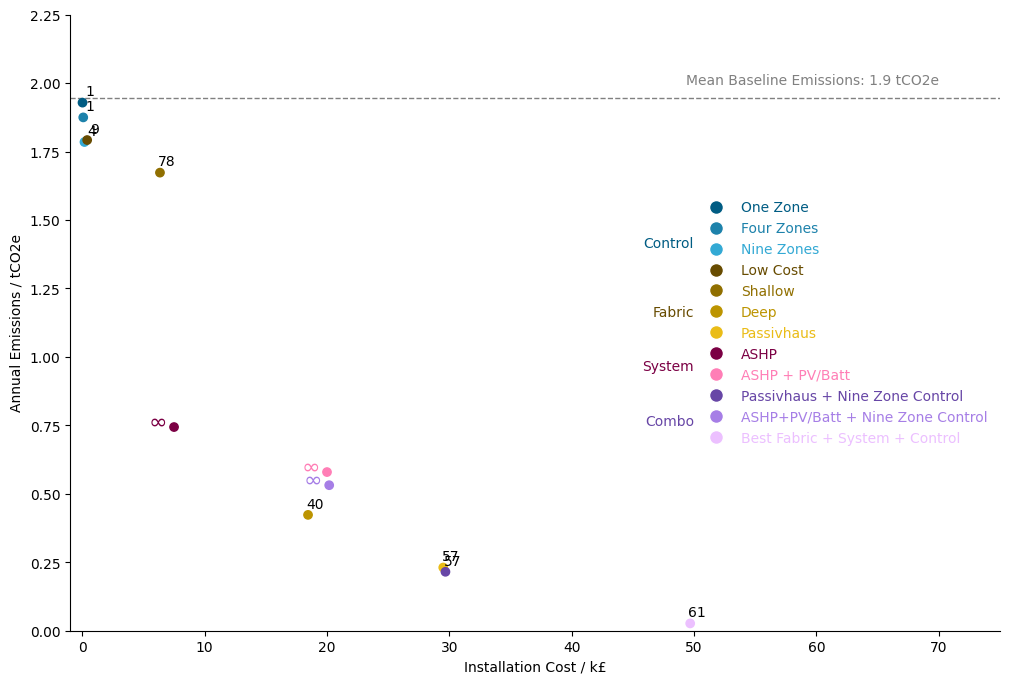

In [32]:
plot_emissions_cost_scatter(merged_df)

In [33]:


def prepare_data_for_plotting(df):
    cases, cont, nocont, sw, hw, all, cont_emissions, nocont_emissions = [], [], [], [], [], [], [], []
    cont_std, nocont_std, cont_emissions_std, nocont_emissions_std = [], [], [], []

    unique_cases = df["case"].unique()

    for case in unique_cases:
        nc = df[(df["case"] == case) & (df["zone"] == 0)]
        c = df[(df["case"] == case) & (df["zone"] == 9)]

        if c.empty or nc.empty:
            continue

        cases.append(case)
        cont.append(c["mean_cost"].values[0])
        nocont.append(nc["mean_cost"].values[0])
        cont_emissions.append(c["mean_emissions"].values[0])
        nocont_emissions.append(nc["mean_emissions"].values[0])
        cont_std.append(c["std_cost"].values[0])
        nocont_std.append(nc["std_cost"].values[0])
        cont_emissions_std.append(c["std_emissions"].values[0])
        nocont_emissions_std.append(nc["std_emissions"].values[0])
        hw.append(nc["building_cost"].values[0])
        sw.append(c["sensing_cost"].values[0])
        all.append(c["installation_cost"].values[0])

    data = {
        "case": cases,
        "nc_emissions": nocont_emissions,
        "c_emissions": cont_emissions,
        "nc": nocont,
        "c": cont,
        "nc_std": nocont_std,
        "c_std": cont_std,
        "nc_emissions_std": nocont_emissions_std,
        "c_emissions_std": cont_emissions_std,
        "hw": hw,
        "sw": sw,
        "all": all
    }

    result_df = pd.DataFrame(data).sort_values(by="case")

    def get_reference_case(case):
        if case == 5 or case == 0:
            return 0
        elif case == 10:
            return 5
        else:
            return case - 1

    result_df["reference_case"] = result_df["case"].apply(get_reference_case)

    for index, row in result_df.iterrows():
        ref_case = row["reference_case"]

        if ref_case not in result_df["case"].values:
            continue

        ref_row = result_df[result_df["case"] == ref_case].iloc[0]

        if (ref_row["nc"] - row["c"]) != 0:
            result_df.loc[index, "sw_pb_ref"] = row["sw"] / (ref_row["nc"] - row["c"])
        else:
            result_df.loc[index, "sw_pb_ref"] = np.nan

        if (result_df["nc"].iloc[0] - row["c"]) != 0:
            result_df.loc[index, "sw_pb_0"] = row["sw"] / (result_df["nc"].iloc[0] - row["c"])
        else:
            result_df.loc[index, "sw_pb_0"] = np.nan

        if (row["nc"] - row["c"]) != 0:
            result_df.loc[index, "sw_pb"] = row["sw"] / (row["nc"] - row["c"])
        else:
            result_df.loc[index, "sw_pb"] = np.nan

        if (ref_row["nc"] - row["nc"]) != 0:
            result_df.loc[index, "hw_pb_ref"] = (row["hw"] - ref_row["hw"]) / (ref_row["nc"] - row["nc"])
        else:
            result_df.loc[index, "hw_pb_ref"] = np.nan

        if (result_df["nc"].iloc[0] - row["nc"]) != 0:
            result_df.loc[index, "hw_pb_0"] = row["hw"] / (result_df["nc"].iloc[0] - row["nc"])
        else:
            result_df.loc[index, "hw_pb_0"] = np.nan

        if (ref_row["nc"] - row["c"]) != 0:
            result_df.loc[index, "all_pb_ref"] = (row["all"] - ref_row["all"]) / (ref_row["nc"] - row["c"])
        else:
            result_df.loc[index, "all_pb_ref"] = np.nan

        if (result_df["nc"].iloc[0] - row["c"]) != 0:
            result_df.loc[index, "all_pb_0"] = row["all"] / (result_df["nc"].iloc[0] - row["c"])
        else:
            result_df.loc[index, "all_pb_0"] = np.nan

    result_df = result_df.drop(columns=["reference_case"])

    # Normalise costs and emissions, including standard deviations
    nc_0 = result_df.loc[result_df['case'] == 0, 'nc'].values[0]
    result_df['nc_normalized'] = result_df['nc'] / nc_0
    result_df['c_normalized'] = result_df['c'] / nc_0
    result_df['nc_std_normalized'] = result_df['nc_std'] / nc_0
    result_df['c_std_normalized'] = result_df['c_std'] / nc_0

    nc_emissions_0 = result_df.loc[result_df['case'] == 0, 'nc_emissions'].values[0]
    result_df['nc_emissions_normalized'] = result_df['nc_emissions'] / nc_emissions_0
    result_df['c_emissions_normalized'] = result_df['c_emissions'] / nc_emissions_0
    result_df['nc_emissions_std_normalized'] = result_df['nc_emissions_std'] / (nc_emissions_0*1000)
    result_df['c_emissions_std_normalized'] = result_df['c_emissions_std'] / (nc_emissions_0*1000)

    result_df = result_df.reset_index(drop=True)

    return result_df





In [34]:
test = prepare_data_for_plotting(merged_df)

In [35]:
def plot_emission_subplots(df):
    cases = df["case"].values
    labels = ["Timed Cont.", "Zonal Cont."]

    fig, axs = plt.subplots(3, 5, figsize=(15, 10), sharey=True, sharex=True)
    axs = axs.flatten()

    case_order = [10, 11, 12, 13, 14, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4]

    x_labels = {0: "Baseline",
                1: "Shallow",
                2: "Low-cost",
                3: "Deep",
                4: "Passivhaus",
                }

    y_labels = {0: "Gas Boiler",
                5: "ASHP",
                10: "ASHP + PV + Batt",
                }

    def format_no_scientific(value, sig_figs=2):
        if isinstance(value, str):
            return value
        elif value == 0:
            return "0"
        elif abs(value) > 100:
            return "> 100"  # If greater than 100, display as > 100
        elif 100 <= abs(value) <= 1000:
            return f'{value:.0f}'
        elif abs(value) > 1000:
            return f'{value:.2g}'
        else:
            return f'{value:.{sig_figs}g}'

    for i, case in enumerate(case_order):
        if case in df["case"].values:
            nc = df.loc[df["case"] == case, "nc_emissions_normalized"].values[0]
            c = df.loc[df["case"] == case, "c_emissions_normalized"].values[0]
            nc_std = df.loc[df["case"] == case, "nc_emissions_std_normalized"].values[0]
            c_std = df.loc[df["case"] == case, "c_emissions_std_normalized"].values[0]
            hw_pb_ref = df.loc[df["case"] == case, "hw_pb_0"].values[0]
            all_pb_ref = df.loc[df["case"] == case, "all_pb_0"].values[0]
            sw_pb_ref = df.loc[df["case"] == case, "sw_pb"].values[0]

            bars = axs[i].bar(labels, [nc, c], yerr=[nc_std, c_std], color=['#ad747f', 'lightblue'], capsize=5)

            # Calculate y positions for annotations
            nc_error_top = nc + nc_std
            c_error_top = c + c_std
            sw_y = c_error_top + 0.15

            if 0.95 <= sw_y <= 1.05:
                sw_y = 0.9

            hw_all_y = sw_y + 0.15

            hw_pb_ref_annotation = "Reference" if pd.isna(hw_pb_ref) else ("Inf" if hw_pb_ref < 0 else format_no_scientific(hw_pb_ref))
            all_pb_ref_annotation = "Inf" if all_pb_ref < 0 else format_no_scientific(all_pb_ref)
            sw_pb_ref_annotation = "Inf" if sw_pb_ref < 0 else format_no_scientific(sw_pb_ref)

            axs[i].annotate(hw_pb_ref_annotation,
                            (bars[0].get_x() + bars[0].get_width() / 2, hw_all_y),
                            ha='center', va='bottom', color='#41121f')
            axs[i].annotate(all_pb_ref_annotation,
                            (bars[1].get_x() + bars[1].get_width() / 2, hw_all_y),
                            ha='center', va='bottom', color='#41121f')
            axs[i].annotate(sw_pb_ref_annotation,
                            (bars[1].get_x() + bars[1].get_width() / 2, sw_y),
                            ha='center', va='bottom', color='#002833')

            axs[i].set_ylim(0, 1.4)
            axs[i].set_yticks([0, 0.25, 0.5, 0.75, 1.0])

            # Remove top spine and limit left spine to [0, 1]
            axs[i].spines['top'].set_visible(False)
            axs[i].spines['left'].set_bounds(0, 1)
            axs[i].spines['right'].set_bounds(0, 1)

            if i == 5:
                axs[i].set_ylabel('Relative Emissions to Case 0')

            if case in x_labels:
                axs[i].set_xlabel(x_labels[case], fontsize=16)
            if case in y_labels:
                axs[i].set_ylabel(y_labels[case], fontsize=16)

    plt.savefig("/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/emission_subplots.pdf")

    plt.show()


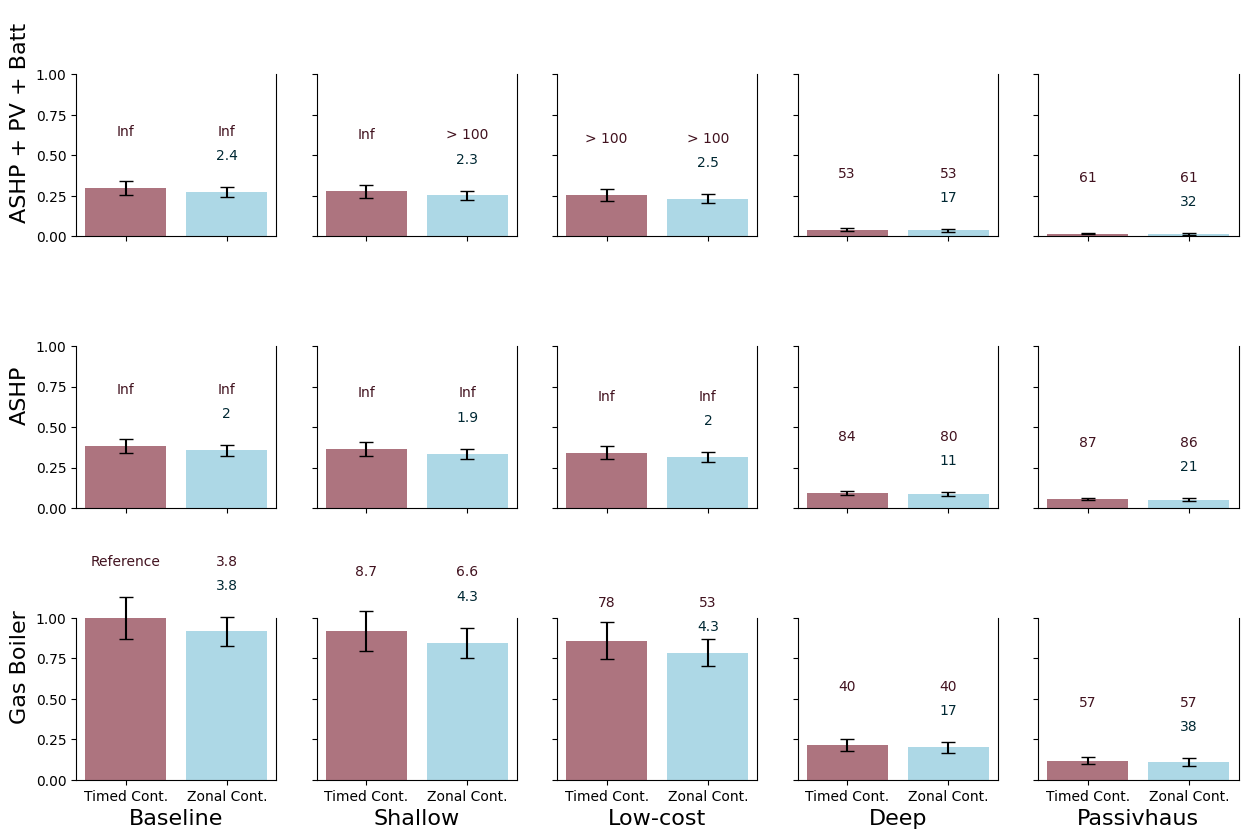

In [36]:
plot_emission_subplots(test)

In [37]:


# Room areas and total floor area (same as previously defined)
room_areas = {
    'kitchen': 11.34,
    'front_room': 14.04,
    'backroom': 11.34,
    'hall_downstairs': 7.02,
    'bedroom_1': 11.51,
    'bedroom_2': 12.39,
    'bedroom_3': 6.86,
    'bathroom': 7.105,
    'hall_upstairs': 5.88,
}
total_floor_area = sum(room_areas.values())

csv_files = [
        "all_months_air_all_months.csv",
        "all_months_air_ooh_all_months.csv",
        "all_months_air_sleep_all_months.csv",
        "all_months_opr_all_months.csv",
        "all_months_opr_ooh_all_months.csv",
        "all_months_opr_sleep_all_months.csv"
    ]

def collect_directories(base_dir):
    """
    Collects all relevant directory paths and metadata.

    Args:
        base_dir (str): The base directory containing data folders.

    Returns:
        list: List of dictionaries with directory paths and extracted metadata.
    """
    dir_info = []

    for dirpath, _, files in os.walk(base_dir):
        # Only process directories that contain any of the target files
        if any(file in files for file in csv_files):
            dir_info.append(dirpath)

    return dir_info

def calculate_weighted_temperatures(temp_df):
    # Your existing implementation for calculating mean and median
    temp_df = temp_df[(temp_df['Month'] < 4) | (temp_df['Month'] > 9)]
    temp_df.columns = list(temp_df.columns[:2]) + [str(round(i, 1)) for i in np.arange(14, 40, 0.1)]

    plotting_data = {}
    for room, area in room_areas.items():
        data = temp_df[temp_df["Zone"] == room]
        room_data = {col: (data[col].sum() * area) / total_floor_area for col in temp_df.columns[2:]}
        plotting_data[room] = room_data

    total_weighted_data = {col: sum(room_data[col] for room_data in plotting_data.values()) for col in temp_df.columns[2:]}
    weighted_df = pd.DataFrame(list(total_weighted_data.items()), columns=['Temperature', 'Weighted Count']).sort_values(by='Temperature')
    mean_temp = (weighted_df['Temperature'].astype(float) * weighted_df['Weighted Count']).sum() / weighted_df['Weighted Count'].sum()
    weighted_df['Cumulative Count'] = weighted_df['Weighted Count'].cumsum()
    median_temp = weighted_df[weighted_df['Cumulative Count'] >= weighted_df['Weighted Count'].sum() / 2].iloc[0]['Temperature']

    return mean_temp, median_temp


def process_files(dir_info):
    """
    Processes each directory and calculates weighted temperatures from CSV files.

    Args:
        dir_info (list): List of directory paths containing data files.

    Returns:
        pd.DataFrame: DataFrame containing mean and median temperatures for each file.
    """
    data = []

    for dir in dir_info:
        strin = dir.split("_")
        case = strin[1]
        zone = strin[7]
        pattern = strin[12]
        comforttemp = strin[15]

        # Process according to the pattern type
        if pattern != 'once':
            # Load the data files
            air_in_hours = pd.read_csv(os.path.join(dir, csv_files[0]))
            air_out_hours = pd.read_csv(os.path.join(dir, csv_files[1]))
            air_sleep_hours = pd.read_csv(os.path.join(dir, csv_files[2]))

            opr_in_hours = pd.read_csv(os.path.join(dir, csv_files[3]))
            opr_out_hours = pd.read_csv(os.path.join(dir, csv_files[4]))
            opr_sleep_hours = pd.read_csv(os.path.join(dir, csv_files[5]))

            # Concatenate data for awake and all hours
            air_awake_hours = pd.concat([air_in_hours, air_out_hours])
            opr_awake_hours = pd.concat([opr_in_hours, opr_out_hours])

            air_all_hours = pd.concat([air_awake_hours, air_sleep_hours])
            opr_all_hours = pd.concat([opr_awake_hours, opr_sleep_hours])
        else:
            # Load data files only for in-hours and sleep-hours
            air_in_hours = pd.read_csv(os.path.join(dir, csv_files[0]))
            air_sleep_hours = pd.read_csv(os.path.join(dir, csv_files[2]))

            opr_in_hours = pd.read_csv(os.path.join(dir, csv_files[3]))
            opr_sleep_hours = pd.read_csv(os.path.join(dir, csv_files[5]))

            # Concatenate data for all hours (no awake/out hours for `once`)
            air_all_hours = pd.concat([air_in_hours, air_sleep_hours])
            opr_all_hours = pd.concat([opr_in_hours, opr_sleep_hours])



        # Calculate weighted temperatures
        air_in_mean_temp, air_in_median_temp = calculate_weighted_temperatures(air_in_hours)
        air_sleep_mean_temp, air_sleep_median_temp = calculate_weighted_temperatures(air_sleep_hours)
        air_all_mean_temp, air_all_median_temp = calculate_weighted_temperatures(air_all_hours)

        opr_in_mean_temp, opr_in_median_temp = calculate_weighted_temperatures(opr_in_hours)
        opr_sleep_mean_temp, opr_sleep_median_temp = calculate_weighted_temperatures(opr_sleep_hours)
        opr_all_mean_temp, opr_all_median_temp = calculate_weighted_temperatures(opr_all_hours)

        if pattern != 'once':
            air_out_mean_temp, air_out_median_temp = calculate_weighted_temperatures(air_out_hours)
            air_awake_mean_temp, air_awake_median_temp = calculate_weighted_temperatures(air_awake_hours)

            opr_out_mean_temp, opr_out_median_temp = calculate_weighted_temperatures(opr_out_hours)
            opr_awake_mean_temp, opr_awake_median_temp = calculate_weighted_temperatures(opr_awake_hours)
        else:
            air_out_mean_temp = air_out_median_temp = None
            air_awake_mean_temp, air_awake_median_temp = air_in_mean_temp, air_in_median_temp

            opr_out_mean_temp = opr_out_median_temp = None
            opr_awake_mean_temp, opr_awake_median_temp = opr_in_mean_temp, opr_in_median_temp

        # Append results to the data list
        data.append({
            'case': case,
            'zone': zone,
            'pattern': pattern,
            'comforttemp': comforttemp,
            'air_in_mean_temp': air_in_mean_temp,
            'air_out_mean_temp': air_out_mean_temp,
            'air_sleep_mean_temp': air_sleep_mean_temp,
            'air_awake_mean_temp': air_awake_mean_temp,
            'air_all_mean_temp': air_all_mean_temp,
            'opr_in_mean_temp': opr_in_mean_temp,
            'opr_out_mean_temp': opr_out_mean_temp,
            'opr_sleep_mean_temp': opr_sleep_mean_temp,
            'opr_awake_mean_temp': opr_awake_mean_temp,
            'opr_all_mean_temp': opr_all_mean_temp,
            'air_in_median_temp': air_in_median_temp,
            'air_out_median_temp': air_out_median_temp,
            'air_sleep_median_temp': air_sleep_median_temp,
            'air_awake_median_temp': air_awake_median_temp,
            'air_all_median_temp': air_all_median_temp,
            'opr_in_median_temp': opr_in_median_temp,
            'opr_out_median_temp': opr_out_median_temp,
            'opr_sleep_median_temp': opr_sleep_median_temp,
            'opr_awake_median_temp': opr_awake_median_temp,
            'opr_all_median_temp': opr_all_median_temp,
        })

    # Convert the list of dictionaries to a DataFrame
    df = pd.DataFrame(data)
    return df


# Define the base directory and collect directory information
base_dir = "/workspaces/CUBES/results"
dir_info = collect_directories(base_dir)



In [38]:
# results_df = process_files(dir_info)
# temp_data = pd.read_csv("temperature_averages.csv")


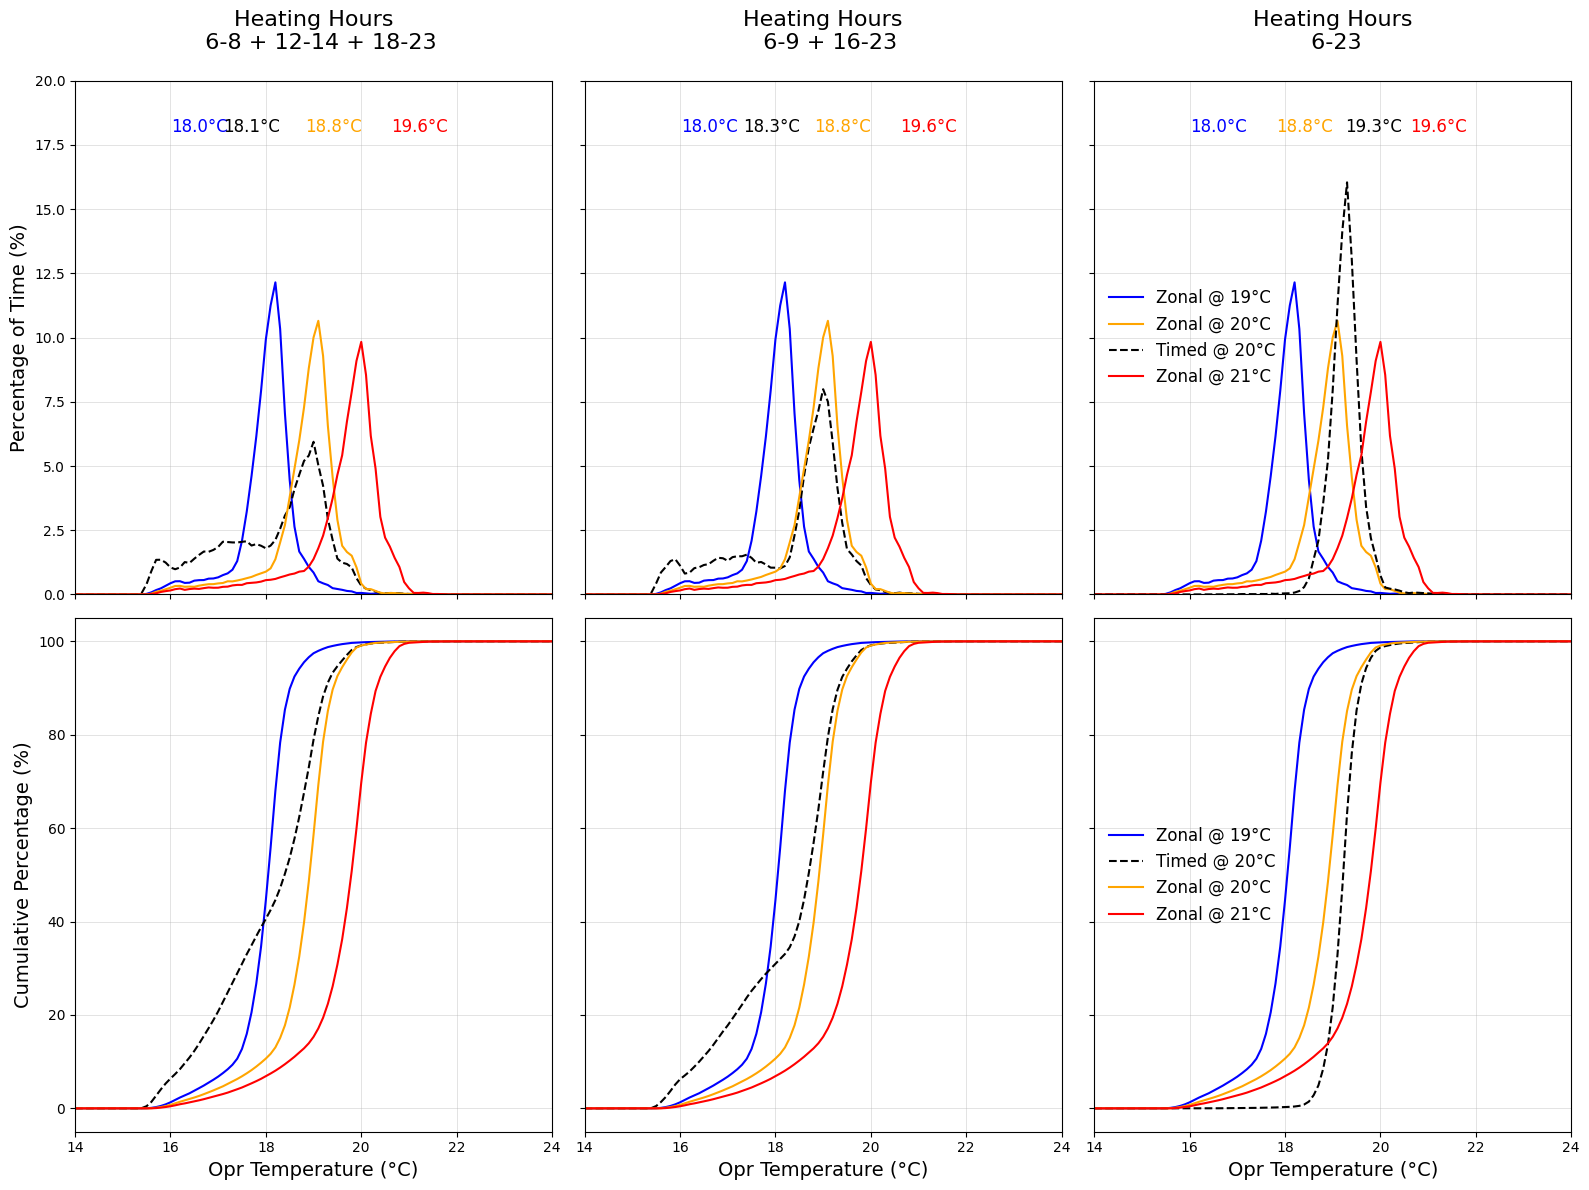

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def process_temperature_data(file_path_opr, file_path_ooh, room_areas, total_floor_area):
    temp_df_opr = pd.read_csv(file_path_opr)
    temp_df_ooh = pd.read_csv(file_path_ooh)

    if temp_df_ooh.shape[1] <= 2 or temp_df_ooh.empty:  # Check if only headers exist or if DataFrame is empty
        temp_df = temp_df_opr.copy()
    else:
        temp_df = temp_df_opr.add(temp_df_ooh, fill_value=0)

    temp_df['Month'] = temp_df_opr['Month']
    temp_df['Zone'] = temp_df_opr['Zone']

    temp_df = temp_df[(temp_df['Month'] < 5) | (temp_df['Month'] > 9)]
    rename_columns = [str(round(i, 1)) for i in np.arange(14, 40, 0.1)]
    temp_df.columns = list(temp_df.columns[:2]) + rename_columns

    plotting_data = {}
    for room, area in room_areas.items():
        data = temp_df[temp_df["Zone"] == room]
        room_data = {col: (data[col].sum() * area) / total_floor_area for col in rename_columns}
        plotting_data[room] = room_data

    total_weighted_data = {col: sum(room_data[col] for room_data in plotting_data.values()) for col in rename_columns}
    weighted_df = pd.DataFrame(list(total_weighted_data.items()), columns=['Temperature', 'Weighted Count'])
    weighted_df['Temperature'] = weighted_df['Temperature'].astype(float)
    weighted_df = weighted_df.sort_values(by='Temperature')

    total_count = weighted_df['Weighted Count'].sum()
    weighted_df['Percentage'] = (weighted_df['Weighted Count'] / total_count) * 100

    weighted_df['Cumulative Percentage'] = weighted_df['Percentage'].cumsum()

    weighted_median_temp = weighted_df[weighted_df['Cumulative Percentage'] >= 50].iloc[0]['Temperature']
    weighted_sum = (weighted_df['Temperature'] * weighted_df['Weighted Count']).sum()
    weighted_mean_temp = weighted_sum / weighted_df['Weighted Count'].sum()

    return weighted_df, weighted_median_temp, weighted_mean_temp

def plot_temperature_distributions(file_paths_opr, file_paths_ooh, room_areas, total_floor_area, titles, colours, linestyles, xlim=(15, 25)):
    plt.figure(figsize=(12, 8))
    for file_path_opr, file_path_ooh, title, colour, linestyle in zip(file_paths_opr, file_paths_ooh, titles, colours, linestyles):
        weighted_df, _, _ = process_temperature_data(file_path_opr, file_path_ooh, room_areas, total_floor_area)
        plt.plot(weighted_df['Temperature'], weighted_df['Percentage'], color=colour, linestyle=linestyle, label=title)
    plt.xlim(xlim)
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Percentage (%)')
    plt.title('Room-Weighted Temperature Distributions (Awake Hours)')
    plt.legend(frameon=False)
    plt.grid(True)
    plt.show()


def plot_cumulative_time_distributions(file_paths_opr, file_paths_ooh, room_areas, total_floor_area, titles, colours, linestyles, xlim=(15, 25)):
    plt.figure(figsize=(12, 8))
    for file_path_opr, file_path_ooh, title, colour, linestyle in zip(file_paths_opr, file_paths_ooh, titles, colours, linestyles):
        weighted_df, _, _ = process_temperature_data(file_path_opr, file_path_ooh, room_areas, total_floor_area)
        plt.plot(weighted_df['Temperature'], weighted_df['Cumulative Percentage'], linestyle=linestyle, color=colour, label=title)
    plt.xlim(xlim)
    plt.ylim(0, 100)
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Cumulative Percentage (%)')
    plt.title('Cumulative Time Distribution by Temperature (Awake Hours)')
    plt.legend(frameon=False)
    plt.grid(True)
    plt.show()


room_areas = {
    'kitchen': 11.34,
    'front_room': 14.04,
    'backroom': 11.34,
    'hall_downstairs': 7.02,
    'bedroom_1': 11.51,
    'bedroom_2': 12.39,
    'bedroom_3': 6.86,
    'bathroom': 7.105,
    'hall_upstairs': 5.88,
}
total_floor_area = sum(room_areas.values())

def get_temp_file_paths(temp_type, pattern, temp_0):
    titles = [
        f'Zonal @ {temp_0 - 1}°C',
        f'Timed @ {temp_0}°C',
        f'Zonal @ {temp_0}°C',
        f'Zonal @ {temp_0 + 1}°C'
    ]

    file_paths_opr = [
        f"/workspaces/CUBES/results/case_0_year_2023_rep_H28_zone_9_inactive_threshold_30_pattern_once_t_comfort_{temp_0 - 1}.0_t_setback_16.0_tags_thermostat_final_v5/all_months_{temp_type}_all_months.csv",
        f"/workspaces/CUBES/results/case_0_year_2023_rep_H28_zone_0_inactive_threshold_30_pattern_{pattern}_t_comfort_{temp_0}.0_t_setback_16.0_tags_thermostat_final_v5/all_months_{temp_type}_all_months.csv",
        f"/workspaces/CUBES/results/case_0_year_2023_rep_H28_zone_9_inactive_threshold_30_pattern_once_t_comfort_{temp_0}.0_t_setback_16.0_tags_thermostat_final_v5/all_months_{temp_type}_all_months.csv",
        f"/workspaces/CUBES/results/case_0_year_2023_rep_H28_zone_9_inactive_threshold_30_pattern_once_t_comfort_{temp_0 + 1}.0_t_setback_16.0_tags_thermostat_final_v5/all_months_{temp_type}_all_months.csv"
    ]

    file_paths_ooh = [
        f"/workspaces/CUBES/results/case_0_year_2023_rep_H28_zone_9_inactive_threshold_30_pattern_once_t_comfort_{temp_0 - 1}.0_t_setback_16.0_tags_thermostat_final_v5/all_months_{temp_type}_ooh_all_months.csv",
        f"/workspaces/CUBES/results/case_0_year_2023_rep_H28_zone_0_inactive_threshold_30_pattern_{pattern}_t_comfort_{temp_0}.0_t_setback_16.0_tags_thermostat_final_v5/all_months_{temp_type}_ooh_all_months.csv",
        f"/workspaces/CUBES/results/case_0_year_2023_rep_H28_zone_9_inactive_threshold_30_pattern_once_t_comfort_{temp_0}.0_t_setback_16.0_tags_thermostat_final_v5/all_months_{temp_type}_ooh_all_months.csv",
        f"/workspaces/CUBES/results/case_0_year_2023_rep_H28_zone_9_inactive_threshold_30_pattern_once_t_comfort_{temp_0 + 1}.0_t_setback_16.0_tags_thermostat_final_v5/all_months_{temp_type}_ooh_all_months.csv",
    ]

    colours = ['blue', 'black', 'orange', 'red']
    linestyles = ['-', '--', '-', '-']

    return file_paths_opr, file_paths_ooh, titles, colours, linestyles


def plot_combined_distributions_patterns(patterns, temp_type, temp_0, room_areas, total_floor_area, xlim=(14, 24)):
    fig, axs = plt.subplots(2, len(patterns), figsize=(16, 12), sharex=True, sharey='row')

    for col_idx, pattern in enumerate(patterns):
        # Get file paths, titles, colours, and linestyles for the current pattern
        file_paths_opr, file_paths_ooh, titles, colours, linestyles = get_temp_file_paths(temp_type, pattern, temp_0)

        # Process data and calculate mean temperatures
        data_with_means = []
        for file_path_opr, file_path_ooh, title, colour, linestyle in zip(file_paths_opr, file_paths_ooh, titles, colours, linestyles):
            weighted_df, _, weighted_mean_temp = process_temperature_data(file_path_opr, file_path_ooh, room_areas, total_floor_area)
            data_with_means.append((weighted_df, title, colour, linestyle, weighted_mean_temp))

        # Sort data by mean temperature
        data_with_means.sort(key=lambda x: x[4])  # Sort by weighted_mean_temp

        # Track previously annotated x-coordinates to avoid overlap
        annotated_x_coords = []

        if temp_type == 'opr':
            annot_height = 18
        else:
            annot_height = 90

        # Top row: Temperature Distribution
        for weighted_df, title, colour, linestyle, weighted_mean_temp in data_with_means:
            axs[0, col_idx].plot(weighted_df['Temperature'], weighted_df['Percentage'], color=colour, linestyle=linestyle, label=title)

            # Adjust x-coordinate for annotation if it overlaps
            x_position = weighted_mean_temp -2
            min_distance = 1  # Minimum distance between annotations
            while any(abs(x_position - x) < min_distance for x in annotated_x_coords):
                x_position += min_distance  # Shift annotation to the right

            annotated_x_coords.append(x_position)  # Track the adjusted x-coordinate

            # Annotate the mean temperature
            axs[0, col_idx].annotate(
                f'{weighted_mean_temp:.1f}°C',
                xy=(weighted_mean_temp, annot_height),
                xytext=(x_position, annot_height),
                fontsize=12,  # Change this value
                color=colour
            )


        if temp_type == 'opr':
            axs[0, col_idx].set_ylim([0,20])
        axs[0, col_idx].set_xlim(xlim)

        if col_idx == 0:
            axs[0, col_idx].set_ylabel('Percentage of Time (%)')
        axs[0, col_idx].grid(True, linewidth=0.5, alpha=0.5)
        if col_idx == len(patterns) - 1:
            axs[0, col_idx].legend(frameon=False, loc='center left', fontsize=12)

        if pattern == 'once':
            pattern_title = "Heating Hours\n 6-23\n"
        elif pattern == 'twice':
            pattern_title = "Heating Hours\n  6-9 + 16-23\n"
        elif pattern == 'thrice':
            pattern_title = "Heating Hours\n  6-8 + 12-14 + 18-23\n"


        axs[0, col_idx].set_title(pattern_title, fontsize=16)


        # Bottom row: Cumulative Distribution
        for file_path_opr, file_path_ooh, title, colour, linestyle in zip(file_paths_opr, file_paths_ooh, titles, colours, linestyles):
            weighted_df, _, _ = process_temperature_data(file_path_opr, file_path_ooh, room_areas, total_floor_area)
            axs[1, col_idx].plot(weighted_df['Temperature'], weighted_df['Cumulative Percentage'], color=colour, linestyle=linestyle, label=title)

        if col_idx == 0:
            axs[0, col_idx].set_ylabel('Percentage of Time (%)', fontsize=14)
            axs[1, col_idx].set_ylabel('Cumulative Percentage (%)', fontsize=14)
        axs[1, col_idx].set_xlabel(f'{temp_type.capitalize()} Temperature (°C)', fontsize=14)
        axs[1, col_idx].set_xlim(xlim)

        if col_idx == 0:
            axs[1, col_idx].set_ylabel('Cumulative Percentage (%)')
        axs[1, col_idx].grid(True, linewidth=0.5, alpha=0.5)
        if col_idx == len(patterns) - 1:
            axs[1, col_idx].legend(frameon=False, loc='center left', fontsize=12)



    plt.tight_layout()

    plt.savefig(f"/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/SI/{temp_type}_temperature_plot.pdf")
    plt.show()



# Define the patterns to compare
patterns = ['thrice', 'twice', 'once']

# Call the function with patterns
plot_combined_distributions_patterns(patterns, 'opr', temp_0=20, room_areas=room_areas, total_floor_area=total_floor_area)



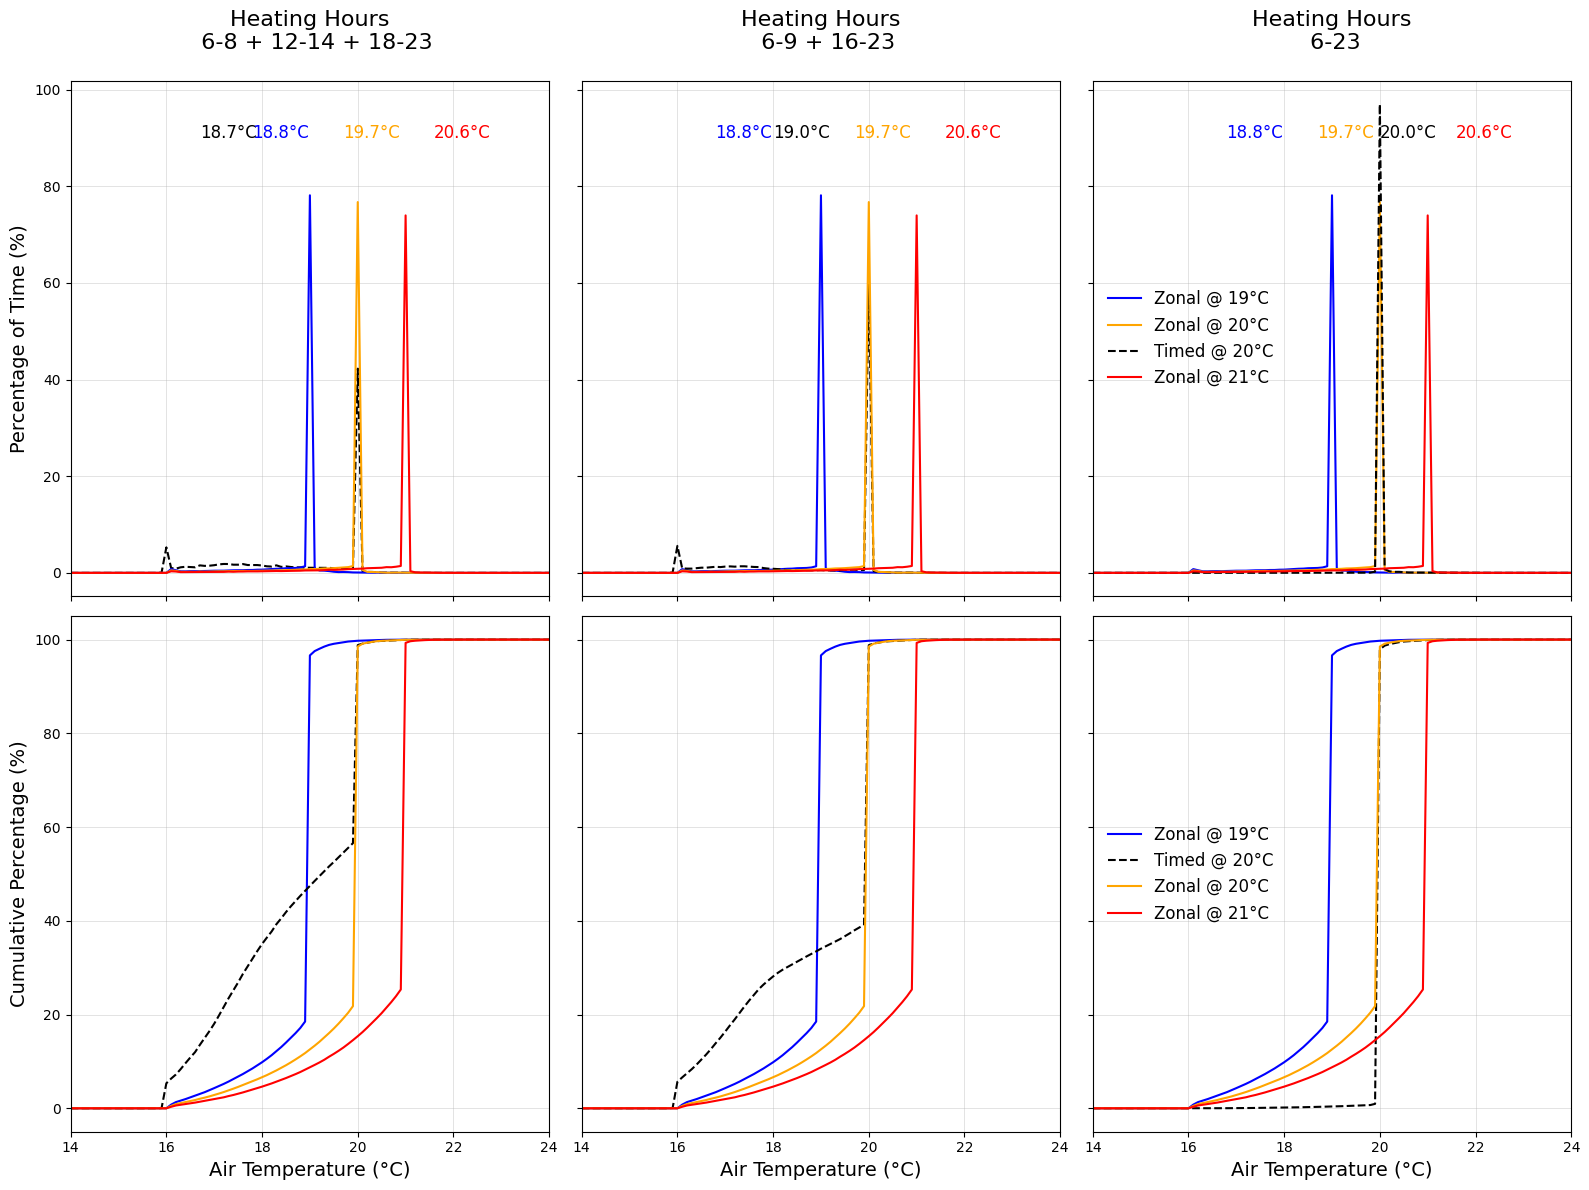

In [40]:
plot_combined_distributions_patterns(patterns, 'air', temp_0=20, room_areas=room_areas, total_floor_area=total_floor_area)

In [41]:

# plot_combined_distributions_patterns(patterns, 'opr', temp_0=20, room_areas=room_areas, total_floor_area=total_floor_area)

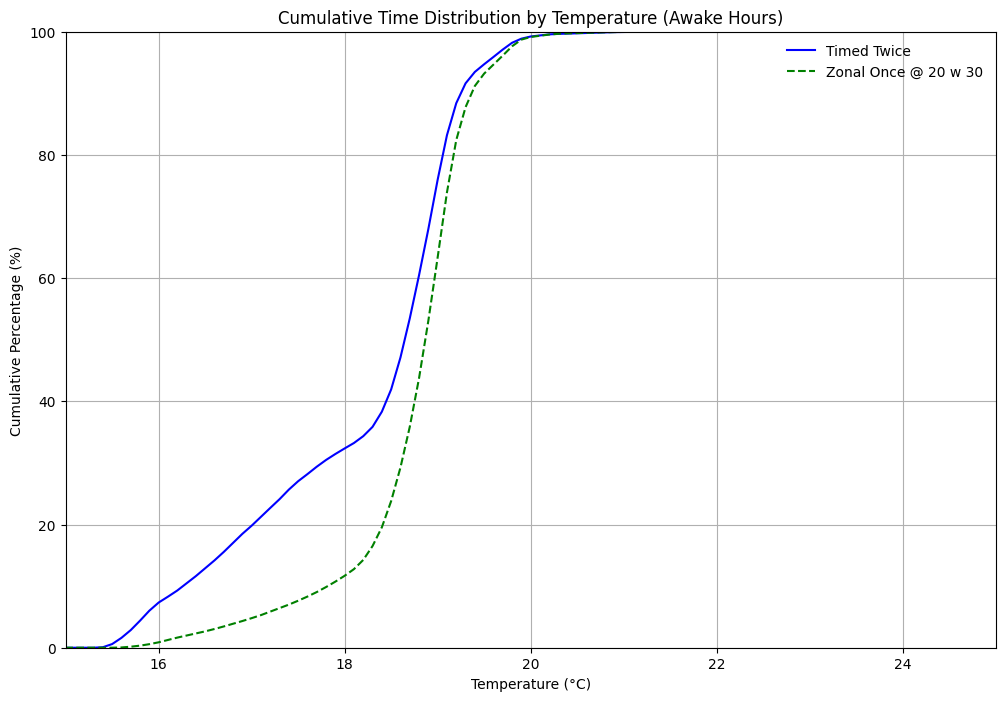

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

room_areas = {
    'kitchen': 11.34,
    'front_room': 14.04,
    'backroom': 11.34,
    'hall_downstairs': 7.02,
    'bedroom_1': 11.51,
    'bedroom_2': 12.39,
    'bedroom_3': 6.86,
    'bathroom': 7.105,
    'hall_upstairs': 5.88,
}
total_floor_area = sum(room_areas.values())

def process_temperature_data(file_path_opr, file_path_ooh, room_areas, total_floor_area):
    temp_df_opr = pd.read_csv(file_path_opr)
    temp_df_ooh = pd.read_csv(file_path_ooh)

    if temp_df_ooh.shape[1] <= 2 or temp_df_ooh.empty:
        temp_df = temp_df_opr.copy()
    else:
        temp_df = temp_df_opr.add(temp_df_ooh, fill_value=0)

    temp_df['Month'] = temp_df_opr['Month']
    temp_df['Zone'] = temp_df_opr['Zone']

    temp_df = temp_df[(temp_df['Month'] < 4) | (temp_df['Month'] > 9)]
    rename_columns = [str(round(i, 1)) for i in np.arange(14, 40, 0.1)]
    temp_df.columns = list(temp_df.columns[:2]) + rename_columns

    plotting_data = {}
    for room, area in room_areas.items():
        data = temp_df[temp_df["Zone"] == room]
        room_data = {col: (data[col].sum() * area) / total_floor_area for col in rename_columns}
        plotting_data[room] = room_data

    total_weighted_data = {col: sum(room_data[col] for room_data in plotting_data.values()) for col in rename_columns}
    weighted_df = pd.DataFrame(list(total_weighted_data.items()), columns=['Temperature', 'Weighted Count'])
    weighted_df['Temperature'] = weighted_df['Temperature'].astype(float)
    weighted_df = weighted_df.sort_values(by='Temperature')

    total_count = weighted_df['Weighted Count'].sum()
    weighted_df['Percentage'] = (weighted_df['Weighted Count'] / total_count) * 100

    weighted_df['Cumulative Percentage'] = weighted_df['Percentage'].cumsum()

    weighted_median_temp = weighted_df[weighted_df['Cumulative Percentage'] >= 50].iloc[0]['Temperature']
    weighted_sum = (weighted_df['Temperature'] * weighted_df['Weighted Count']).sum()
    weighted_mean_temp = weighted_sum / weighted_df['Weighted Count'].sum()

    return weighted_df, weighted_median_temp, weighted_mean_temp



def plot_cumulative_time_distributions(entries, room_areas, total_floor_area, xlim=(15, 25)):
    plt.figure(figsize=(12, 8))
    for entry in entries:
        file_args = {k: entry[k] for k in ['case', 'zone', 'threshold', 'pattern', 'temp', 'temp_type']}
        file_paths_in, file_paths_ooh = get_temp_files(**file_args)
        weighted_df, _, _ = process_temperature_data(file_paths_in[0], file_paths_ooh[0], room_areas, total_floor_area)
        plt.plot(weighted_df['Temperature'], weighted_df['Cumulative Percentage'], linestyle=entry['linestyle'],
                 color=entry['colour'], label=entry['title'])
    plt.xlim(xlim)
    plt.ylim(0, 100)
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Cumulative Percentage (%)')
    plt.title('Cumulative Time Distribution by Temperature (Awake Hours)')
    plt.legend(frameon=False)
    plt.grid(True)
    plt.show()




def get_temp_files(case, zone, threshold, pattern, temp, temp_type, rep='H28',base_dir ='/workspaces/CUBES/results', tag='thermostat_final_v5'):
    file_paths_in = [
        f"{base_dir}/case_{case}_year_2023_rep_{rep}_zone_{zone}_inactive_threshold_{threshold}_pattern_{pattern}_t_comfort_{temp}.0_t_setback_16.0_tags_{tag}/all_months_{temp_type}_all_months.csv",
    ]
    file_paths_ooh = [
        f"{base_dir}/case_{case}_year_2023_rep_{rep}_zone_{zone}_inactive_threshold_{threshold}_pattern_{pattern}_t_comfort_{temp}.0_t_setback_16.0_tags_{tag}/all_months_{temp_type}_ooh_all_months.csv",
    ]
    return file_paths_in, file_paths_ooh

temp_type = 'opr'


entries = [
    {'tag': 'other_occupancies','case': 0, 'zone': 0, 'threshold': 30, 'pattern': 'twice', 'temp': 20, 'temp_type': temp_type, 'title': 'Timed Twice', 'colour': 'blue', 'linestyle': '-'},
    {'tag': 'other_occupancies','case': 0, 'zone': 9, 'threshold': 30, 'pattern': 'once', 'temp': 20, 'temp_type': temp_type, 'title': 'Zonal Once @ 20 w 30', 'colour': 'green', 'linestyle': '--'},
    #{'case': 0, 'zone': 9, 'threshold': 30, 'pattern': 'once', 'temp': 19, 'temp_type': temp_type, 'title': 'Zonal Once @ 19 w 30', 'colour': 'orange', 'linestyle': '--'},
    #{'case': 0, 'zone': 9, 'threshold': 15, 'pattern': 'once', 'temp': 20, 'temp_type': temp_type, 'title': 'Zonal Once @ 20 w 15', 'colour': 'black', 'linestyle': '--'}
]



plot_cumulative_time_distributions(entries, room_areas, total_floor_area, xlim=(15, 25))


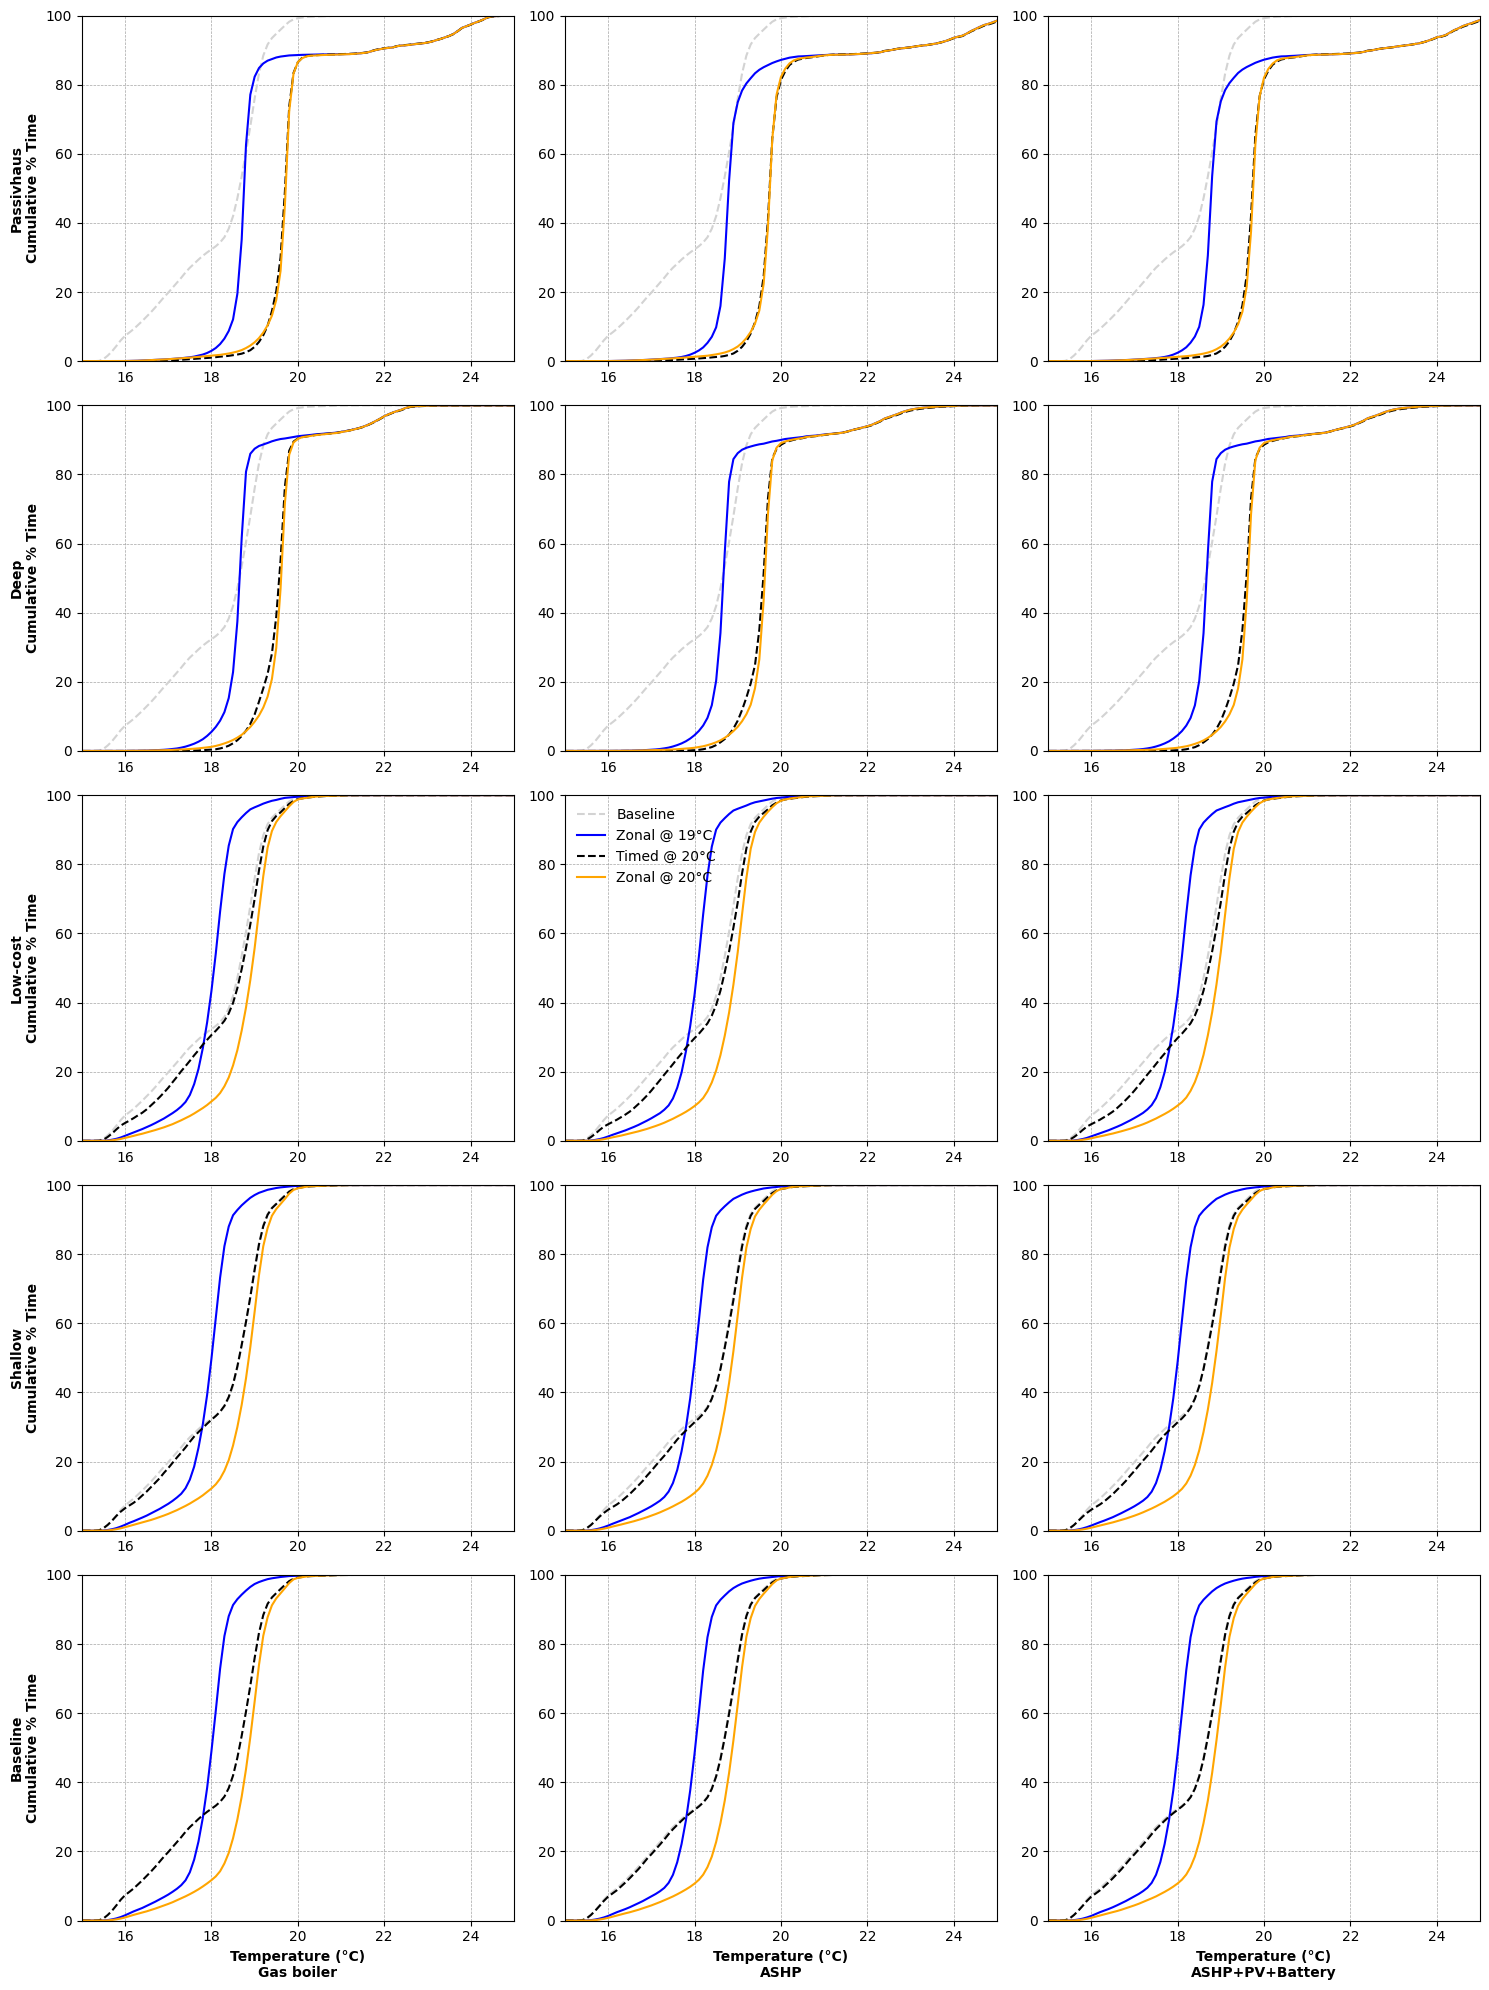

In [43]:
def plot_temperature_figure(entries, room_areas, total_floor_area, xlim=(15, 25)):
    fig, axes = plt.subplots(5, 3, figsize=(15, 20))
    axes = axes.flatten()

    # Define the order of cases for the rows
    case_order = [
        4, 9, 14,
        3, 8, 13,
        2, 7, 12,
        1, 6, 11,
        0, 5, 10
    ]

    global_min_y = 0
    global_max_y = 100

    for i, case_number in enumerate(case_order):
        ax = axes[i]

        if case_number != 0:
            file_paths_in, file_paths_ooh = get_temp_files(
                case=0,
                zone=0,
                threshold=30,
                pattern='twice',
                temp=20,
                temp_type='opr'
            )

            weighted_df, _, weighted_mean_temp = process_temperature_data(file_paths_in[0], file_paths_ooh[0], room_areas, total_floor_area)

            ax.plot(
                weighted_df['Temperature'],
                weighted_df['Cumulative Percentage'],
                linestyle='--',
                color='lightgrey',
                label='Baseline'
            )

        # Plot each entry for the current case
        for entry in entries:

            file_paths_in, file_paths_ooh = get_temp_files(
                case=case_number,
                zone=entry['zone'],
                threshold=entry['threshold'],
                pattern=entry['pattern'],
                temp=entry['temp'],
                temp_type=entry['temp_type']
            )

            weighted_df, _, weighted_mean_temp = process_temperature_data(file_paths_in[0], file_paths_ooh[0], room_areas, total_floor_area)

            ax.plot(
                weighted_df['Temperature'],
                weighted_df['Cumulative Percentage'],
                linestyle=entry['linestyle'],
                color=entry['colour'],
                label=entry['title']
            )

        # Set axis limits and labels
        ax.set_xlim(xlim)
        ax.set_ylim(global_min_y, global_max_y)

        # Add gridlines
        ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

        # Add row labels for retrofit types
        if i in [0, 3, 6, 9, 12]:
            retrofit_type = {
                4: "Baseline",
                3: "Shallow",
                2: "Low-cost",
                1: "Deep",
                0: "Passivhaus"
            }.get(i // 3, "")
            ax.set_ylabel(f'{retrofit_type}\nCumulative % Time', fontsize=10, weight='bold')

        # Add column labels for heating systems
        if i in [12, 13, 14]:
            heating_system = {
                12: "Gas boiler",
                13: "ASHP",
                14: "ASHP+PV+Battery"
            }.get(i, "")
            ax.set_xlabel(f'Temperature (°C)\n{heating_system}', fontsize=10, weight='bold')

        # Add a legend to a specific subplot
        if i == 7:
            ax.legend(frameon=False, loc='upper left')

    plt.tight_layout()
    plt.savefig(f"/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/SI/all_cases_cumulative_temperature_plot.pdf")
    plt.show()


# Example usage
temp_type = 'opr'

entries = [
    {'zone': 9, 'threshold': 30, 'pattern': 'once', 'temp': 19, 'temp_type': temp_type, 'title': 'Zonal @ 19°C', 'colour': 'blue', 'linestyle': '-'},
    {'zone': 0, 'threshold': 30, 'pattern': 'twice', 'temp': 20, 'temp_type': temp_type, 'title': 'Timed @ 20°C ', 'colour': 'black', 'linestyle': '--'},
    {'zone': 9, 'threshold': 30, 'pattern': 'once', 'temp': 20, 'temp_type': temp_type, 'title': 'Zonal @ 20°C', 'colour': 'orange', 'linestyle': '-'},
    # {'zone': 9, 'threshold': 30, 'pattern': 'once', 'temp': 21, 'temp_type': temp_type, 'title': 'Zonal @ 21°C', 'colour': 'red', 'linestyle': '-'},
]

plot_temperature_figure(entries, room_areas, total_floor_area)


Cumulative emissions for 'Timed':
  2023-04-01: 0.92 metric tonnes
  2023-05-01: 1.02 metric tonnes
  2023-10-01: 1.03 metric tonnes
  2023-12-31: 1.78 metric tonnes


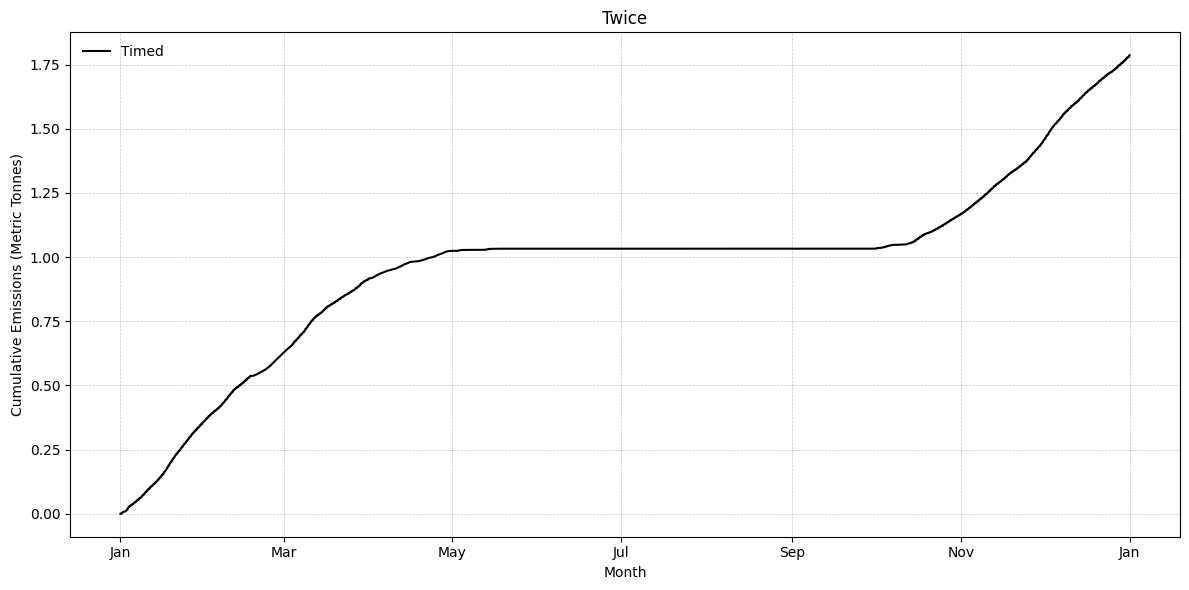

In [44]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob

base_dir = '/workspaces/CUBES/exp/jack/paper/thermostat_experiment/SI/correct_holidays'

def load_json_file(file_type, case_number, zone_number, pattern, comforttemp):
    """Load the JSON file based on the given parameters."""
    json_file_pattern = f'{base_dir}/case_{case_number}_year_2023_rep_H28_zone_{zone_number}_*_pattern_{pattern}_*_comfort_{comforttemp}.0_*/{file_type}.json'
    matching_files = glob.glob(json_file_pattern)
    if not matching_files:
        raise FileNotFoundError(f"No files found matching: {json_file_pattern}")
    with open(matching_files[0], 'r') as file:
        return json.load(file)


def load_json_file(file_type, case_number, zone_number, pattern, comforttemp):
    """Load the JSON file based on the given parameters."""
    json_file_pattern = f'{base_dir}/case_{case_number}_year_2023_rep_H28_zone_{zone_number}_*_pattern_{pattern}_*_comfort_{comforttemp}.0_*/{file_type}.json'
    matching_files = glob.glob(json_file_pattern)
    if not matching_files:
        raise FileNotFoundError(f"No files found matching: {json_file_pattern}")
    with open(matching_files[0], 'r') as file:
        return json.load(file)

def create_dataframe(data, time_index):
    """Convert hourly JSON data to a pandas DataFrame with a DateTime index."""
    df = pd.DataFrame(data['hourly_data']).iloc[:8760]  # Ensure 8760 rows
    df.index = time_index
    return df

def compute_cumulative_emissions(df):
    """Calculate cumulative emissions in metric tonnes."""
    df['cumulative_emissions'] = df['emissions'].cumsum() / 1000
    return df

def plot_cumulative_emissions(ax, df, label, color, linestyle):
    """Plot cumulative emissions on the given axis."""
    ax.plot(df.index, df['cumulative_emissions'], color=color, linestyle=linestyle, label=label)

def annotate_emissions(ax, df, dates, label):
    """Annotate the cumulative emissions at specified dates on the plot."""
    for date in dates:
        if date in df.index:
            value = df.loc[date, 'cumulative_emissions']
            print(value)
            # ax.annotate(
            #     f'{value:.2f}',  # Format to 2 decimal places
            #     xy=(date, value),
            #     xytext=(date, value + 0.5),  # Offset text slightly above the point
            #     textcoords="offset points",
            #     ha='center',
            #     fontsize=8,
            #     color='black',
            #     arrowprops=dict(arrowstyle='->', lw=0.5, color='grey')
            # )


import numpy as np

def compute_and_print_ratios(list1, list2, dates, label1, label2):
    """Compute and print the element-wise ratio of two lists."""
    list1 = np.array(list1)
    list2 = np.array(list2)
    ratio = list2 / list1
    print(f"Ratios ({label2}/{label1}):")
    for date, r in zip(dates, ratio):
        print(f"  {date.strftime('%Y-%m-%d')}: {r:.2f}")

def print_emissions_at_dates(df, dates, label):
    """Print cumulative emissions at specific dates for a dataset."""
    print(f"Cumulative emissions for '{label}':")
    emissions = []
    for date in dates:
        if date in df.index:
            value = df.loc[date, 'cumulative_emissions']
            emissions.append(value)
            print(f"  {date.strftime('%Y-%m-%d')}: {value:.2f} metric tonnes")
    return emissions

def main_subplot(zone_data_patterns, patterns):
    """Main function to create subplots for each pattern."""
    time_index = pd.date_range(start="2023-01-01", periods=8760, freq="h")
    annotation_dates = pd.to_datetime(["2023-04-01", "2023-05-01", "2023-10-01", "2023-12-31"])

    # Create subplots with 1 row and len(patterns) columns
    fig, axs = plt.subplots(1, len(patterns), figsize=(12, 6), sharey=True)

    # Ensure axs is a list, even if there is only one subplot
    if len(patterns) == 1:
        axs = [axs]

    for col_idx, (zone_data, pattern_name) in enumerate(zip(zone_data_patterns, patterns)):
        ax = axs[col_idx]
        dataframes = []
        emissions_data = []  # Collect emissions for ratio calculation
        labels = []

        for zone_number, zone_pattern, comforttemp, label, color, linestyle in zone_data:
            data = load_json_file("hourly_metrics", 0, zone_number, zone_pattern, comforttemp)
            df = create_dataframe(data, time_index)
            df = compute_cumulative_emissions(df)
            dataframes.append((df, label, color, linestyle))

            # Print and collect emissions data
            emissions = print_emissions_at_dates(df, annotation_dates, label)
            emissions_data.append(emissions)
            labels.append(label)

        # Plot each dataset in the current column
        for df, label, color, linestyle in dataframes:
            plot_cumulative_emissions(ax, df, label, color, linestyle)

        # Compute and print ratios if there are at least two datasets
        if len(emissions_data) >= 2:
            compute_and_print_ratios(emissions_data[0], emissions_data[1], annotation_dates, labels[0], labels[1])

        # Configure x-axis
        ax.xaxis.set_major_locator(mdates.MonthLocator([1, 3, 5, 7, 9, 11]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.set_xlabel('Month')
        if col_idx == 0:
            ax.set_ylabel('Cumulative Emissions (Metric Tonnes)')
        ax.set_title(pattern_name.capitalize())
        ax.legend(frameon=False)
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()




# # Define data for each pattern
# zone_data_thrice = [
#     (0, 'thrice', 20, 'Retrofit + Timed', 'black', '-'),
#     (9, 'thrice', 20, 'Retrofit + Zonal', 'purple', '--'),
#     (9, 'once', 19, 'Retrofit + Zonal', 'blue', '--')
# ]

zone_data_twice = [
    (0, 'twice', 20, 'Timed', 'black', '-'),
    # (9, 'once', 20, 'Zonal', 'purple', '-'),
    # (9, 'once', 19, 'Retrofit + Zonal', 'blue', '--')
]

# zone_data_once = [
#     (0, 'once', 20, 'Retrofit + Timed', 'black', '-'),
#     (9, 'once', 20, 'Retrofit + Zonal', 'blue', '--')
# ]

# Combine data for all patterns
# zone_data_patterns = [zone_data_thrice, zone_data_twice, zone_data_once]
zone_data_patterns = [zone_data_twice]
patterns = [ 'twice']

# Run the main plotting function
main_subplot(zone_data_patterns, patterns)



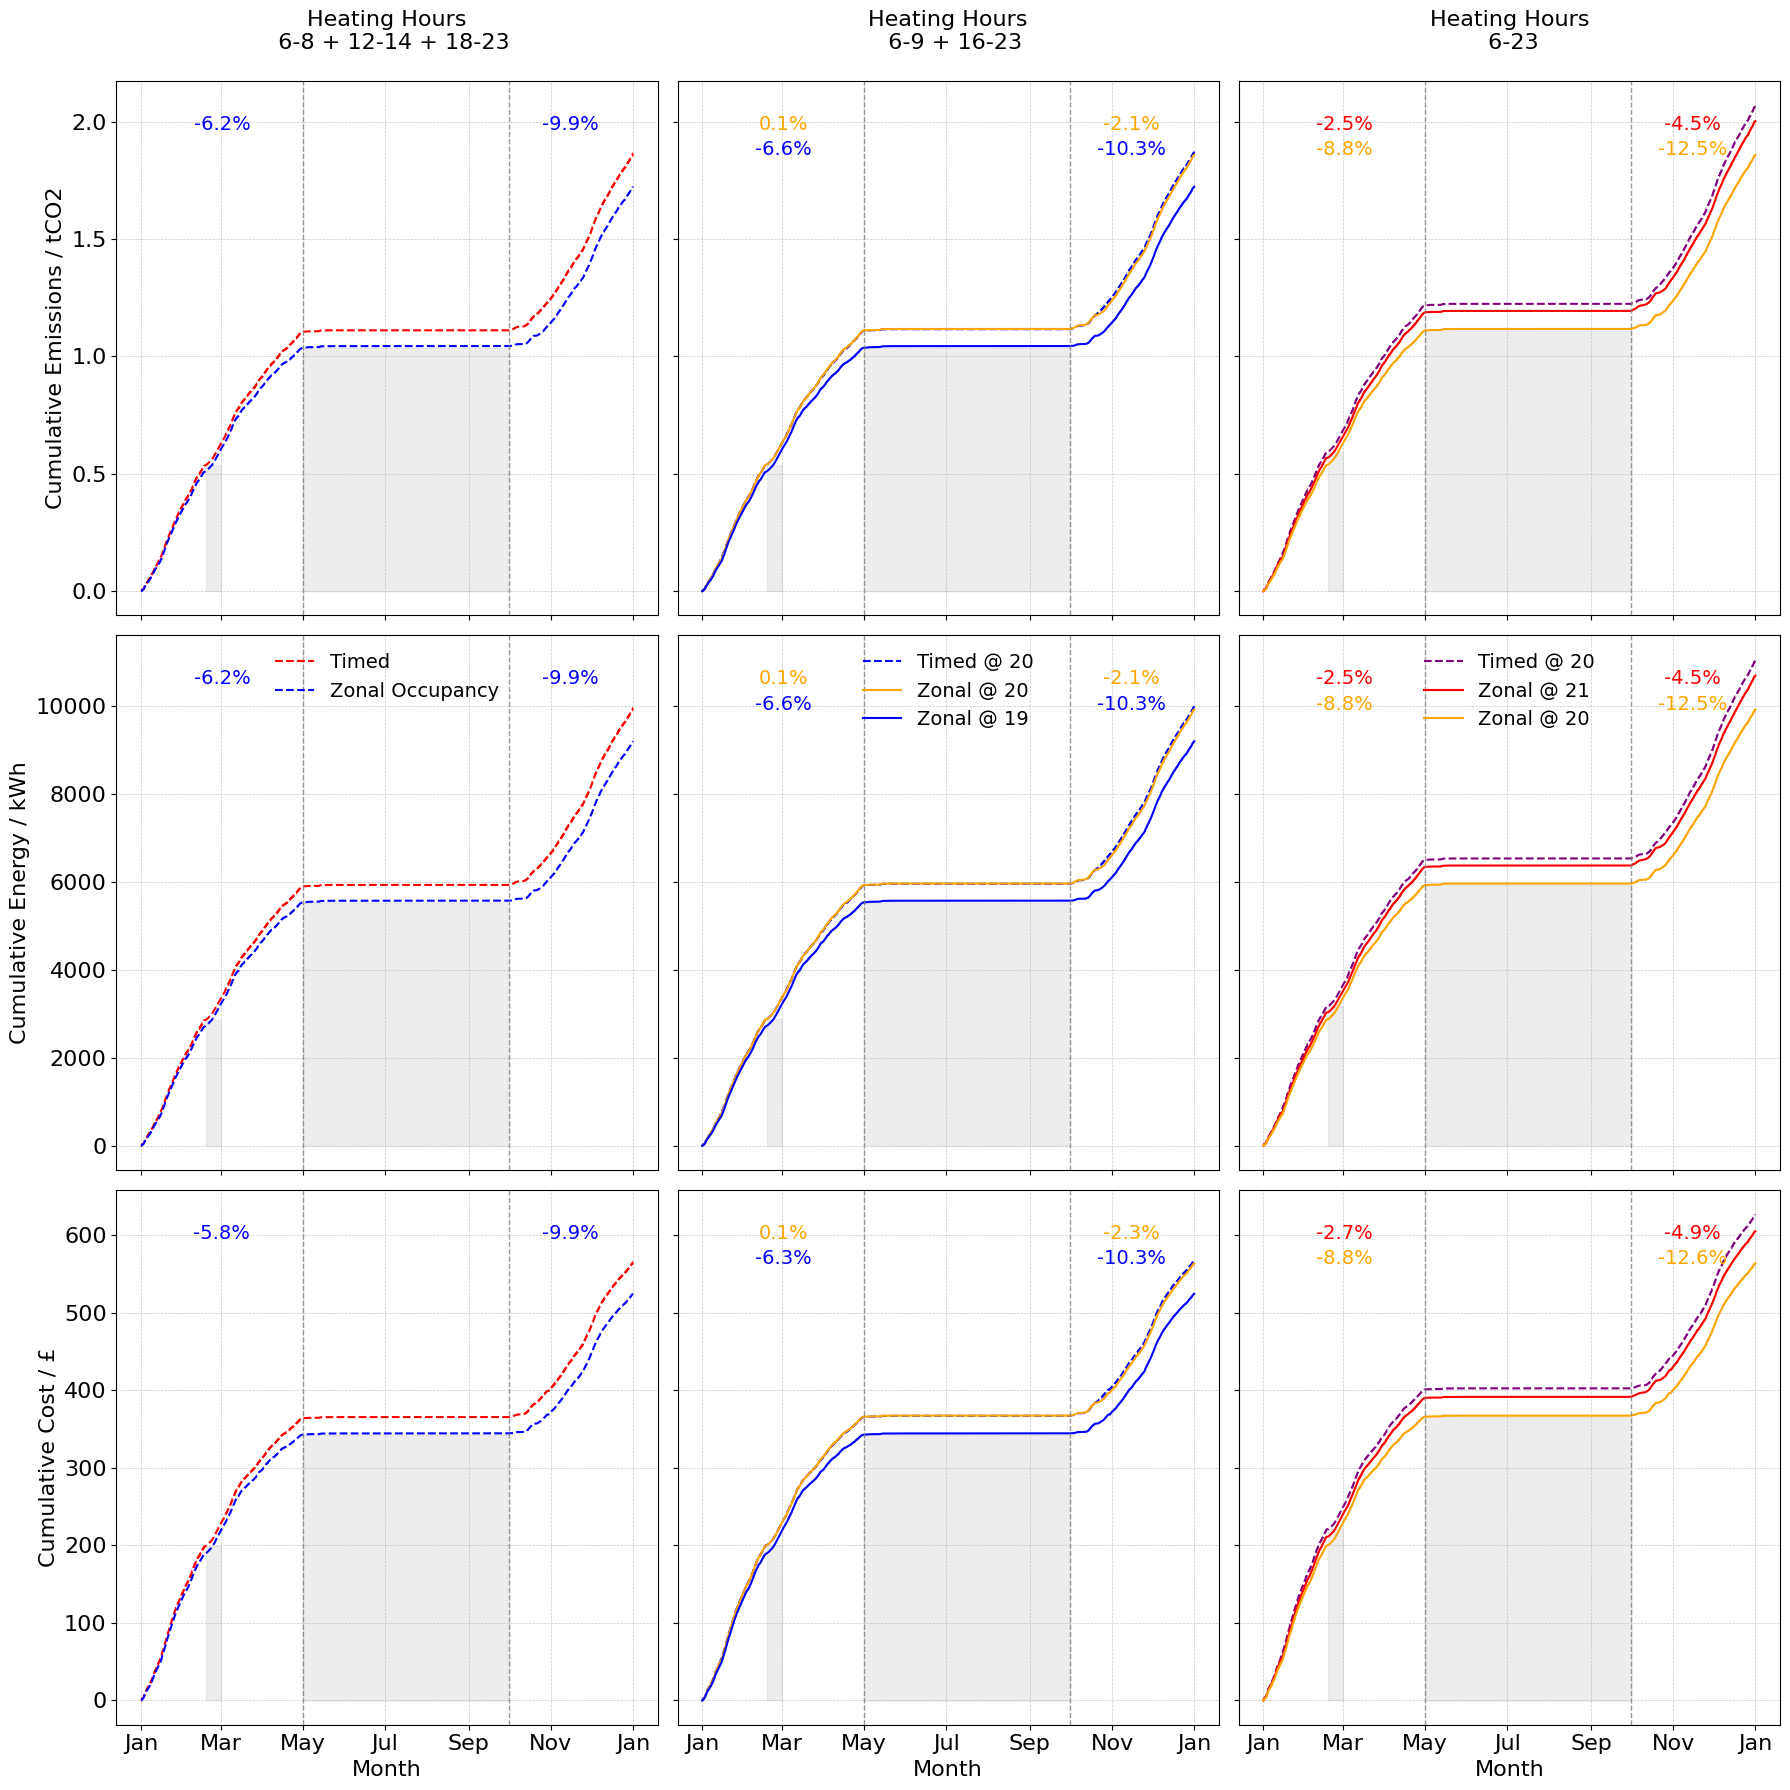

In [2]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob

# Directory path where the cases are stored
base_dir = '/workspaces/CUBES/results'

def load_json_file(file_type, case_number, zone_number, pattern, comforttemp):
    """Load the JSON file based on the given parameters."""
    json_file_pattern = f'{base_dir}/case_{case_number}_year_2023_rep_H28_zone_{zone_number}_*_pattern_{pattern}_*_comfort_{comforttemp}.0_*/{file_type}.json'
    matching_files = glob.glob(json_file_pattern)
    if not matching_files:
        raise FileNotFoundError(f"No files found matching: {json_file_pattern}")
    with open(matching_files[0], 'r') as file:
        return json.load(file)

def create_dataframe(data, time_index):
    """Convert hourly JSON data to a pandas DataFrame with a DateTime index."""
    df = pd.DataFrame(data['hourly_data']).iloc[:8760]  # Ensure 8760 rows
    df.index = time_index
    return df

def calculate_period_emissions(df, start_date, end_date):
    """Calculate total emissions for a specified period."""
    period_df = df.loc[start_date:end_date]
    return period_df['emissions'].sum() / 1000  # Convert to metric tonnes

def compute_cumulative_metric(df, metric_name):
    """Calculate cumulative values for the specified metric."""
    df[f'cumulative_{metric_name}'] = df[metric_name].cumsum()
    return df

def plot_cumulative_metric(ax, df, metric_name, label, color, linestyle):
    """Plot cumulative metric on the given axis."""
    ax.plot(df.index, df[f'cumulative_{metric_name}'], color=color, linestyle=linestyle, label=label)

def annotate_reduction(ax, df1, df2, start_date, end_date, label1, label2, color, metric_name, global_ylim, used_y_positions):
    """Calculate and annotate reduction percentage for a given metric on the plot."""
    metric_1 =  df1.loc[start_date:end_date][metric_name].sum()
    metric_2 =  df2.loc[start_date:end_date][metric_name].sum()

    reduction = ((metric_1 - metric_2) / metric_1) * 100
    midpoint = pd.to_datetime(start_date) + (pd.to_datetime(end_date) - pd.to_datetime(start_date)) / 2

    period_key = f"{start_date}_{end_date}"
    if period_key not in used_y_positions:
        used_y_positions[period_key] = set()

    max_ylim = global_ylim[1]  # Use the global max y-limit for the row
    y_position = max_ylim * 0.85  # Start at 80% of the global max ylim
    while y_position in used_y_positions[period_key]:  # Avoid overlap by adjusting position
        y_position -= max_ylim * 0.05  # Adjust y-position relative to max ylim

    used_y_positions[period_key].add(y_position)

    ax.annotate(
        f"{-1*reduction:.1f}%",
        xy=(midpoint, y_position),
        xytext=(0, 20),
        textcoords="offset points",
        ha='center',
        fontsize=14,
        color=color,
    )

def normalise_metric(df, metric_name):
    """Normalise the given metric in the DataFrame and return the normalised DataFrame and unit."""
    if "cost" in metric_name:
        normalise = 100  # Convert pence to pounds
        name = 'Cost'
        unit = '£'
    elif "emission" in metric_name:
        normalise = 1000  # Convert grams to tonnes
        name = 'Emissions'
        unit = 'tCO2'
    else:
        normalise = 1  # No normalisation needed
        name = 'Energy'
        unit = 'kWh'

    df[metric_name] = df[metric_name] / normalise  # Normalise the specified metric column
    return df, unit, name



def main_subplot_dynamic_multimetric(zone_data_patterns, patterns, metrics):
    time_index = pd.date_range(start="2023-01-01", periods=8760, freq="h")
    fig, axs = plt.subplots(len(metrics), len(patterns), figsize=(18, 18), sharex=True, sharey=False)

    for row_idx, metric_name in enumerate(metrics):
        global_ylim = [float('inf'), float('-inf')]

        for col_idx, (zone_data, pattern_name) in enumerate(zip(zone_data_patterns, patterns)):
            ax = axs[row_idx, col_idx]
            for zone_number, zone_pattern, comforttemp, label, color, linestyle in zone_data:
                data = load_json_file("hourly_metrics", 0, zone_number, zone_pattern, comforttemp)
                df = create_dataframe(data, time_index)

                df, unit, name = normalise_metric(df, metric_name)
                df = compute_cumulative_metric(df, metric_name)

                plot_cumulative_metric(ax, df, metric_name, label, color, linestyle)

            current_ylim = ax.get_ylim()
            global_ylim[0] = min(global_ylim[0], current_ylim[0])
            global_ylim[1] = max(global_ylim[1], current_ylim[1])

        for col_idx, (zone_data, pattern_name) in enumerate(zip(zone_data_patterns, patterns)):
            ax = axs[row_idx, col_idx]
            ax.set_ylim(global_ylim)

            dataframes = []
            used_y_positions = {}

            for zone_number, zone_pattern, comforttemp, label, color, linestyle in zone_data:
                data = load_json_file("hourly_metrics", 0, zone_number, zone_pattern, comforttemp)
                df = create_dataframe(data, time_index)

                df, unit, name = normalise_metric(df, metric_name)
                df = compute_cumulative_metric(df, metric_name)

                dataframes.append((df, label, color, linestyle))

            timed_df = None
            for df, label, color, linestyle in dataframes:
                if "Timed" in label:
                    timed_df = df
                    break

            if timed_df is not None:
                for df, label, color, linestyle in dataframes:
                    if "Timed" not in label:
                        annotate_reduction(ax, timed_df, df, "2023-01-01", "2023-05-01", "Timed", label, color, metric_name, global_ylim, used_y_positions)
                        annotate_reduction(ax, timed_df, df, "2023-10-01", "2023-12-31", "Timed", label, color, metric_name, global_ylim, used_y_positions)

            # Shade grey area only up to the y-values of the curve for May to October
            if dataframes:  # Ensure dataframes is not empty
                last_df, label, color, linestyle = dataframes[-1]  # Access only the first df
                first_df, label, color, linestyle = dataframes[0]  # Access only the first df

                # May to October
                may_to_october = (last_df.index >= "2023-05-01") & (last_df.index <= "2023-10-01")
                may_to_october_value = (last_df.index >= "2023-01-01") & (last_df.index <= "2023-05-01")
                ax.fill_between(
                    last_df.index[may_to_october],
                    last_df[metric_name][may_to_october_value].sum(),  # Upper y-values: match the curve
                    0,  # Lower y-values: start from the global minimum
                    color="lightgray",
                    alpha=0.4,
                )

                # Shade grey area only up to the y-values of the curve for February to March
                feb_to_mar = (first_df.index >= "2023-02-18") & (first_df.index <= "2023-03-01")
                feb_to_mar_value = (first_df.index >= "2023-01-01") & (first_df.index <= "2023-02-18")
                ax.fill_between(
                    first_df.index[feb_to_mar],
                    first_df[metric_name][feb_to_mar_value].sum(),  # Upper y-values: match the curve
                    0,  # Lower y-values: start from the global minimum
                    color="lightgray",
                    alpha=0.4,
                )


            ax.axvline(pd.Timestamp("2023-05-01"), color="gray", linestyle="--", linewidth=1, alpha=0.8)
            ax.axvline(pd.Timestamp("2023-10-01"), color="gray", linestyle="--", linewidth=1, alpha=0.8)

            ax.xaxis.set_major_locator(mdates.MonthLocator([1, 3, 5, 7, 9, 11]))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
            ax.tick_params(axis='x', labelsize=16)  # Set font size for x-axis tick labels
            ax.tick_params(axis='y', labelsize=16)  # Set font size for x-axis tick labels


            if pattern_name == 'once':
                pattern_title = "Heating Hours\n 6-23\n"
            elif pattern_name == 'twice':
                pattern_title = "Heating Hours\n  6-9 + 16-23\n"
            elif pattern_name == 'thrice':
                pattern_title = "Heating Hours\n  6-8 + 12-14 + 18-23\n"

            if row_idx == len(metrics) - 1:
                ax.set_xlabel('Month', fontsize=16)
            if col_idx == 0:
                ax.set_ylabel(f'Cumulative {name} / {unit}', fontsize=16)
            else:
                ax.set_yticklabels([])  # Hide y-axis tick labels, but keep the ticks for grid lines


            if row_idx == 0:
                ax.set_title(pattern_title, fontsize=16)
            if row_idx == 1:
                ax.legend(frameon=False, loc='upper center', fontsize=14)
            ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    plt.savefig(f"/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/SI/cumulative_metrics_plot_abstract.pdf")

    plt.tight_layout()
    plt.show()


# Define data for each pattern
zone_data_thrice = [
    (0, 'thrice', 20, 'Timed', 'red', '--'),
    # (9, 'once', 20, 'Zonal @ 20', 'orange', '-'),
    (9, 'once', 19, 'Zonal Occupancy', 'blue', '--')
]

zone_data_twice = [
    (0, 'twice', 20, 'Timed @ 20', 'blue', '--'),
    (9, 'once', 20, 'Zonal @ 20', 'orange', '-'),
    (9, 'once', 19, 'Zonal @ 19', 'blue', '-')
]

zone_data_once = [
    (0, 'once', 20, 'Timed @ 20', 'purple', '--'),
    (9, 'once', 21, 'Zonal @ 21', 'red', '-'),
    (9, 'once', 20, 'Zonal @ 20', 'orange', '-'),
]

# Combine data for all patterns
zone_data_patterns = [zone_data_thrice, zone_data_twice, zone_data_once]
patterns = ['thrice', 'twice', 'once']
metric_name = 'gas_energy'  # Change to 'energy' or any other metric as needed


# Define metrics and run the function
metrics = ['emissions', 'gas_energy', 'cost']
main_subplot_dynamic_multimetric(zone_data_patterns, patterns, metrics)

# main_subplot_dynamic(zone_data_patterns, patterns, metric_name)


In [46]:
def plot_metric_figure(metric):
    if "cost" in metric:
        normalise = 100
        unit = '£'
    elif "emission" in metric:
        normalise = 1000
        unit = 'tCO2'
    else:
        normalise = 1
        unit = 'kWh'

    fig, axes = plt.subplots(5, 3, figsize=(12, 20), sharey=True, sharex=True)
    axes = axes.flatten()

    case_order = [4, 9, 14, 3, 8, 13, 2, 7, 12, 1, 6, 11, 0, 5, 10]
    time_index = pd.date_range(start="2023-01-01", periods=8760, freq="h")

    data_case_0 = load_json_file("hourly_metrics", 0, zone_number=0, pattern='twice', comforttemp=20)
    df_case_0 = pd.DataFrame(data_case_0['hourly_data']).iloc[:8760]
    df_case_0.index = time_index

    if metric == "energy":
        df_case_0[f'cumulative_{metric}'] = (df_case_0['gas_energy'] + df_case_0['net_electricity_energy']).cumsum() / normalise
    else:
        df_case_0[f'cumulative_{metric}'] = df_case_0[f'{metric}'].cumsum() / normalise

    global_max_y, global_min_y = float('-inf'), float('inf')

    for i, case_number in enumerate(case_order):
        data_zone_0 = load_json_file("hourly_metrics", case_number, zone_number=0, pattern='twice', comforttemp=20)
        data_zone_9 = load_json_file("hourly_metrics", case_number, zone_number=9, pattern='once', comforttemp=19)
        data_zone_9_20 = load_json_file("hourly_metrics", case_number, zone_number=9, pattern='once', comforttemp=20)
        data_zone_9_21 = load_json_file("hourly_metrics", case_number, zone_number=9, pattern='once', comforttemp=21)

        df_zone_0 = pd.DataFrame(data_zone_0['hourly_data']).iloc[:8760]
        df_zone_9 = pd.DataFrame(data_zone_9['hourly_data']).iloc[:8760]
        df_zone_9_20 = pd.DataFrame(data_zone_9_20['hourly_data']).iloc[:8760]
        df_zone_9_21 = pd.DataFrame(data_zone_9_21['hourly_data']).iloc[:8760]

        df_zone_0.index = time_index
        df_zone_9.index = time_index
        df_zone_9_20.index = time_index
        df_zone_9_21.index = time_index

        if metric == "energy":
            df_zone_0[f'cumulative_{metric}'] = (df_zone_0['gas_energy'] + df_zone_0['net_electricity_energy']).cumsum() / normalise
            df_zone_9[f'cumulative_{metric}'] = (df_zone_9['gas_energy'] + df_zone_9['net_electricity_energy']).cumsum() / normalise
            df_zone_9_20[f'cumulative_{metric}'] = (df_zone_9_20['gas_energy'] + df_zone_9_20['net_electricity_energy']).cumsum() / normalise
            df_zone_9_21[f'cumulative_{metric}'] = (df_zone_9_21['gas_energy'] + df_zone_9_21['net_electricity_energy']).cumsum() / normalise
        else:
            df_zone_0[f'cumulative_{metric}'] = df_zone_0[f'{metric}'].cumsum() / normalise
            df_zone_9[f'cumulative_{metric}'] = df_zone_9[f'{metric}'].cumsum() / normalise
            df_zone_9_20[f'cumulative_{metric}'] = df_zone_9_20[f'{metric}'].cumsum() / normalise
            df_zone_9_21[f'cumulative_{metric}'] = df_zone_9_21[f'{metric}'].cumsum() / normalise

        global_max_y = max(global_max_y, df_zone_0[f'cumulative_{metric}'].max(), df_zone_9[f'cumulative_{metric}'].max(),
                           df_zone_9_20[f'cumulative_{metric}'].max(), df_zone_9_21[f'cumulative_{metric}'].max())
        global_min_y = min(global_min_y, df_zone_0[f'cumulative_{metric}'].min(), df_zone_9[f'cumulative_{metric}'].min(),
                           df_zone_9_20[f'cumulative_{metric}'].min(), df_zone_9_21[f'cumulative_{metric}'].min())

        ax = axes[i]

        ax.plot(df_case_0.index, df_case_0[f'cumulative_{metric}'], color='lightgray', linestyle='--', label='Baseline + Timed (20°C)')
        ax.plot(df_zone_0.index, df_zone_0[f'cumulative_{metric}'], color='black', label='Retrofit + Timed (20°C)', linestyle='-')
        ax.plot(df_zone_9.index, df_zone_9[f'cumulative_{metric}'], color='blue', linestyle='--', label='Retrofit + Zonal (19°C)')
        ax.plot(df_zone_9_20.index, df_zone_9_20[f'cumulative_{metric}'], color='orange', linestyle='--', label='Retrofit + Zonal (20°C)')
        # ax.plot(df_zone_9_21.index, df_zone_9_21[f'cumulative_{metric}'], color='red', linestyle='--', label='Retrofit + Zonal (21°C)')

        ax.xaxis.set_major_locator(mdates.MonthLocator([1, 3, 5, 7, 9, 11]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

        if i in [0, 3, 6, 9, 12]:
            case_desc = ["Passivhaus", "Deep", "Low-cost", "Shallow", "Baseline"][i // 3]
            ax.set_ylabel(f'{case_desc}\nCumulative {metric.capitalize()} / {unit}', fontsize=12, weight='bold')

        if i in [12, 13, 14]:
            case_desc = ["Gas boiler", "ASHP", "ASHP+PV+Battery"][i - 12]
            ax.set_xlabel(f'Month\n{case_desc}', fontsize=12, weight='bold')

        if i == 8:
            ax.legend(loc='upper left', frameon=False)

        ax.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

    for ax in axes:
        ax.set_ylim(global_min_y, global_max_y)

    plt.tight_layout()
    plt.savefig(f"/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/SI/all_cases_cumulative_{metric}_plot.pdf")
    plt.show()


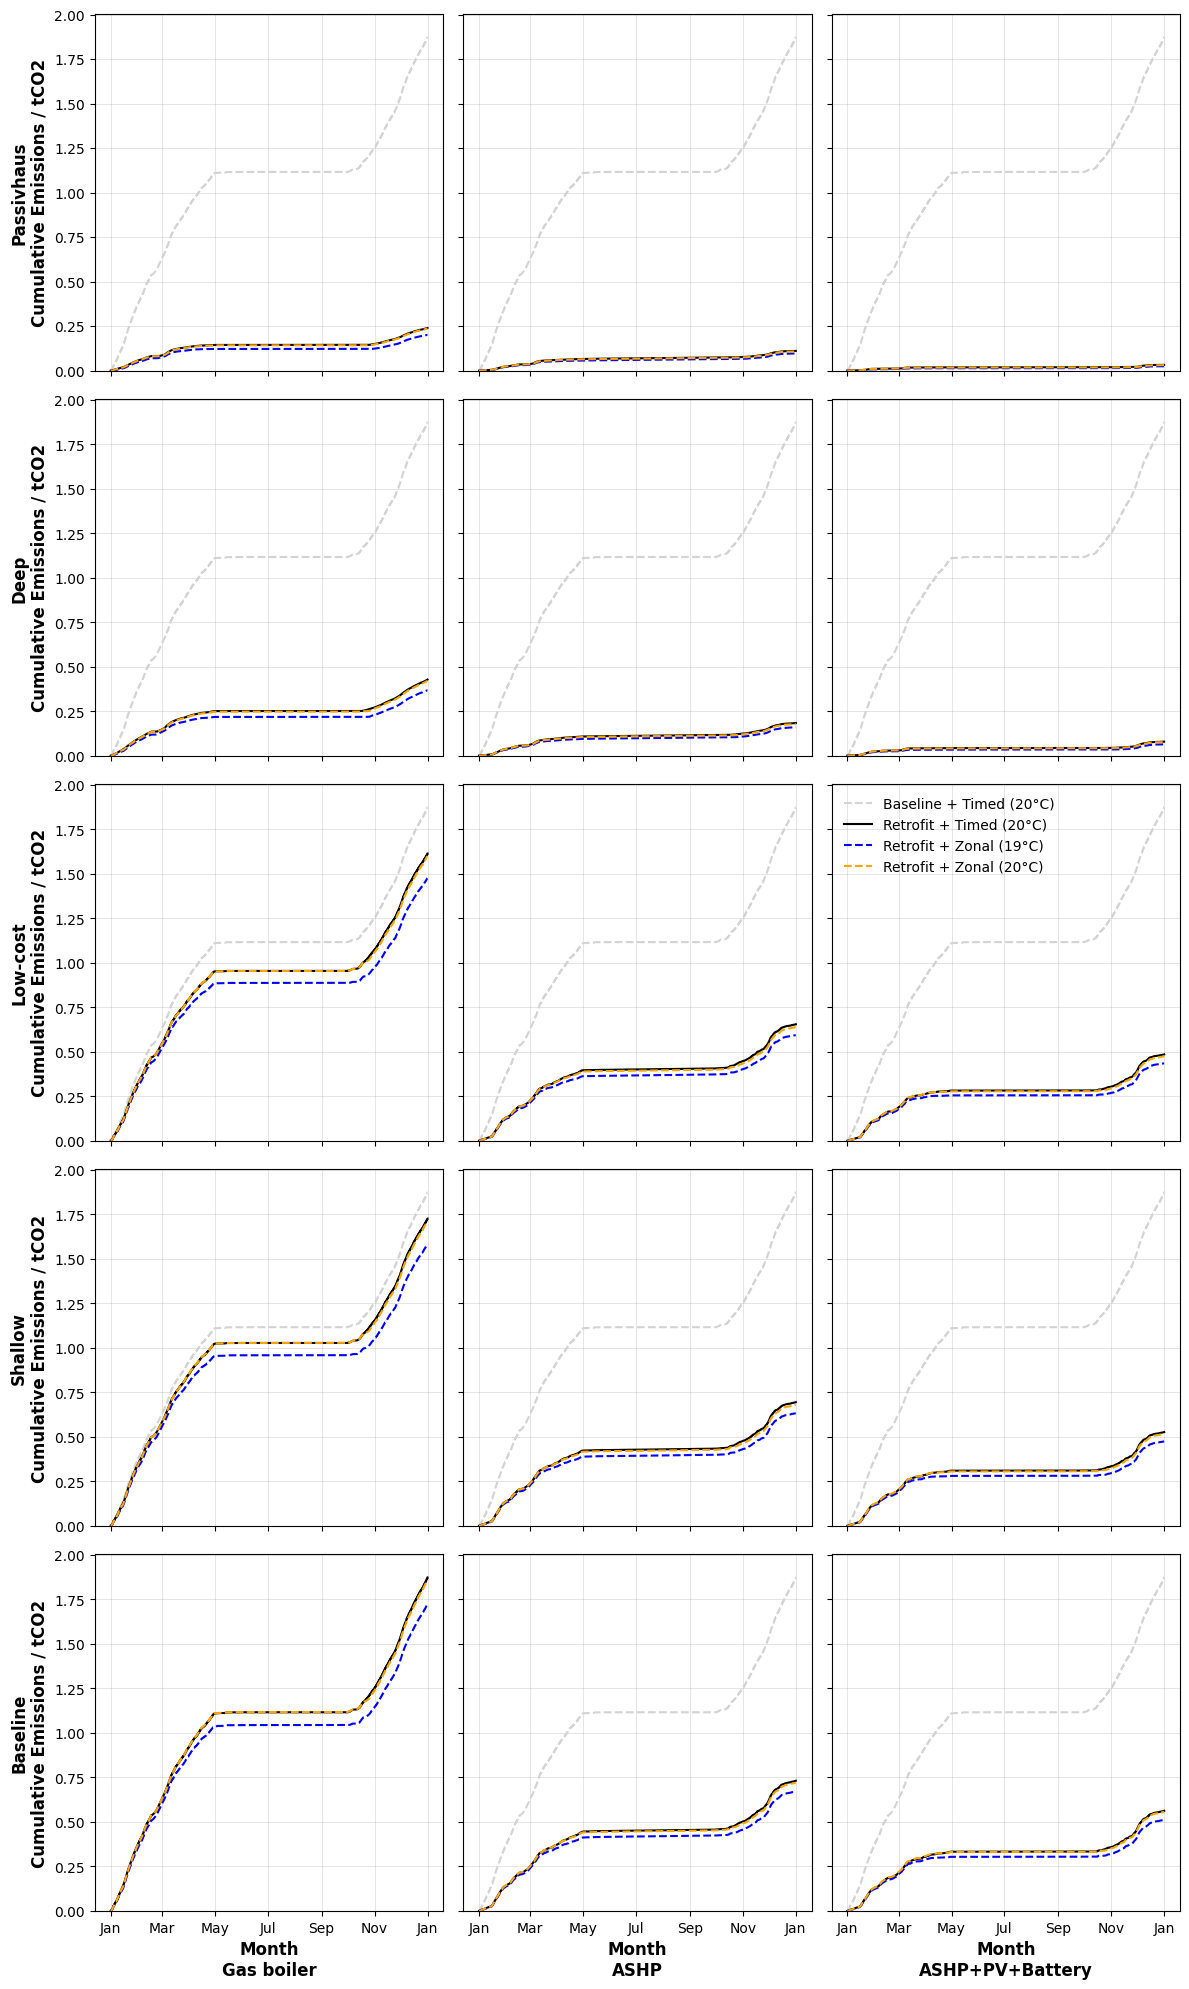

In [47]:
plot_metric_figure('emissions')

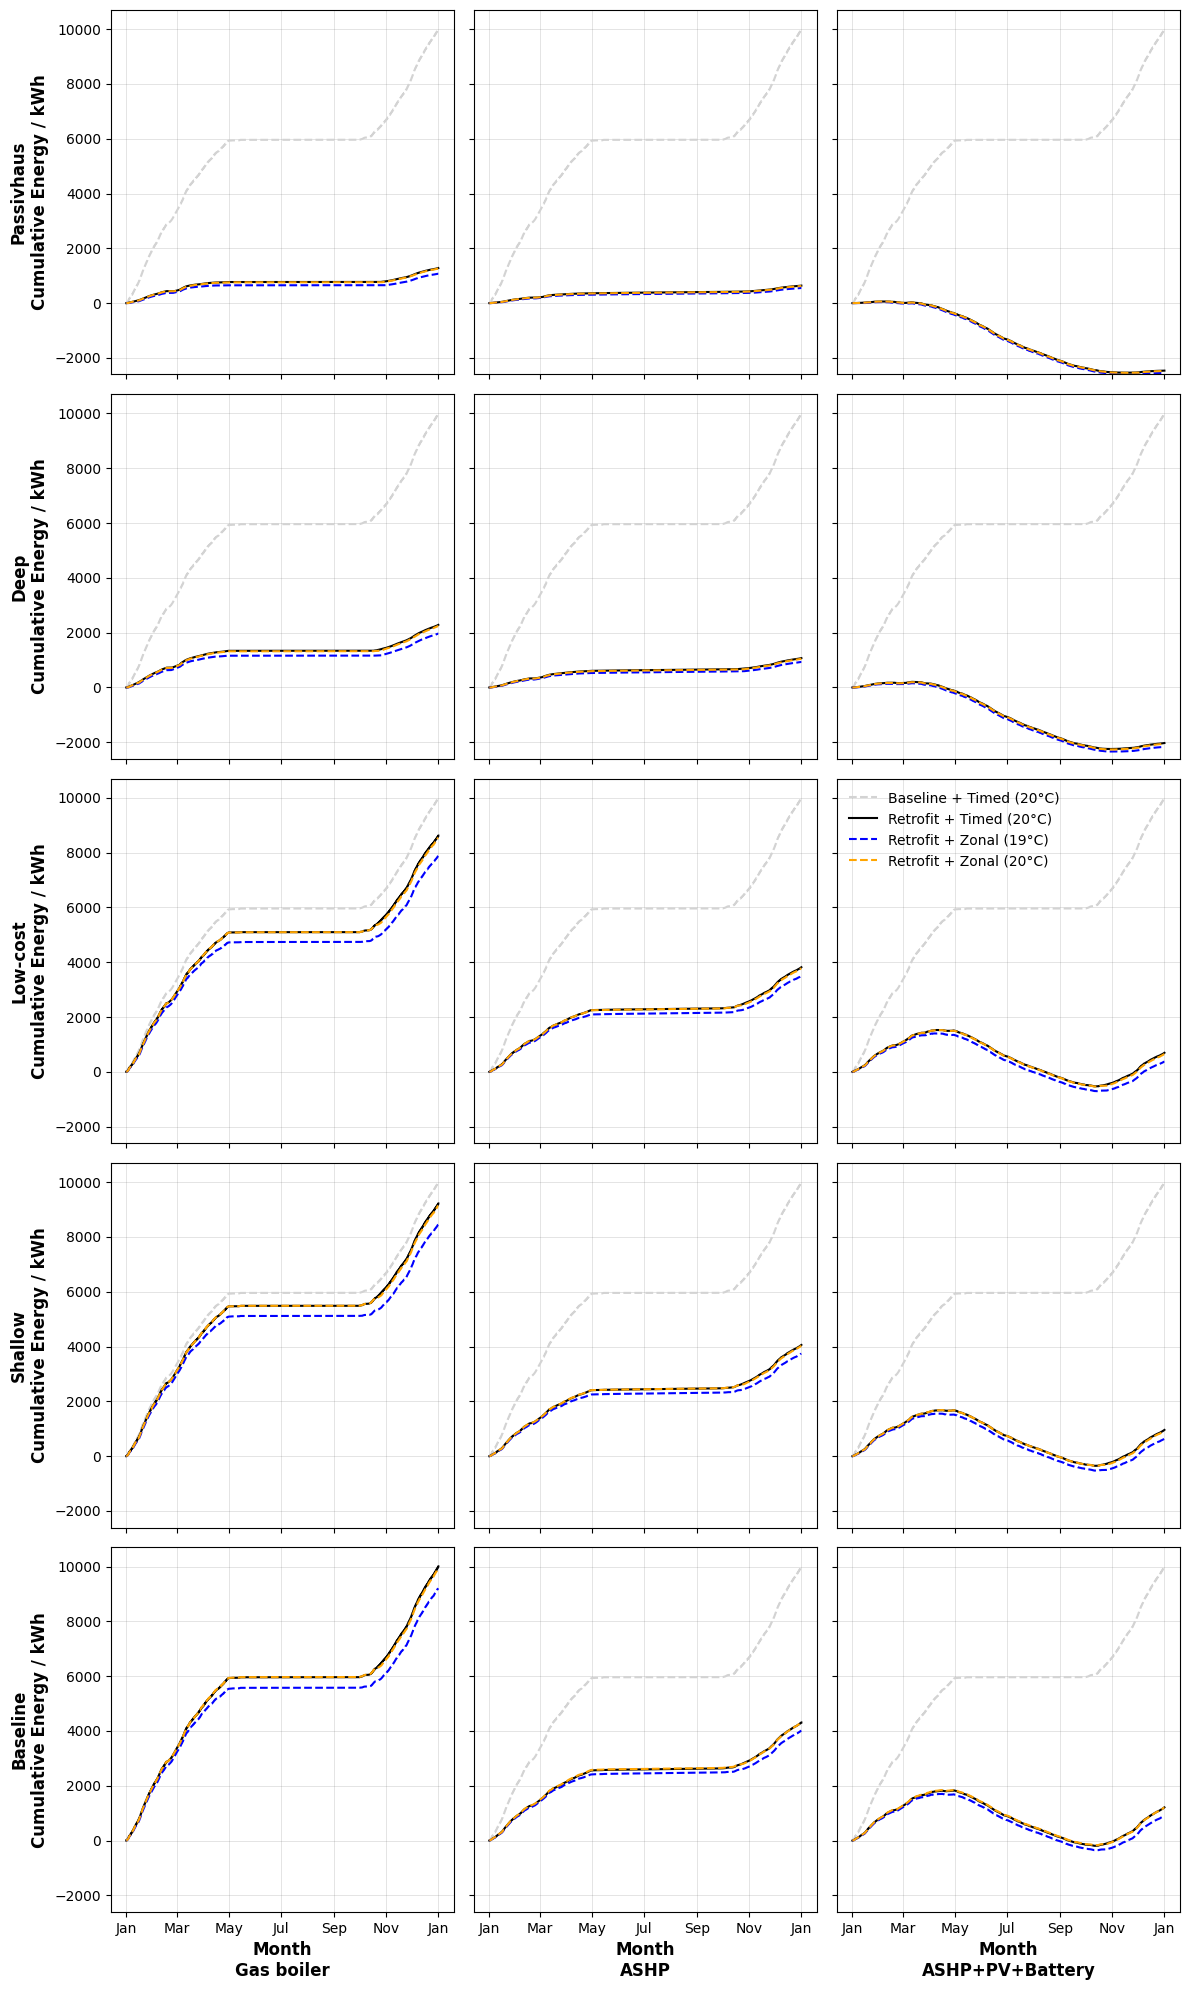

In [48]:
plot_metric_figure('energy')

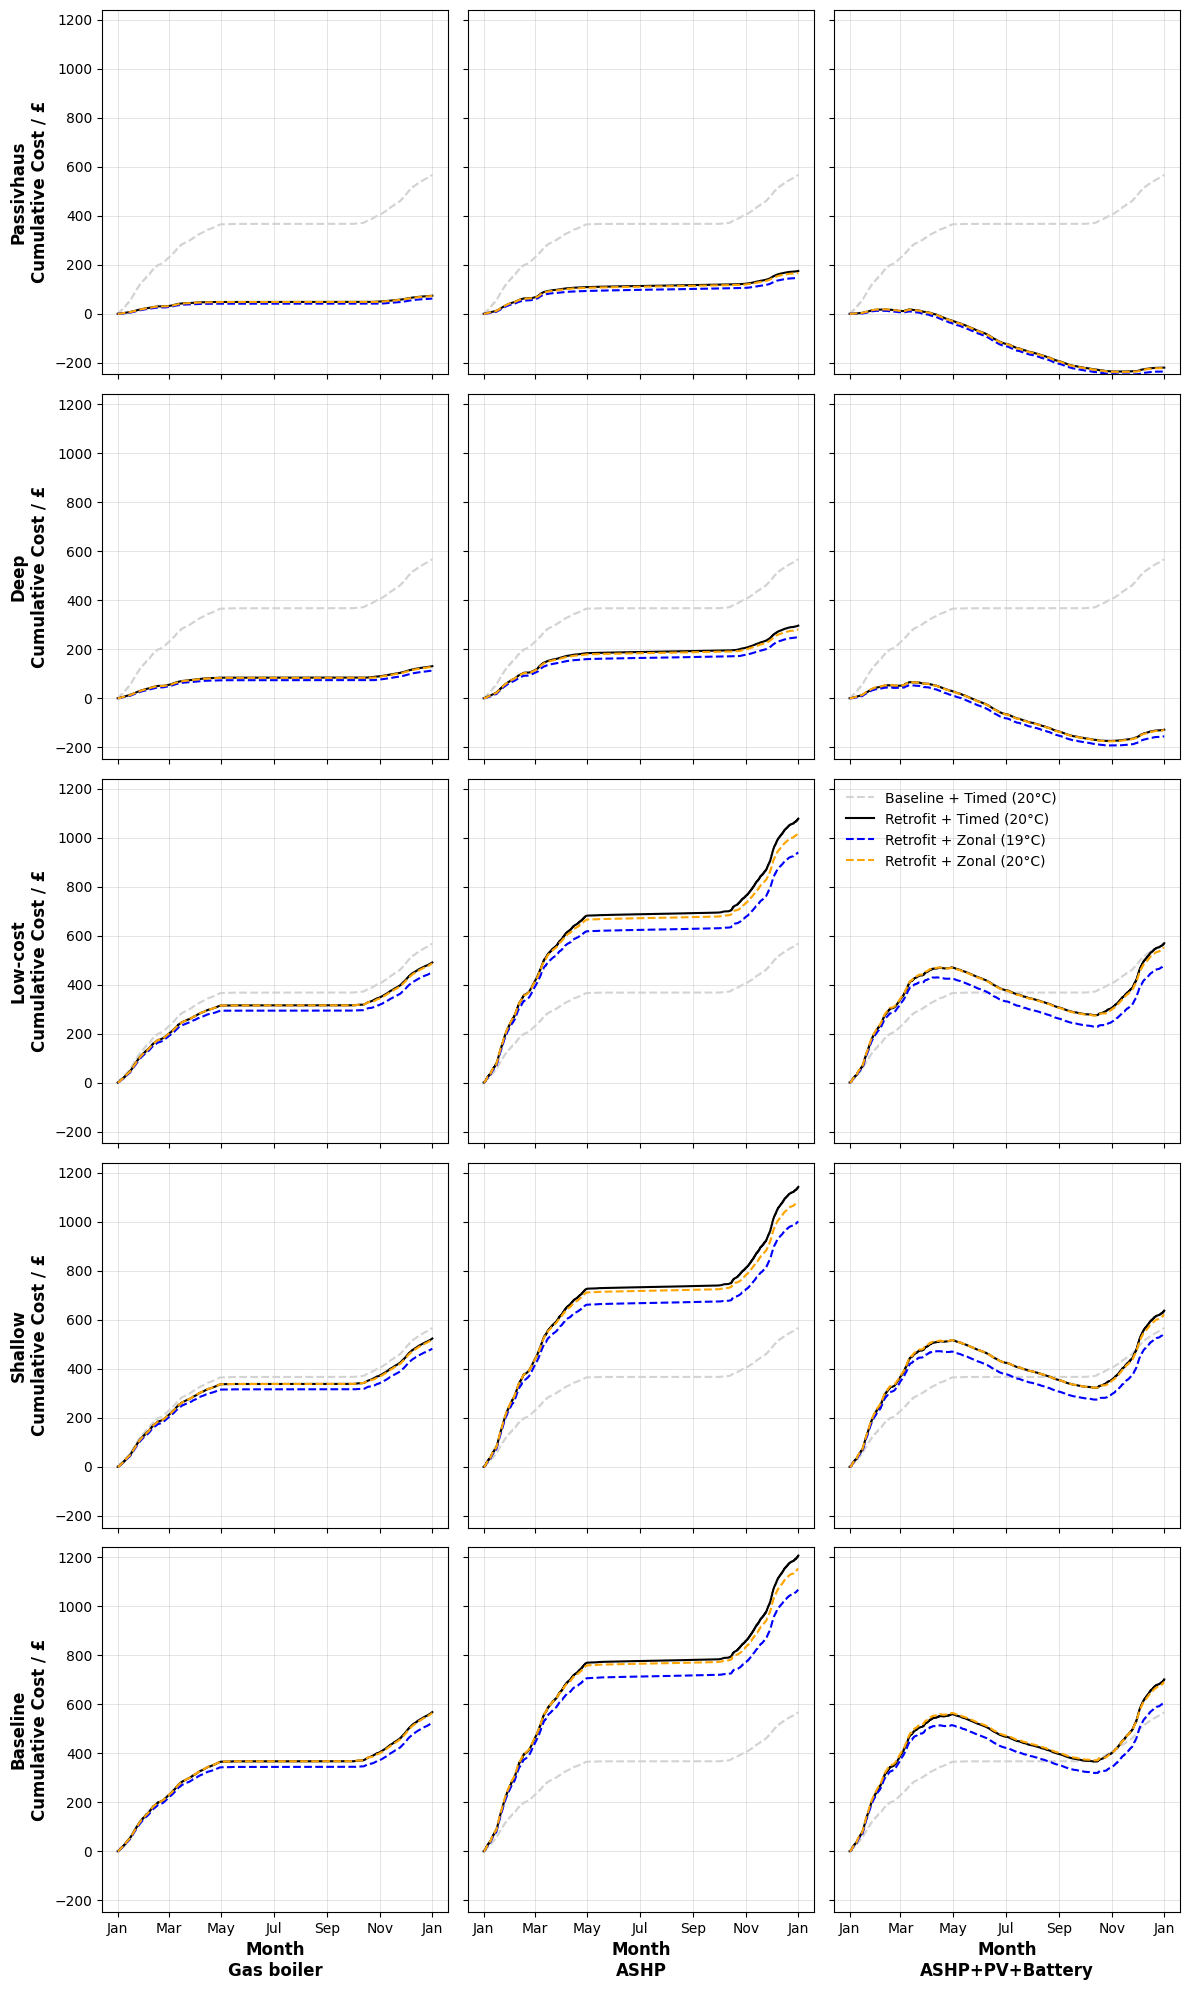

In [49]:
plot_metric_figure('cost')

### Other occupancy plots

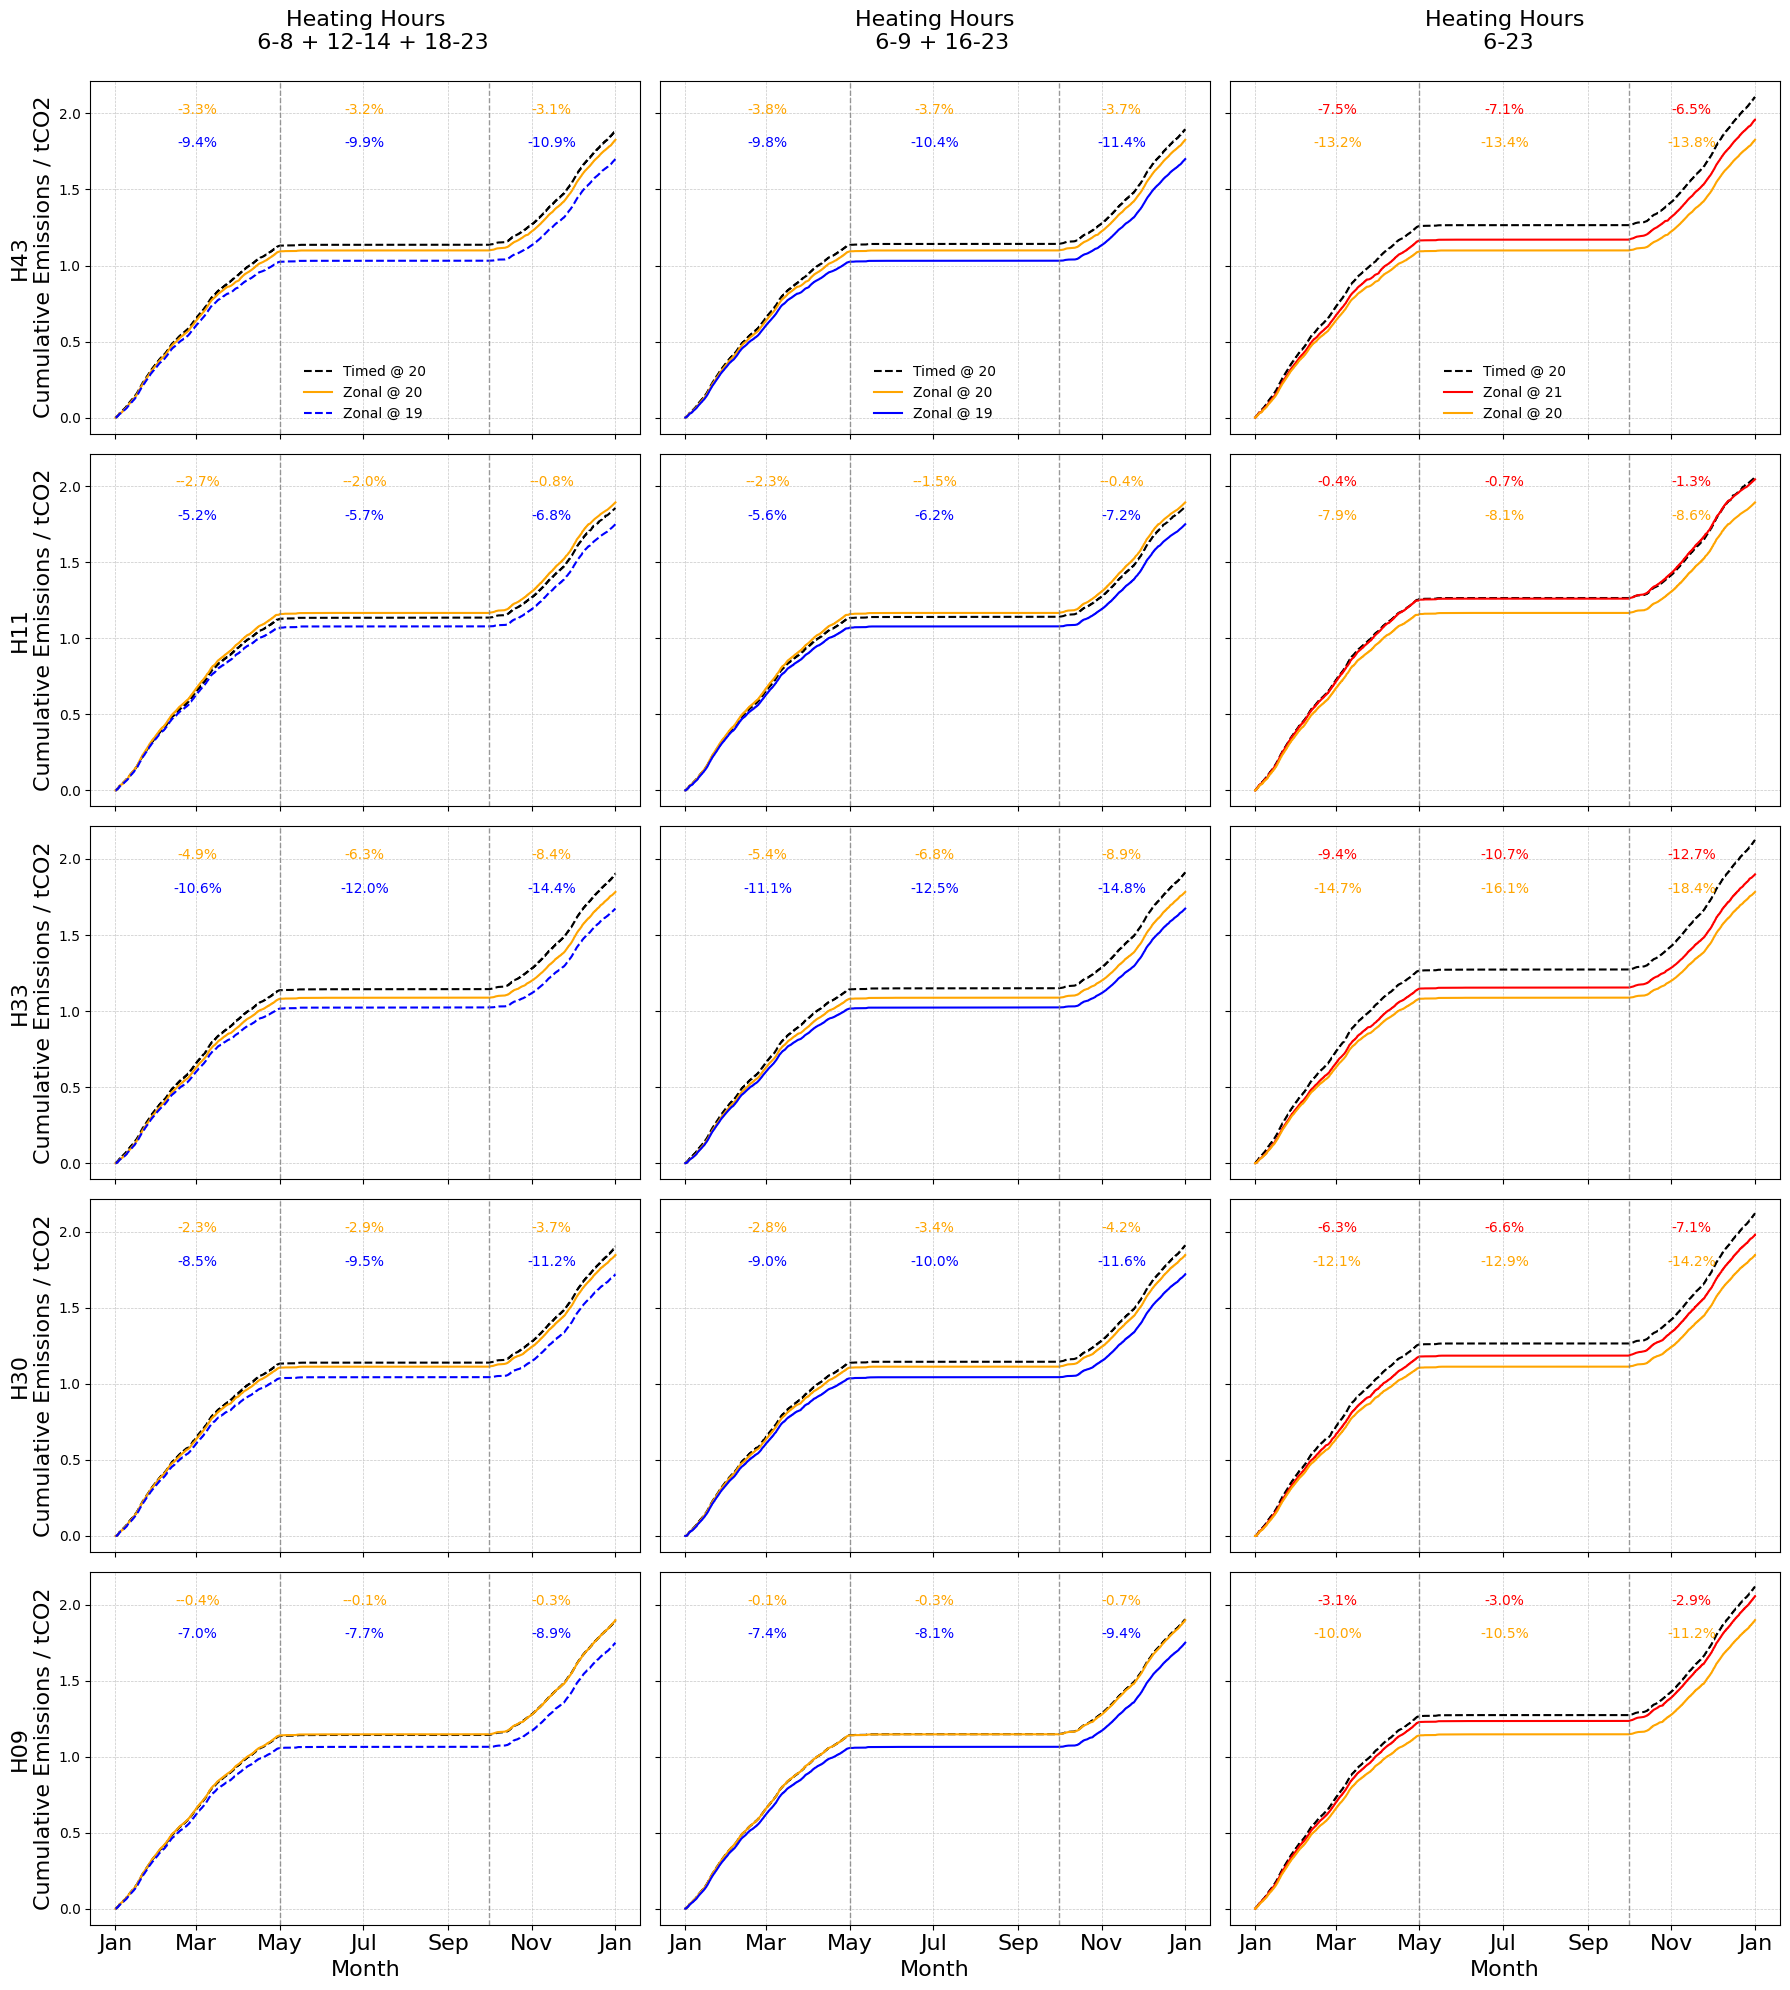

In [50]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import glob

# Directory path where the cases are stored
base_dir = '/workspaces/CUBES/results'

def load_json_file(file_type, case_number, zone_number, pattern, comforttemp, rep='H28'):
    """Load the JSON file based on the given parameters."""
    json_file_pattern = f'{base_dir}/case_{case_number}_year_2023_rep_{rep}_zone_{zone_number}_*_pattern_{pattern}_*_comfort_{comforttemp}.0_*/{file_type}.json'
    matching_files = glob.glob(json_file_pattern)
    if not matching_files:
        raise FileNotFoundError(f"No files found matching: {json_file_pattern}")
    with open(matching_files[0], 'r') as file:
        return json.load(file)

def create_dataframe(data, time_index):
    """Convert hourly JSON data to a pandas DataFrame with a DateTime index."""
    df = pd.DataFrame(data['hourly_data']).iloc[:8760]  # Ensure 8760 rows
    df.index = time_index
    return df

def calculate_period_emissions(df, start_date, end_date):
    """Calculate total emissions for a specified period."""
    period_df = df.loc[start_date:end_date]
    return period_df['emissions'].sum() / 1000  # Convert to metric tonnes

def compute_cumulative_metric(df, metric_name):
    """Calculate cumulative values for the specified metric."""
    df[f'cumulative_{metric_name}'] = df[metric_name].cumsum()
    return df

def plot_cumulative_metric(ax, df, metric_name, label, color, linestyle):
    """Plot cumulative metric on the given axis."""
    ax.plot(df.index, df[f'cumulative_{metric_name}'], color=color, linestyle=linestyle, label=label)

def annotate_reduction(ax, df1, df2, start_date, end_date, label1, label2, color, metric_name, global_ylim, used_y_positions):
    """Calculate and annotate reduction percentage for a given metric on the plot."""
    metric_1 =  df1.loc[start_date:end_date][metric_name].sum()
    metric_2 =  df2.loc[start_date:end_date][metric_name].sum()

    reduction = ((metric_1 - metric_2) / metric_1) * 100
    midpoint = pd.to_datetime(start_date) + (pd.to_datetime(end_date) - pd.to_datetime(start_date)) / 2

    period_key = f"{start_date}_{end_date}"
    if period_key not in used_y_positions:
        used_y_positions[period_key] = set()

    max_ylim = global_ylim[1]  # Use the global max y-limit for the row
    y_position = max_ylim * 0.85  # Start at 80% of the global max ylim
    while y_position in used_y_positions[period_key]:  # Avoid overlap by adjusting position
        y_position -= max_ylim * 0.05  # Adjust y-position relative to max ylim

    used_y_positions[period_key].add(y_position)

    ax.annotate(
        f"-{reduction:.1f}%",
        xy=(midpoint, y_position),
        xytext=(0, 20),
        textcoords="offset points",
        ha='center',
        fontsize=10,
        color=color,
    )

def normalise_metric(df, metric_name):
    """Normalise the given metric in the DataFrame and return the normalised DataFrame and unit."""
    if "cost" in metric_name:
        normalise = 100  # Convert pence to pounds
        name = 'Cost'
        unit = '£'
    elif "emission" in metric_name:
        normalise = 1000  # Convert grams to tonnes
        name = 'Emissions'
        unit = 'tCO2'
    else:
        normalise = 1  # No normalisation needed
        name = 'Energy'
        unit = 'kWh'

    df[metric_name] = df[metric_name] / normalise  # Normalise the specified metric column
    return df, unit, name

def main_subplot_emissions_with_reduction(zone_data_patterns, patterns, reps):
    time_index = pd.date_range(start="2023-01-01", periods=8760, freq="h")
    fig, axs = plt.subplots(len(reps), len(patterns), figsize=(18, 20), sharex=True, sharey=True)

    for row_idx, rep in enumerate(reps):
        global_ylim = [float('inf'), float('-inf')]

        # First pass: calculate global y-limits for the row
        for col_idx, (zone_data, pattern_name) in enumerate(zip(zone_data_patterns, patterns)):
            ax = axs[row_idx, col_idx]
            for zone_number, zone_pattern, comforttemp, label, color, linestyle in zone_data:
                data = load_json_file("hourly_metrics", 0, zone_number, zone_pattern, comforttemp, rep=rep)
                df = create_dataframe(data, time_index)

                # Normalise the emissions metric before computing cumulative values
                df, unit, name = normalise_metric(df, "emissions")
                df = compute_cumulative_metric(df, "emissions")

                plot_cumulative_metric(ax, df, "emissions", label, color, linestyle)

            # Update global y-limits
            current_ylim = ax.get_ylim()
            global_ylim[0] = min(global_ylim[0], current_ylim[0])
            global_ylim[1] = max(global_ylim[1], current_ylim[1])

        # Second pass: set global y-limits and add annotations
        for col_idx, (zone_data, pattern_name) in enumerate(zip(zone_data_patterns, patterns)):
            ax = axs[row_idx, col_idx]
            ax.set_ylim(global_ylim)

            dataframes = []
            used_y_positions = {}

            for zone_number, zone_pattern, comforttemp, label, color, linestyle in zone_data:
                data = load_json_file("hourly_metrics", 0, zone_number, zone_pattern, comforttemp, rep=rep)
                df = create_dataframe(data, time_index)

                # Normalise the emissions metric before computing cumulative values
                df, unit, name = normalise_metric(df, "emissions")
                df = compute_cumulative_metric(df, "emissions")

                dataframes.append((df, label, color, linestyle))

            timed_df = None
            for df, label, color, linestyle in dataframes:
                if "Timed" in label:
                    timed_df = df
                    break

            if timed_df is not None:
                for df, label, color, linestyle in dataframes:
                    if "Timed" not in label:
                        annotate_reduction(ax, timed_df, df, "2023-01-01", "2023-05-01", "Timed", label, color, "emissions", global_ylim, used_y_positions)
                        annotate_reduction(ax, timed_df, df, "2023-10-01", "2023-12-31", "Timed", label, color, "emissions", global_ylim, used_y_positions)
                        annotate_reduction(ax, timed_df, df, "2023-01-01", "2023-12-31", "Timed", label, color, "emissions", global_ylim, used_y_positions)

            # Add gridlines and other configurations
            ax.axvline(pd.Timestamp("2023-05-01"), color="gray", linestyle="--", linewidth=1, alpha=0.8)
            ax.axvline(pd.Timestamp("2023-10-01"), color="gray", linestyle="--", linewidth=1, alpha=0.8)
            ax.xaxis.set_major_locator(mdates.MonthLocator([1, 3, 5, 7, 9, 11]))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
            ax.tick_params(axis='x', labelsize=16)

            if pattern_name == 'once':
                pattern_title = "Heating Hours\n 6-23\n"
            elif pattern_name == 'twice':
                pattern_title = "Heating Hours\n  6-9 + 16-23\n"
            elif pattern_name == 'thrice':
                pattern_title = "Heating Hours\n  6-8 + 12-14 + 18-23\n"

            if row_idx == len(reps) - 1:
                ax.set_xlabel('Month', fontsize=16)
            if col_idx == 0:
                ax.set_ylabel(f'{rep}\nCumulative Emissions / {unit}', fontsize=16)
            if row_idx == 0:
                ax.set_title(pattern_title, fontsize=16)
                ax.legend(frameon=False, loc='lower center')

            ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    plt.tight_layout()
    plt.savefig(f"/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/SI/other_occupancies_cumulative_emissions_plot.pdf")
    plt.show()


def annotate_reduction(ax, df1, df2, start_date, end_date, label1, label2, color, metric_name, global_ylim, used_y_positions):
    metric_1 = df1.loc[start_date:end_date][metric_name].sum()
    metric_2 = df2.loc[start_date:end_date][metric_name].sum()

    reduction = ((metric_1 - metric_2) / metric_1) * 100
    midpoint = pd.to_datetime(start_date) + (pd.to_datetime(end_date) - pd.to_datetime(start_date)) / 2

    period_key = f"{start_date}_{end_date}"
    if period_key not in used_y_positions:
        used_y_positions[period_key] = set()

    max_ylim = global_ylim[1]  # Use the global max y-limit for the row
    y_position = max_ylim * 0.82  # Start at 85% of the global max ylim
    while y_position in used_y_positions[period_key]:  # Avoid overlap by adjusting position
        y_position -= max_ylim * 0.1  # Adjust y-position relative to max ylim

    used_y_positions[period_key].add(y_position)

    ax.annotate(
        f"-{reduction:.1f}%",
        xy=(midpoint, y_position),
        xytext=(0, 20),
        textcoords="offset points",
        ha='center',
        fontsize=10,
        color=color,
    )


# Define data for each pattern
zone_data_thrice = [
    (0, 'thrice', 20, 'Timed @ 20', 'black', '--'),
    (9, 'once', 20, 'Zonal @ 20', 'orange', '-'),
    (9, 'once', 19, 'Zonal @ 19', 'blue', '--')
]

zone_data_twice = [
    (0, 'twice', 20, 'Timed @ 20', 'black', '--'),
    (9, 'once', 20, 'Zonal @ 20', 'orange', '-'),
    (9, 'once', 19, 'Zonal @ 19', 'blue', '-')
]

zone_data_once = [
    (0, 'once', 20, 'Timed @ 20', 'black', '--'),
    (9, 'once', 21, 'Zonal @ 21', 'red', '-'),
    (9, 'once', 20, 'Zonal @ 20', 'orange', '-'),
]

# Combine data for all patterns
zone_data_patterns = [zone_data_thrice, zone_data_twice, zone_data_once]
patterns = ['thrice', 'twice', 'once']


# Define metrics and run the function
# metrics = ['emissions', 'gas_energy', 'cost']
# main_subplot_dynamic_multimetric(zone_data_patterns, patterns, metrics)
# Define reps and call the updated function
reps = ["H43", "H09", "H11", "H33", "H30"]
custom_order = {"H43": 0, "H11": 1, "H33": 2, "H30": 3, "H09": 4}
reps = sorted(reps, key=lambda x: custom_order[x])
main_subplot_emissions_with_reduction(zone_data_patterns, patterns, reps)

# main_subplot_dynamic(zone_data_patterns, patterns, metric_name)


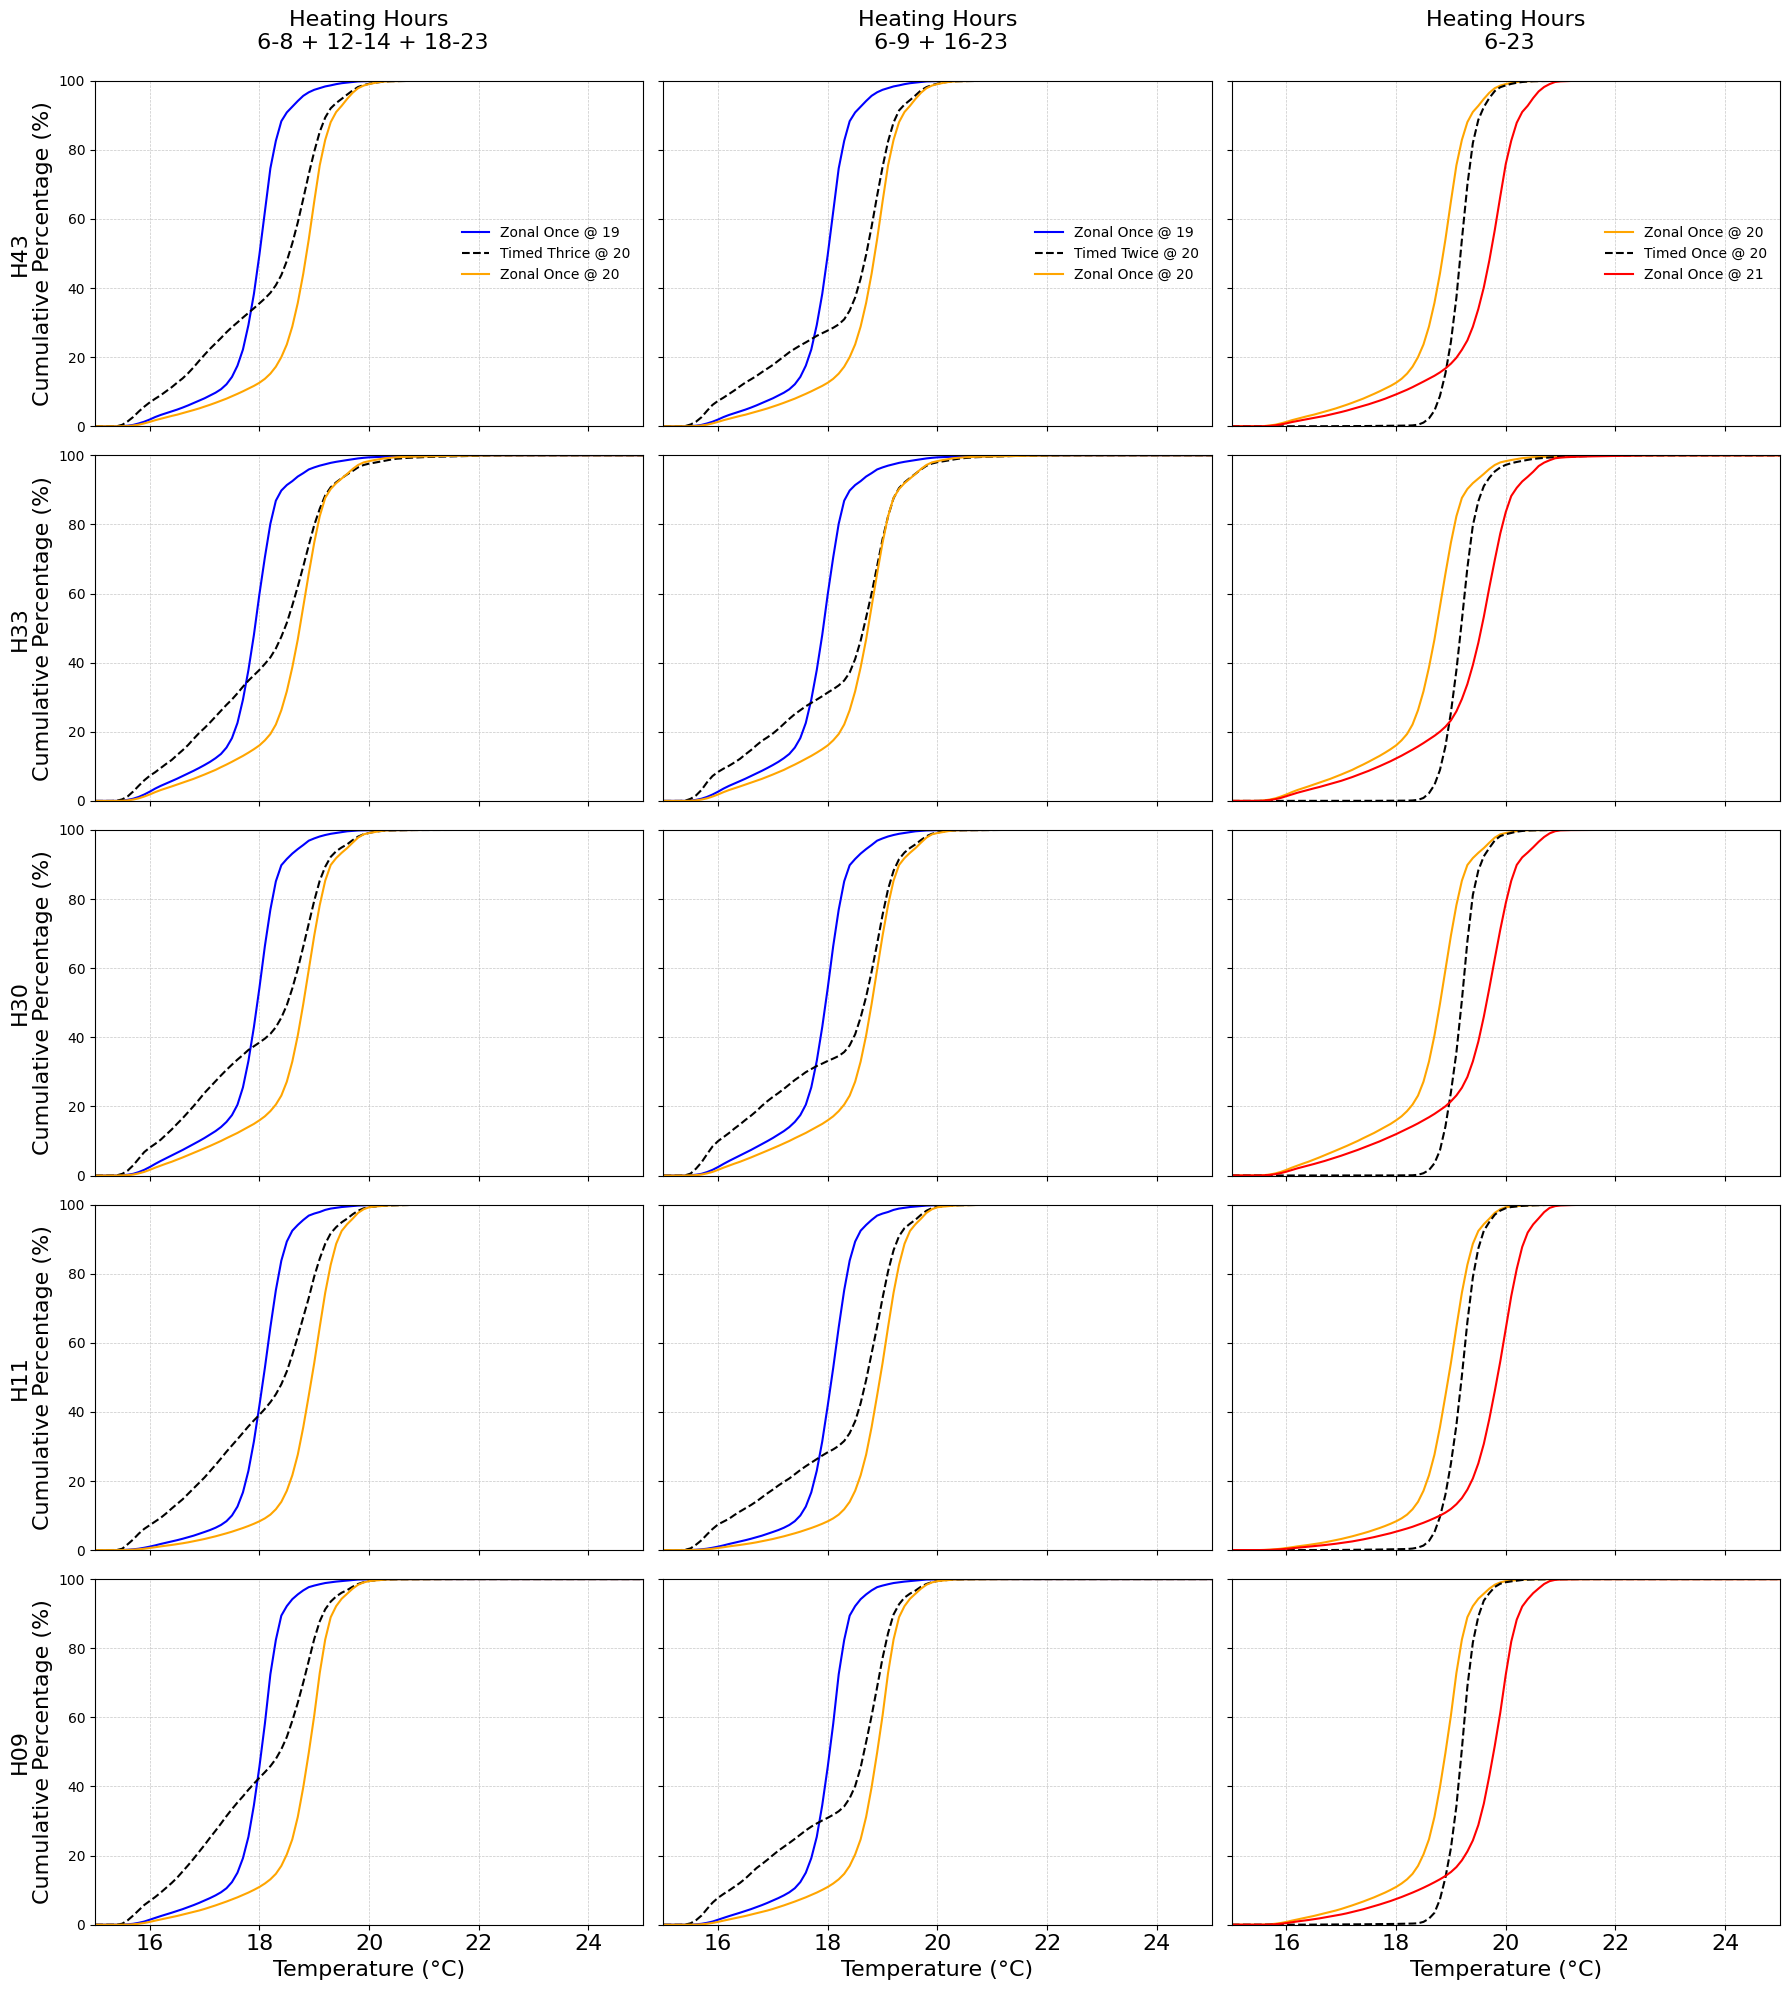

In [4]:
def get_temp_files(case, zone, threshold, pattern, temp, temp_type, rep='H28',base_dir ='/workspaces/CUBES/results', tag='thermostat_final_v5'):
    file_paths_in = [
        f"{base_dir}/case_{case}_year_2023_rep_{rep}_zone_{zone}_inactive_threshold_{threshold}_pattern_{pattern}_t_comfort_{temp}.0_t_setback_16.0_tags_{tag}/all_months_{temp_type}_all_months.csv",
    ]
    file_paths_ooh = [
        f"{base_dir}/case_{case}_year_2023_rep_{rep}_zone_{zone}_inactive_threshold_{threshold}_pattern_{pattern}_t_comfort_{temp}.0_t_setback_16.0_tags_{tag}/all_months_{temp_type}_ooh_all_months.csv",
    ]
    return file_paths_in, file_paths_ooh


def main_subplot_cumulative_temperature(zone_data_patterns, patterns, reps, room_areas, total_floor_area):
    time_index = pd.date_range(start="2023-01-01", periods=8760, freq="h")
    fig, axs = plt.subplots(len(reps), len(patterns), figsize=(18, 20), sharex=True, sharey=True)

    for row_idx, rep in enumerate(reps):
        global_ylim = [0, 100]  # Set y-axis limits for cumulative percentage

        for col_idx, (zone_data, pattern_name) in enumerate(zip(zone_data_patterns, patterns)):
            ax = axs[row_idx, col_idx]
            for zone_number, zone_pattern, comforttemp, label, color, linestyle in zone_data:
                file_args = {
                    'case': 0,
                    'zone': zone_number,
                    'threshold': 30,
                    'pattern': zone_pattern,
                    'temp': comforttemp,
                    'temp_type': 'opr',
                    'rep': rep,
                    'tag': 'other_occupancies',
                }
                file_paths_in, file_paths_ooh = get_temp_files(**file_args)
                weighted_df, _, _ = process_temperature_data(file_paths_in[0], file_paths_ooh[0], room_areas, total_floor_area)

                ax.plot(
                    weighted_df['Temperature'],
                    weighted_df['Cumulative Percentage'],
                    color=color,
                    linestyle=linestyle,
                    label=label
                )

            ax.set_xlim(15, 25)
            ax.set_ylim(global_ylim)
            ax.tick_params(axis='x', labelsize=16)

            ax.set_ylabel(f'{rep}\nCumulative Percentage (%)' if col_idx == 0 else "", fontsize=16)
            ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

            # Title based on heating pattern
            if pattern_name == 'once':
                pattern_title = "Heating Hours\n 6-23\n"
            elif pattern_name == 'twice':
                pattern_title = "Heating Hours\n 6-9 + 16-23\n"
            elif pattern_name == 'thrice':
                pattern_title = "Heating Hours\n 6-8 + 12-14 + 18-23\n"
            ax.set_title(pattern_title if row_idx == 0 else "", fontsize=16)

            if row_idx == 0:
                ax.legend(frameon=False, loc='center right')
            if row_idx == len(reps) -1:
                ax.set_xlabel('Temperature (°C)', fontsize=16)

    plt.tight_layout()
    plt.savefig(f"/workspaces/CUBES/exp/jack/paper/thermostat_experiment/figures/SI/other_occupancies_cumulative_temperature_plot.pdf")
    plt.show()


# Define data for each pattern
zone_data_thrice = [
    (9, 'once', 19, 'Zonal Once @ 19', 'blue', '-'),
    (0, 'thrice', 20, 'Timed Thrice @ 20', 'black', '--'),
    (9, 'once', 20, 'Zonal Once @ 20', 'orange', '-'),
]

zone_data_twice = [
    (9, 'once', 19, 'Zonal Once @ 19', 'blue', '-'),
    (0, 'twice', 20, 'Timed Twice @ 20', 'black', '--'),
    (9, 'once', 20, 'Zonal Once @ 20', 'orange', '-'),
]

zone_data_once = [
    (9, 'once', 20, 'Zonal Once @ 20', 'orange', '-'),
    (0, 'once', 20, 'Timed Once @ 20', 'black', '--'),
    (9, 'once', 21, 'Zonal Once @ 21', 'red', '-'),
]

zone_data_patterns = [zone_data_thrice, zone_data_twice, zone_data_once]
patterns = ['thrice', 'twice', 'once']
reps = ["H43", "H09", "H11", "H33", "H30"]
custom_order = {"H43": 0, "H33": 1, "H30": 2, "H11": 3, "H09": 4}
reps = sorted(reps, key=lambda x: custom_order[x])

main_subplot_cumulative_temperature(zone_data_patterns, patterns, reps, room_areas, total_floor_area)
